#### **Predicting Small Business Loan Default Risk Using U.S. SBA 7(a) FOIA Data**
#### **QM 640 - Data Analytics Capstone**

**Author:** Shivanand R. Koppalkar  
**Institution:** Walsh College  
**GL Mentor:** Mr. Abhay Poddar

**Instructors:**  Dr. Javad Katibai  
**Term:** Fall 2025 Term 3  
**Date:** April - June 2026  

---

#### **Abstract**
This capstone notebook builds and evaluates predictive models for U.S. Small Business Administration (SBA) 7(a) loan default using FOIA loan-level data spanning fiscal years 2010 through 2025. Five research questions—covering industry-term interactions, interest-rate effects, processing methods, cross-state lending, and disbursement timing—are each paired with a formal statistical hypothesis test and a tailored machine-learning model. Outcomes are reported across stratified Train, Validation, and Test partitions using metrics calibrated for class imbalance (charged-off loans = ~7.9% of resolved 7(a) loans).


---
### Revision Note - Final Report Updates

This notebook is the **revised version** of the QM 640 capstone code,
incorporating the changes itemised in the Interim Report's
"Interim Limitations and Risks" and "Next Steps for the Final Report"
sections. The new content does not replace the original interim
analyses; instead, three new sub-sections have been appended after
each affected research question so that the original results and the
robustness-checked results sit side-by-side for the reader:

| Section | Topic | Limitation Addressed |
|---------|-------|----------------------|
| **16.9** | Probability calibration via isotonic regression | RQ3 Random Forest negative R-squared and over-confident probabilities |
| **16.10** | Cost-sensitive threshold tuning | RQ3 Random Forest under-precision (~37%) at threshold 0.5 |
| **17.8** | Propensity-score matched analysis | RQ4 cross-state lending - selection bias on observable borrower controls |
| **18.9** | Stratified Cox by MacroRegime and ApprovalFiscalYear | RQ5 inverted hazard ratio - test whether COVID/PPP regime drives the sign-flip |
| **18.10** | Censoring assumptions review | RQ5 non-informative-censoring assumption check |

All other sections of the notebook are unchanged.

---


## Table of Contents

1. [Setup and Import Libraries](#1.-Setup-and-Import-Libraries)
2. [Download the SBA 7(a) FOIA CSV Files](#2.-Download-the-SBA-7(a)-FOIA-CSV-Files)
3. [Consolidate and Combine the Two Datasets](#3.-Consolidate-and-Combine-the-Two-Datasets)
4. [Display Dataset Shape](#4.-Display-Dataset-Shape)
5. [Initial 5 / Last 5 / Sample 5 Rows](#5.-Initial-5-/-Last-5-/-Sample-5-Rows)
6. [Statistical Summary and Transpose](#6.-Statistical-Summary-and-Transpose)
7. [Missing Values, Duplicates, and Outliers](#7.-Missing-Values,-Duplicates,-and-Outliers)
8. [Distribution of the Datasets](#8.-Distribution-of-the-Datasets)
9. [Filter to FiscalYear >= 2018 (Working Copy)](#9.-Filter-to-FiscalYear->=-2018-(Working-Copy))
10. [Outlier Treatment and Imputation](#10.-Outlier-Treatment-and-Imputation)
11. [Univariate and Bivariate Exploratory Data Analysis](#11.-Univariate-and-Bivariate-Exploratory-Data-Analysis)
    - [11.1 Univariate EDA - Numeric Distributions](#11.1-Univariate-EDA-Numeric-Distributions)
    - [11.2 Univariate EDA - Categorical Distributions](#11.2-Univariate-EDA-Categorical-Distributions)
    - [11.3 Bivariate EDA - Numeric vs Default](#11.3-Bivariate-EDA-Numeric-vs-Default)
    - [11.4 Bivariate EDA - Categorical vs Default](#11.4-Bivariate-EDA-Categorical-vs-Default)
    - [11.5 Bivariate EDA - Numeric x Numeric Correlation Heatmap](#11.5-Bivariate-EDA-Numeric-x-Numeric-Correlation-Heatmap)
    - [11.6 Bivariate EDA - Pairwise Scatter Matrix](#11.6-Bivariate-EDA-Pairwise-Scatter-Matrix)
12. [Stratified Train / Validation / Test Split](#12.-Stratified-Train-/-Validation-/-Test-Split)
13. [Shared Evaluation Helpers](#13.-Shared-Evaluation-Helpers)
14. **Research Question 1 - NAICS Sector x Loan Term Interaction**
    - [14.1 Statistical Method - Chi-Square Test](#14.1-Statistical-Method-Chi-Square-Test)
    - [14.2 Hypothesis Decision (Statistical)](#14.2-Hypothesis-Decision-(Statistical))
    - [14.3 Visualization - Sector x Term Heatmap](#14.3-Visualization-Sector-x-Term-Heatmap)
    - [14.4 Machine Learning Model - XGBoost](#14.4-Machine-Learning-Model-XGBoost)
    - [14.5 Performance Metrics + Confusion Matrices](#14.5-Performance-Metrics-+-Confusion-Matrices)
    - [14.6 ROC-AUC Curves](#14.6-ROC-AUC-Curves)
    - [14.7 Regression-Style Calibration Metrics (RMSE / MAE / R-squared)](#14.7-Regression-Style-Calibration-Metrics)
    - [14.8 Hypothesis Outcome and Interpretation](#14.8-Hypothesis-Outcome-and-Interpretation)
15. **Research Question 2 - Interest Rate and Rate Type**
    - [15.1 Statistical Method - Logistic Regression + LRT](#15.1-Statistical-Method-Logistic-Regression-+-LRT)
    - [15.2 ANOVA Across Interest-Rate Quartiles + Tukey HSD](#15.2-ANOVA-Across-Interest-Rate-Quartiles-+-Tukey-HSD)
    - [15.3 Visualization - Quartile x Rate Type](#15.3-Visualization-Quartile-x-Rate-Type)
    - [15.4 Machine Learning Model - LightGBM](#15.4-Machine-Learning-Model-LightGBM)
    - [15.5 Performance Metrics + Confusion Matrices](#15.5-Performance-Metrics-+-Confusion-Matrices)
    - [15.6 ROC-AUC Curves](#15.6-ROC-AUC-Curves)
    - [15.7 Regression-Style Calibration Metrics (RMSE / MAE / R-squared)](#15.7-Regression-Style-Calibration-Metrics)
    - [15.8 Hypothesis Outcome and Interpretation](#15.8-Hypothesis-Outcome-and-Interpretation)
16. **Research Question 3 - SBA Processing Method**
    - [16.1 Statistical Method - One-Way ANOVA + Levene + Tukey HSD](#16.1-Statistical-Method-One-Way-ANOVA-+-Levene-+-Tukey-HSD)
    - [16.2 Visualization - Default Rate by Processing Method](#16.2-Visualization-Default-Rate-by-Processing-Method)
    - [16.3 Machine Learning Model - Random Forest](#16.3-Machine-Learning-Model-Random-Forest)
    - [16.4 Performance Metrics + Confusion Matrices](#16.4-Performance-Metrics-+-Confusion-Matrices)
    - [16.5 Permutation Importance](#16.5-Permutation-Importance)
    - [16.6 ROC-AUC Curves](#16.6-ROC-AUC-Curves)
    - [16.7 Regression-Style Calibration Metrics (RMSE / MAE / R-squared)](#16.7-Regression-Style-Calibration-Metrics)
    - [16.8 Hypothesis Outcome and Interpretation](#16.8-Hypothesis-Outcome-and-Interpretation)
17. **Research Question 4 - Cross-State Lending**
    - [17.1 Statistical Method - Two-Proportion z-Test](#17.1-Statistical-Method-Two-Proportion-z-Test)
    - [17.2 Visualization - Cross-State vs Same-State](#17.2-Visualization-Cross-State-vs-Same-State)
    - [17.3 Machine Learning Model - Multilayer Perceptron](#17.3-Machine-Learning-Model-Multilayer-Perceptron)
    - [17.4 Performance Metrics + Confusion Matrices](#17.4-Performance-Metrics-+-Confusion-Matrices)
    - [17.5 ROC-AUC Curves](#17.5-ROC-AUC-Curves)
    - [17.6 Regression-Style Calibration Metrics (RMSE / MAE / R-squared)](#17.6-Regression-Style-Calibration-Metrics)
    - [17.7 Hypothesis Outcome and Interpretation](#17.7-Hypothesis-Outcome-and-Interpretation)
18. **Research Question 5 - Disbursement Lag**
    - [18.1 Statistical Method - Cox Proportional-Hazards](#18.1-Statistical-Method-Cox-Proportional-Hazards)
    - [18.2 Kaplan-Meier Curves by Lag Quartile](#18.2-Kaplan-Meier-Curves-by-Lag-Quartile)
    - [18.3 Machine Learning Model - XGBoost Classifier](#18.3-Machine-Learning-Model-XGBoost-Classifier)
    - [18.4 Performance Metrics + Confusion Matrices](#18.4-Performance-Metrics-+-Confusion-Matrices)
    - [18.5 Concordance Index (Survival Discrimination)](#18.5-Concordance-Index-(Survival-Discrimination))
    - [18.6 ROC-AUC Curves](#18.6-ROC-AUC-Curves)
    - [18.7 Regression-Style Calibration Metrics (RMSE / MAE / R-squared)](#18.7-Regression-Style-Calibration-Metrics)
    - [18.8 Hypothesis Outcome and Interpretation](#18.8-Hypothesis-Outcome-and-Interpretation)
19. [Cross-RQ Evaluation Summary](#19.-Cross-RQ-Evaluation-Summary)
20. [**Dashboard - Research Questions, Hypothesis Outcomes, Methods**](#20.-Dashboard-Research-Questions,-Hypothesis-Outcomes,-Methods)
    - [20.1 Expanded Dashboard - Confusion Matrix Tile](#20.1-Expanded-Dashboard-Confusion-Matrix-Tile)
    - [20.2 Expanded Dashboard - Combined Test-Set ROC-AUC Curves](#20.2-Expanded-Dashboard-Combined-Test-Set-ROC-AUC-Curves)
    - [20.3 Expanded Dashboard - Threshold-Fixed Metric Spider Chart](#20.3-Expanded-Dashboard-Threshold-Fixed-Metric-Spider-Chart)
    - [20.4 Expanded Dashboard - Hypothesis Outcomes Summary Card](#20.4-Expanded-Dashboard-Hypothesis-Outcomes-Summary-Card)
    - [20.5 Expanded Dashboard - RQ Difficulty vs Lift Map](#20.5-Expanded-Dashboard-RQ-Difficulty-vs-Lift-Map)
21. [Summary, Reflections, Actionable Insights, Recommendations & Conclusion](#21.-Summary,-Reflections,-Actionable-Insights,-Recommendations-&-Conclusion)

---

### Five Research Questions and Their Hypotheses

**RQ1 - Industry-Term Interaction**  
*How does the interaction between NAICS industry sector and loan term length influence default probability in SBA 7(a) loans?*
- **H0:** There is no significant interaction between NAICS sector and loan term on default probability.
- **H1:** Certain sector-term combinations exhibit disproportionately higher or lower default rates.

**RQ2 - Interest Rate and Rate Type Effects**  
*Does the initial interest rate and rate type (fixed vs. variable) significantly affect the likelihood of loan default after controlling for loan size and term?*
- **H0:** Initial interest rate and rate type have no significant effect on default probability after controlling for loan size and term.
- **H1:** Higher interest rates and variable-rate loans are associated with significantly higher default probability.

**RQ3 - SBA Processing Method Effects**  
*Does the SBA processing method significantly affect the likelihood of loan default after controlling for loan size and borrower characteristics?*
- **H0:** No significant difference in default rates across SBA processing methods after controlling for loan size and borrower characteristics.
- **H1:** At least one processing method has a significantly different default rate.

**RQ4 - Cross-State Lending and Information Asymmetry**  
*Does cross-state lending (lender state =/= borrower state) increase default risk due to information asymmetry?*
- **H0:** Default rate for cross-state loans equals default rate for same-state loans.
- **H1:** Cross-state loans have a significantly higher default rate.

**RQ5 - Disbursement Lag as Early Warning**  
*Can the time gap between loan approval and first disbursement serve as an early warning signal for default risk?*
- **H0:** Disbursement lag has no significant association with default risk (hazard ratio = 1.0).
- **H1:** Longer disbursement lag significantly increases default risk (hazard ratio > 1.0).


## 1. Setup and Import Libraries

**Purpose:** Import all libraries needed across the entire capstone — data handling, statistical testing, machine learning, survival analysis, and visualization. Set global display options and reproducibility seeds so every run yields identical results.

**Observations:** The library stack is intentionally comprehensive because each research question uses a different statistical method and a different machine-learning model. Survival analysis (RQ5) uses `lifelines`; gradient boosting (RQ1, RQ2) uses `xgboost` and `lightgbm`; the neural network (RQ4) uses sklearn's `MLPClassifier` (TensorFlow-free, so the notebook is portable across machines without GPU drivers).

**Reasoning:** The first cell auto-installs `xgboost`, `lightgbm`, and `lifelines` if they are missing, so RQ5's Cox proportional-hazards model is always available without manual intervention. The seed `RANDOM_STATE = 42` flows into every train/test split, every ML model initialization, and every bootstrap sample so reviewers can reproduce identical results.

**Insights:** A self-bootstrapping environment is what separates a notebook a grader has to debug from one they can simply Run-All. The pinned `RANDOM_STATE = 42` is the single thread that makes every downstream result — split assignment, model coefficients, ROC curves, Dashboard summary — bit-for-bit reproducible across machines.


In [1]:
# ---------------------------------------------------------------
# Auto-install optional ML / survival libraries if missing
# ---------------------------------------------------------------
import importlib, subprocess, sys

REQUIRED_PACKAGES = {
    "xgboost":   "xgboost",
    "lightgbm":  "lightgbm",
    "lifelines": "lifelines",
}

def ensure(pkg_import, pkg_pip):
    try:
        importlib.import_module(pkg_import)
        print(f"[ALREADY INSTALLED] {pkg_pip}")
    except ImportError:
        print(f"[INSTALLING] {pkg_pip} ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "--quiet", pkg_pip]
        )
        print(f"[OK] {pkg_pip} installed")

for imp, pip_name in REQUIRED_PACKAGES.items():
    ensure(imp, pip_name)


[ALREADY INSTALLED] xgboost
[ALREADY INSTALLED] lightgbm
[INSTALLING] lifelines ...
[OK] lifelines installed


In [2]:
# ---------------------------------------------------------------
# Core
# ---------------------------------------------------------------
import os, sys, io, zipfile, warnings, requests
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# ---------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

# ---------------------------------------------------------------
# Statistical tests
# ---------------------------------------------------------------
import scipy.stats as stats
from scipy.stats import chi2_contingency, f_oneway, levene, kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.proportion import proportions_ztest

# ---------------------------------------------------------------
# Machine Learning - sklearn
# ---------------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report,
    roc_curve, auc,
    mean_squared_error, mean_absolute_error, r2_score
)

# ---------------------------------------------------------------
# Gradient boosting (auto-installed above)
# ---------------------------------------------------------------
import xgboost as xgb
import lightgbm as lgb
HAS_XGB = True
HAS_LGB = True

# ---------------------------------------------------------------
# Survival analysis - now guaranteed available (auto-installed)
# ---------------------------------------------------------------
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
HAS_LL = True

# ---------------------------------------------------------------
# Display & reproducibility
# ---------------------------------------------------------------
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Library imports complete.")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
print(f"  Matplotlib  : {plt.matplotlib.__version__}")
print(f"  Seaborn     : {sns.__version__}")
print(f"  XGBoost     : {xgb.__version__}")
print(f"  LightGBM    : {lgb.__version__}")
print(f"  lifelines   : OK")
print(f"  Random seed : {RANDOM_STATE}")


Library imports complete.
  Python      : 3.12.13
  NumPy       : 2.0.2
  Pandas      : 2.2.2
  Matplotlib  : 3.10.0
  Seaborn     : 0.13.2
  XGBoost     : 3.2.0
  LightGBM    : 4.6.0
  lifelines   : OK
  Random seed : 42


## 2. Download the SBA 7(a) FOIA CSV Files

**Purpose:** Retrieve the two SBA 7(a) FOIA data files referenced in the capstone synopsis. They are stored as ZIP archives in the project's GitHub repository (`shivanandrk/WalshCollege/Data`) because each raw CSV exceeds GitHub's 100 MB single-file limit.

**Observations:** The two files cover non-overlapping fiscal-year ranges and share an identical 43-column 7(a) schema:
- `foia-7a-fy2010-fy2019-as-of-251231.zip` -> FY2010-FY2019 (~545,751 rows)
- `foia-7a-fy2020-present-as-of-251231.zip` -> FY2020-present (~357,866 rows)

Each ZIP contains a single CSV with the same name minus the extension. The combined raw row count is ~903,617 before any filtering.

**Reasoning:** Pinning to a specific commit hash (`1ff3066…`) guarantees the exact file snapshot used in the synopsis remains reproducible even if the repository is updated later. The function caches the downloaded files locally so repeated notebook runs do not re-download.

**Insights:** Tying the download to a specific commit hash, not a branch, is what makes the analysis defensible months from now: the SBA may republish the FOIA files with corrections, but our exact bytes remain accessible. Local caching also keeps re-runs cheap during iterative analysis.


In [3]:
GITHUB_USER   = "shivanandrk"
GITHUB_REPO   = "WalshCollege"
GITHUB_COMMIT = "1ff3066e64d5ba62d369f2a50f0bf0117b6520fe"
GITHUB_FOLDER = "Data"

ZIP_FILES = {
    "fy2010_2019":   "foia-7a-fy2010-fy2019-as-of-251231.zip",
    "fy2020_present":"foia-7a-fy2020-present-as-of-251231.zip",
}

DATA_DIR = Path("./sba_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)


def build_raw_url(filename: str) -> str:
    return (f"https://raw.githubusercontent.com/"
            f"{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_COMMIT}/"
            f"{GITHUB_FOLDER}/{filename}")


def download_and_extract(label: str, zip_name: str) -> Path:
    """Download a ZIP (if not cached) and extract the inner CSV."""
    zip_path = DATA_DIR / zip_name
    csv_name = zip_name.replace(".zip", ".csv")
    csv_path = DATA_DIR / csv_name

    if csv_path.exists():
        print(f"[CACHED] {csv_name} ({csv_path.stat().st_size/1e6:.1f} MB)")
        return csv_path

    if not zip_path.exists():
        url = build_raw_url(zip_name)
        print(f"[DOWNLOAD] {label}: {zip_name} ...")
        r = requests.get(url, stream=True, timeout=600)
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        print(f"           saved {zip_path.stat().st_size/1e6:.1f} MB")

    print(f"[EXTRACT] {zip_name} -> {csv_name}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)

    if not csv_path.exists():
        cands = list(DATA_DIR.glob("*.csv"))
        if cands: csv_path = cands[0]
        else: raise FileNotFoundError(f"No CSV found inside {zip_name}")

    print(f"           ready at {csv_path}")
    return csv_path


csv_paths = {label: download_and_extract(label, fn)
             for label, fn in ZIP_FILES.items()}

print("\nAll files ready:")
for k, v in csv_paths.items():
    print(f"  {k:18s} -> {v}")


[DOWNLOAD] fy2010_2019: foia-7a-fy2010-fy2019-as-of-251231.zip ...
           saved 51.2 MB
[EXTRACT] foia-7a-fy2010-fy2019-as-of-251231.zip -> foia-7a-fy2010-fy2019-as-of-251231.csv
           ready at sba_data/foia-7a-fy2010-fy2019-as-of-251231.csv
[DOWNLOAD] fy2020_present: foia-7a-fy2020-present-as-of-251231.zip ...
           saved 32.8 MB
[EXTRACT] foia-7a-fy2020-present-as-of-251231.zip -> foia-7a-fy2020-present-as-of-251231.csv
           ready at sba_data/foia-7a-fy2020-present-as-of-251231.csv

All files ready:
  fy2010_2019        -> sba_data/foia-7a-fy2010-fy2019-as-of-251231.csv
  fy2020_present     -> sba_data/foia-7a-fy2020-present-as-of-251231.csv


## 3. Consolidate and Combine the Two Datasets

**Purpose:** Read both CSVs into pandas DataFrames, harmonize column casing, and concatenate them into a single analytic dataset. Tag each row with its source vintage so vintage-specific comparisons remain possible.

**Observations:** The actual SBA FOIA CSVs use **lowercase column names** (e.g., `loanstatus`, `naicscode`, `terminmonths`, `processingmethod`) — not the CamelCase names cited in the synopsis. To keep this notebook readable and aligned with the synopsis vocabulary, a small mapping renames the most-used columns to CamelCase right after loading. All 43 columns are preserved either way.

**Reasoning:** Reading with `low_memory=False` lets pandas infer dtypes across the full file rather than chunk-by-chunk, which prevents NAICS codes (numeric in early rows, string in some later rows) from being mis-typed. The `DataVintage` tag enables fiscal-year-aware filtering downstream.

**Insights:** The casing mismatch between the synopsis (CamelCase) and the actual FOIA download (lowercase) is exactly the kind of subtle data-engineering issue that turns a 30-minute analysis into a 3-hour debugging session. Mapping at load time costs one cell now and saves dozens of `KeyError` debugging cycles later.


In [4]:
COLUMN_MAP = {
    "asofdate":                  "AsOfDate",
    "program":                   "Program",
    "borrname":                  "BorrName",
    "borrstate":                 "BorrState",
    "borrcity":                  "BorrCity",
    "bankname":                  "BankName",
    "bankstate":                 "BankState",
    "bankcity":                  "BankCity",
    "grossapproval":             "GrossApproval",
    "sbaguaranteedapproval":     "SBAGuaranteedApproval",
    "approvaldate":              "ApprovalDate",
    "approvalfiscalyear":        "ApprovalFiscalYear",
    "firstdisbursementdate":     "FirstDisbursementDate",
    "processingmethod":          "ProcessingMethod",
    "subprogram":                "SubProgram",
    "initialinterestrate":       "InitialInterestRate",
    "fixedorvariableinterestind":"FixedOrVariableInterestInd",
    "terminmonths":              "TermInMonths",
    "naicscode":                 "NaicsCode",
    "naicsdescription":          "NaicsDescription",
    "franchisecode":             "FranchiseCode",
    "franchisename":             "FranchiseName",
    "projectstate":              "ProjectState",
    "businesstype":              "BusinessType",
    "businessage":               "BusinessAge",
    "loanstatus":                "LoanStatus",
    "paidinfulldate":            "PaidInFullDate",
    "chargeoffdate":             "ChargeOffDate",
    "grosschargeoffamount":      "GrossChargeOffAmount",
    "revolverstatus":            "RevolverStatus",
    "jobssupported":             "JobsSupported",
    "collateralind":             "CollateralInd",
    "soldsecmrktind":            "SoldSecMrktInd",
}


def load_and_normalize(label: str, path: Path) -> pd.DataFrame:
    print(f"[LOAD] {label}: {path.name}")
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip().lower() for c in df.columns]
    df = df.rename(columns=COLUMN_MAP)
    df["DataVintage"] = label
    print(f"       shape = {df.shape}")
    return df


df_2010_2019 = load_and_normalize("fy2010_2019",  csv_paths["fy2010_2019"])
df_2020_pres = load_and_normalize("fy2020_present", csv_paths["fy2020_present"])

all_cols = sorted(set(df_2010_2019.columns) | set(df_2020_pres.columns))
df_2010_2019 = df_2010_2019.reindex(columns=all_cols)
df_2020_pres = df_2020_pres.reindex(columns=all_cols)
df_raw = pd.concat([df_2010_2019, df_2020_pres], axis=0, ignore_index=True)

print(f"\nCombined raw dataset: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"  FY2010-FY2019 rows : {(df_raw['DataVintage']=='fy2010_2019').sum():,}")
print(f"  FY2020-present rows: {(df_raw['DataVintage']=='fy2020_present').sum():,}")


[LOAD] fy2010_2019: foia-7a-fy2010-fy2019-as-of-251231.csv
       shape = (545751, 44)
[LOAD] fy2020_present: foia-7a-fy2020-present-as-of-251231.csv
       shape = (357866, 44)

Combined raw dataset: 903,617 rows x 44 columns
  FY2010-FY2019 rows : 545,751
  FY2020-present rows: 357,866


## 4. Display Dataset Shape

**Purpose:** Report the shape of each input file and the combined dataset in a clean tabular DataFrame so reviewers can verify the row counts cited in the synopsis (~545,751 + ~357,866 ~ 903,617).

**Observations:** Row counts are reported separately for each vintage and for the combined frame. Column counts should be identical across both vintages because the 7(a) FOIA schema has been stable since 2010 — 43 columns plus the `DataVintage` tag added during loading = 44.

**Reasoning:** A formatted DataFrame is easier to scan than free-text print output, and it doubles as a sanity check that the concatenation in Section 3 did not silently drop rows.

**Insights:** Row-count reconciliation is the cheapest data-quality check available — if the combined frame has fewer rows than the sum of the two inputs, something silent went wrong (column-name drift, duplicate dropping, dtype-induced row failures). This DataFrame is the boring-but-essential first checkpoint.


In [5]:
shape_df = pd.DataFrame({
    "Dataset":  ["FY2010-FY2019 (raw)", "FY2020-Present (raw)", "Combined (raw)"],
    "Rows":     [df_2010_2019.shape[0], df_2020_pres.shape[0], df_raw.shape[0]],
    "Columns":  [df_2010_2019.shape[1], df_2020_pres.shape[1], df_raw.shape[1]],
})
shape_df["Rows"] = shape_df["Rows"].apply(lambda x: f"{x:,}")
shape_df


,Dataset,Rows,Columns
0,FY2010-FY2019 (raw),"545,751",44
1,FY2020-Present (raw),"357,866",44
2,Combined (raw),"903,617",44


## 5. Initial 5 / Last 5 / Sample 5 Rows

**Purpose:** Inspect the first 5 rows, the last 5 rows, and 5 randomly-sampled rows to confirm the data loaded correctly, the column order is sensible, and the contents look like real loan records.

**Observations:** The first 5 rows come from FY2010 (oldest) and the last 5 from the FY2020+ file (newest). The random sample of 5 should span vintages and statuses — useful for spotting unexpected `LoanStatus` values, oddly-formatted dates, or surprising NAICS codes.

**Reasoning:** Three different views (head / tail / sample) catch different problems. `head` checks the schema and dtype inference; `tail` checks the most recent vintage; a random sample checks that nothing weird happens in the middle of the file.

**Insights:** Random-sampling on top of head/tail catches a class of bugs that head/tail alone miss: rows from the middle of the file with locale-specific date formats, encoding artifacts in business names, or NAICS codes that switch numeric->string mid-file. Three cells, three blind spots covered.


In [6]:
print("=== Initial 5 Rows ===")
df_raw.head(5)


=== Initial 5 Rows ===


,ApprovalDate,ApprovalFiscalYear,AsOfDate,BankCity,BankName,BankState,BorrCity,BorrName,BorrState,BusinessAge,BusinessType,ChargeOffDate,CollateralInd,DataVintage,FirstDisbursementDate,FixedOrVariableInterestInd,FranchiseCode,FranchiseName,GrossApproval,GrossChargeOffAmount,InitialInterestRate,JobsSupported,LoanStatus,NaicsCode,NaicsDescription,PaidInFullDate,ProcessingMethod,Program,ProjectState,RevolverStatus,SBAGuaranteedApproval,SoldSecMrktInd,SubProgram,TermInMonths,bankfdicnumber,bankncuanumber,bankstreet,bankzip,borrstreet,borrzip,congressionaldistrict,l2locid,projectcounty,sbadistrictoffice
0,2/1/2010,2010,12/31/2025,Lake Oswego,Columbia Bank,OR,Hughson,Sunil Kumar Kumria dba HUGHSON SHELL,CA,NaN,INDIVIDUAL,NaN,Y,fy2010_2019,2/1/2010,V,NaN,NaN,1562500,0.0000,6.0000,5.0000,PIF,"447,110.0000",Gasoline Stations with Convenience Stores,11/30/2017,Preferred Lenders Program,7A,CA,0,"1,406,250.0000",Y,Guaranty,300,"17,266.0000",NaN,"5885 Meadows, Ste 400",97035,2468 3rd Street,95326,10.0000,"59,698.0000",STANISLAUS,FRESNO DISTRICT OFFICE
1,2/1/2010,2010,12/31/2025,Columbus,"JPMorgan Chase Bank, National Association",OH,MANHATTAN BEACH,Ecousable Inc.,CA,NaN,CORPORATION,NaN,Y,fy2010_2019,2/1/2010,F,NaN,NaN,38700,0.0000,8.6000,16.0000,PIF,"332,211.0000",Cutlery and Flatware (except Precious) Manufac...,7/31/2011,SBA Express Program,7A,CA,0,"19,350.0000",NaN,FA$TRK (Small Loan Express),84,628.0000,NaN,1111 Polaris Pkwy,43240,500 S. Sepulveda Blvd Ste 106,90266,33.0000,"48,270.0000",LOS ANGELES,LOS ANGELES DISTRICT OFFICE
2,2/1/2010,2010,12/31/2025,San Antonio,United Texas Credit Union,TX,Comfort,Juan M. Valadez DBA J.'s Valadez Masonry,TX,NaN,INDIVIDUAL,NaN,N,fy2010_2019,2/1/2010,V,NaN,NaN,50000,0.0000,6.2500,15.0000,PIF,"238,140.0000",Masonry Contractors,4/30/2015,SBA Express Program,7A,TX,1,"25,000.0000",NaN,FA$TRK (Small Loan Express),84,NaN,"97,107.0000","5500, UTSA Blvd",78249,105 Nikki Lane,78013,21.0000,"106,670.0000",KENDALL,SAN ANTONIO DISTRICT OFFICE
3,2/1/2010,2010,12/31/2025,WILMINGTON,"PNC Bank, National Association",DE,Edinburg,Moon's Services Inc.,TX,NaN,CORPORATION,NaN,N,fy2010_2019,2/1/2010,V,NaN,NaN,10000,0.0000,9.7500,2.0000,PIF,"484,110.0000","General Freight Trucking, Local",2/28/2017,SBA Express Program,7A,TX,1,"5,000.0000",NaN,FA$TRK (Small Loan Express),84,"6,384.0000",NaN,222 Delaware Ave,19801,10416 Cibolo Drive.,78542,15.0000,"44,449.0000",HIDALGO,LOWER RIO GRANDE VALLEY DISTRICT OFFICE
4,2/1/2010,2010,12/31/2025,PINE BLUFF,Simmons Bank,AR,Springfield,The Boogie LLC,MO,NaN,CORPORATION,9/8/2017,Y,fy2010_2019,3/1/2010,V,NaN,NaN,210000,"74,882.6600",6.0000,15.0000,CHGOFF,"722,211.0000",Limited-Service Restaurants,NaN,Preferred Lenders Program,7A,MO,0,"189,000.0000",NaN,Guaranty,31,"3,890.0000",NaN,501 Main St,71601,321 South Avenue,65806,7.0000,"4,679.0000",GREENE,SPRINGFIELD BRANCH OFFICE


In [7]:
print("=== Last 5 Rows ===")
df_raw.tail(5)


=== Last 5 Rows ===


,ApprovalDate,ApprovalFiscalYear,AsOfDate,BankCity,BankName,BankState,BorrCity,BorrName,BorrState,BusinessAge,BusinessType,ChargeOffDate,CollateralInd,DataVintage,FirstDisbursementDate,FixedOrVariableInterestInd,FranchiseCode,FranchiseName,GrossApproval,GrossChargeOffAmount,InitialInterestRate,JobsSupported,LoanStatus,NaicsCode,NaicsDescription,PaidInFullDate,ProcessingMethod,Program,ProjectState,RevolverStatus,SBAGuaranteedApproval,SoldSecMrktInd,SubProgram,TermInMonths,bankfdicnumber,bankncuanumber,bankstreet,bankzip,borrstreet,borrzip,congressionaldistrict,l2locid,projectcounty,sbadistrictoffice
903612,7/15/2021,2021,12/31/2025,BARDSTOWN,Wilson & Muir Bank & Trust Company,KY,ELIZABETHTOWN,Mcgar7 Transport LLC,KY,"Startup, Loan Funds will Open Business",CORPORATION,NaN,Y,fy2020_present,7/19/2021,F,NaN,NaN,45000,0.0000,6.2500,2.0000,PIF,"488,490.0000",Other Support Activities for Road Transportation,7/31/2025,SBA Express Program,7A,KY,0,"22,500.0000",NaN,FA$TRK (Small Loan Express),72,"17,040.0000",NaN,107 N 3rd St,"40,004.0000",7706 shepherdsville rd,42701,2.0000,"26,787.0000",HARDIN,KENTUCKY DISTRICT OFFICE
903613,7/15/2021,2021,12/31/2025,DEARBORN,DFCU Financial,MI,TAMPA,Robert Sparks Attorneys PLLC,FL,New Business or 2 years or less,CORPORATION,NaN,Y,fy2020_present,7/31/2021,V,NaN,NaN,750000,0.0000,6.0000,5.0000,EXEMPT,"541,110.0000",Offices of Lawyers,NaN,SBA Express Program,7A,FL,1,"375,000.0000",NaN,FA$TRK (Small Loan Express),120,NaN,"61,844.0000",400 Town Center Dr,"48,126.0000",210 E Kennedy Blvd Ste 1400,33602,14.0000,"99,098.0000",HILLSBOROUGH,SOUTH FLORIDA DISTRICT OFFICE
903614,7/15/2021,2021,12/31/2025,Saint Petersburg,BayFirst National Bank,FL,ESPANOLA,Espanola Family Chiropractic P.C.,NM,Existing or more than 2 years old,CORPORATION,NaN,Y,fy2020_present,8/3/2021,V,NaN,NaN,220000,0.0000,6.0000,0.0000,EXEMPT,"621,310.0000",Offices of Chiropractors,NaN,Preferred Lenders Program,7A,NM,0,"198,000.0000",Y,Guaranty,120,"34,997.0000",NaN,700 Central Avenue,"33,701.0000",423 South Riverside Dr Ste A1,87532,3.0000,"123,499.0000",RIO ARRIBA,NEW MEXICO DISTRICT OFFICE
903615,7/15/2021,2021,12/31/2025,OKLAHOMA CITY,First Security Bank and Trust Company,OK,Oklahoma City,Bodyworx Physical Therapy PLLC,OK,Existing or more than 2 years old,CORPORATION,NaN,Y,fy2020_present,7/23/2021,V,NaN,NaN,167300,0.0000,4.7500,16.0000,PIF,"621,340.0000","Offices of Physical, Occupational and Speech T...",7/31/2022,SBA Express Program,7A,OK,0,"125,475.0000",NaN,FA$TRK (Small Loan Express),120,"17,001.0000",NaN,1541 NE 23rd St,"73,111.0000","8809 S. Sooner Rd, Ste E",73135,4.0000,"59,129.0000",OKLAHOMA,OKLAHOMA DISTRICT OFFICE
903616,7/15/2021,2021,12/31/2025,HOUSTON,"Texas Gulf Bank, National Association",TX,SUGAR LAND,Domolinat Holding LLC,TX,"Startup, Loan Funds will Open Business",CORPORATION,NaN,Y,fy2020_present,8/26/2021,V,NaN,NaN,540200,0.0000,4.7500,2.0000,PIF,"531,120.0000",Lessors of Nonresidential Buildings (except Mi...,12/31/2024,Preferred Lenders Program,7A,TX,0,"486,180.0000",Y,Guaranty,300,"3,206.0000",NaN,1626 S Voss Rd,"77,057.0000",830 JULIE RIVERS DR Unit 403-4,77478,22.0000,"69,962.0000",FORT BEND,HOUSTON DISTRICT OFFICE


In [8]:
print("=== Random Sample of 5 Rows ===")
df_raw.sample(5, random_state=RANDOM_STATE)


=== Random Sample of 5 Rows ===


,ApprovalDate,ApprovalFiscalYear,AsOfDate,BankCity,BankName,BankState,BorrCity,BorrName,BorrState,BusinessAge,BusinessType,ChargeOffDate,CollateralInd,DataVintage,FirstDisbursementDate,FixedOrVariableInterestInd,FranchiseCode,FranchiseName,GrossApproval,GrossChargeOffAmount,InitialInterestRate,JobsSupported,LoanStatus,NaicsCode,NaicsDescription,PaidInFullDate,ProcessingMethod,Program,ProjectState,RevolverStatus,SBAGuaranteedApproval,SoldSecMrktInd,SubProgram,TermInMonths,bankfdicnumber,bankncuanumber,bankstreet,bankzip,borrstreet,borrzip,congressionaldistrict,l2locid,projectcounty,sbadistrictoffice
220646,4/18/2013,2013,12/31/2025,COLUMBUS,The Huntington National Bank,OH,Lebanon,DIY ACRYLICS LLC,OH,NaN,CORPORATION,NaN,N,fy2010_2019,4/18/2013,V,NaN,NaN,8000,0.0000,7.0000,0.0000,PIF,"453,910.0000",Pet and Pet Supplies Stores,6/30/2015,SBA Express Program,7A,OH,1,"4,000.0000",NaN,FA$TRK (Small Loan Express),60,"6,560.0000",NaN,17 S High St.,43215,432 E Mulberry Street,45036,1.0000,"57,328.0000",WARREN,COLUMBUS DISTRICT OFFICE
524484,1/2/2013,2013,12/31/2025,ATLANTA,Ameris Bank,GA,Kissimmee,Mona Donuts LLC,FL,NaN,CORPORATION,NaN,Y,fy2010_2019,3/1/2013,V,25650,DUNKIN DONUTS,392400,0.0000,6.0000,10.0000,PIF,"722,211.0000",Limited-Service Restaurants,3/31/2015,7a General,7A,FL,0,"294,300.0000",Y,Guaranty,120,"20,504.0000",NaN,"3490 Piedmont Rd NE, Ste 124",30305,5889 West Irio Bronson Memoria,34746,9.0000,"19,595.0000",OSCEOLA,SOUTH FLORIDA DISTRICT OFFICE
238732,3/17/2014,2014,12/31/2025,FESTUS,Midwest Regional Bank,MO,Overland Park,The Personal Marketing Company Inc.,KS,NaN,CORPORATION,NaN,Y,fy2010_2019,3/17/2014,V,NaN,NaN,1169900,0.0000,6.0000,30.0000,PIF,"541,613.0000",Marketing Consulting Services,12/31/2020,7a General,7A,KS,0,"877,425.0000",Y,Guaranty,120,"8,889.0000",NaN,363 Festus Centre Dr,63028,9291 Cody,66214,3.0000,"41,195.0000",JOHNSON,KANSAS CITY DISTRICT OFFICE
574357,11/6/2024,2025,12/31/2025,Saint Petersburg,BayFirst National Bank,FL,ANNAPOLIS,SUMMER CAMP ADVISORY TEAM LLC,MD,Existing or more than 2 years old,CORPORATION,NaN,N,fy2020_present,11/7/2024,V,NaN,NaN,150000,0.0000,12.7500,0.0000,EXEMPT,"624,410.0000",Child Day Care Services,NaN,Preferred Lenders Program,7A,MD,0,"127,500.0000",Y,Guaranty,120,"34,997.0000",NaN,700 Central Avenue,"33,701.0000",3274 HARNESS CREEK RD,21403,3.0000,"123,499.0000",ANNE ARUNDEL,BALTIMORE DISTRICT OFFICE
453932,5/15/2015,2015,12/31/2025,Boston,Eastern Bank,MA,Mashpee,JosephRuo,MA,NaN,INDIVIDUAL,NaN,Y,fy2010_2019,9/30/2017,V,NaN,NaN,50000,0.0000,3.2500,0.0000,PIF,"238,220.0000","Plumbing, Heating, and Air-Conditioning Contra...",6/30/2022,SBA Express Program,7A,MA,0,"25,000.0000",NaN,FA$TRK (Small Loan Express),56,"32,773.0000",NaN,"Oliver Street Tower, 125 High",2110,1182 Great Hay Rd.,2649,9.0000,"32,987.0000",BARNSTABLE,MASSACHUSETTS DISTRICT OFFICE


## 6. Statistical Summary and Transpose

**Purpose:** Generate the pandas `describe()` summary for numeric columns, plus a transposed view that puts each variable on its own row for readability.

**Observations:** Variables of primary interest include `GrossApproval`, `SBAGuaranteedApproval`, `TermInMonths`, `InitialInterestRate`, and `JobsSupported`. Expect long right tails on dollar amounts and a bimodal `TermInMonths` (Express loans cluster at short terms; real-estate-secured loans cluster at 240-300 months).

**Reasoning:** Reporting both orientations is helpful: the conventional layout (variables as columns) is more compact for a few features, while the transposed layout (variables as rows) is much easier to read when there are many numeric columns — as in this dataset.

**Insights:** When `describe()` shows max values orders of magnitude beyond the 75th percentile (as it does for `GrossApproval`), that's the visual cue to log-transform that variable for downstream plots. The transposed view's first job is to make this kind of skew leap off the page.


In [9]:
numeric_describe = df_raw.describe(include=[np.number])
print("=== Statistical Summary - Numeric Columns ===")
numeric_describe


=== Statistical Summary - Numeric Columns ===


,ApprovalFiscalYear,GrossApproval,GrossChargeOffAmount,InitialInterestRate,JobsSupported,NaicsCode,RevolverStatus,SBAGuaranteedApproval,TermInMonths,bankfdicnumber,bankncuanumber,borrzip,congressionaldistrict,l2locid
count,"903,617.0000","903,617.0000","903,617.0000","903,610.0000","903,615.0000","903,615.0000","903,617.0000","903,617.0000","903,617.0000","826,650.0000","27,320.0000","903,617.0000","903,572.0000","902,614.0000"
mean,"2,017.9790","433,713.9362","6,409.4031",7.4138,10.6443,"525,649.9721",0.2925,"324,539.2583",128.0888,"18,362.4175","43,175.6731","51,879.3800",9.3720,"108,900.0837"
std,4.7071,"755,563.9959","67,903.4788",2.3865,19.8681,"176,305.4320",0.4549,"583,245.0700",76.6118,"17,892.9355","25,531.9133","30,641.5861",10.5645,"134,359.9140"
min,"2,010.0000","1,000.0000",0.0000,0.0000,0.0000,"111,110.0000",0.0000,500.0000,0.0000,35.0000,28.0000,601.0000,0.0000,20.0000
25%,"2,014.0000","50,000.0000",0.0000,5.7500,2.0000,"424,990.0000",0.0000,"25,000.0000",84.0000,"6,384.0000","24,563.0000","27,893.0000",2.0000,"33,371.0000"
50%,"2,018.0000","150,000.0000",0.0000,6.7400,5.0000,"541,110.0000",0.0000,"107,450.0000",120.0000,"11,971.0000","60,793.0000","49,420.0000",6.0000,"56,102.0000"
75%,"2,022.0000","441,800.0000",0.0000,9.2500,12.0000,"711,310.0000",1.0000,"326,250.0000",120.0000,"27,237.0000","67,190.0000","80,202.0000",12.0000,"110,359.0000"
max,"2,026.0000","5,000,000.0000","4,706,180.9300",16.5000,"2,150.0000","928,120.0000",1.0000,"4,500,000.0000",847.0000,"91,280.0000","97,107.0000","99,929.0000",53.0000,"607,478.0000"


In [10]:
print("=== Statistical Summary - Transposed (one row per variable) ===")
numeric_describe.T


=== Statistical Summary - Transposed (one row per variable) ===


,count,mean,std,min,25%,50%,75%,max
ApprovalFiscalYear,"903,617.0000","2,017.9790",4.7071,"2,010.0000","2,014.0000","2,018.0000","2,022.0000","2,026.0000"
GrossApproval,"903,617.0000","433,713.9362","755,563.9959","1,000.0000","50,000.0000","150,000.0000","441,800.0000","5,000,000.0000"
GrossChargeOffAmount,"903,617.0000","6,409.4031","67,903.4788",0.0000,0.0000,0.0000,0.0000,"4,706,180.9300"
InitialInterestRate,"903,610.0000",7.4138,2.3865,0.0000,5.7500,6.7400,9.2500,16.5000
JobsSupported,"903,615.0000",10.6443,19.8681,0.0000,2.0000,5.0000,12.0000,"2,150.0000"
NaicsCode,"903,615.0000","525,649.9721","176,305.4320","111,110.0000","424,990.0000","541,110.0000","711,310.0000","928,120.0000"
RevolverStatus,"903,617.0000",0.2925,0.4549,0.0000,0.0000,0.0000,1.0000,1.0000
SBAGuaranteedApproval,"903,617.0000","324,539.2583","583,245.0700",500.0000,"25,000.0000","107,450.0000","326,250.0000","4,500,000.0000"
TermInMonths,"903,617.0000",128.0888,76.6118,0.0000,84.0000,120.0000,120.0000,847.0000
bankfdicnumber,"826,650.0000","18,362.4175","17,892.9355",35.0000,"6,384.0000","11,971.0000","27,237.0000","91,280.0000"


## 7. Missing Values, Duplicates, and Outliers

**Purpose:** Quantify how much of each column is missing, check for exact duplicate rows, and identify outliers in the most economically meaningful continuous features using the conventional 1.5xIQR rule (Tukey's fences).

**Observations:** The synopsis flags two columns as known-sparse: `BusinessAge` (~20% populated FY2010-FY2019, ~100% FY2020+) and `FranchiseCode` (~9-12% populated, where blanks indicate independent businesses, not missing data). All five primary RQ predictors should be >=80% populated. Heavy right-tail outliers are expected on `GrossApproval`, `TermInMonths`, and `InitialInterestRate`.

**Reasoning:** Reporting count and percentage of missing values lets readers decide which columns are usable as primary research variables versus supplementary controls. Duplicate detection on the full record key catches accidental concatenation errors. The IQR rule is non-parametric and matches the heavy-tailed distributions typical of loan data.

**Insights:** Distinguishing structural missingness (FranchiseCode blank = independent business) from genuine missingness (BusinessAge blank in old vintages = data entry gap) is a recurring credit-risk modeling decision. Imputing the wrong way creates phantom signal; treating it as a separate level often works better.


In [11]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({
    "MissingCount": missing,
    "MissingPct":   missing_pct
})
missing_summary = missing_summary[missing_summary["MissingCount"] > 0]
print(f"Columns with missing values: {len(missing_summary)} of {df_raw.shape[1]}")
missing_summary


Columns with missing values: 22 of 44


,MissingCount,MissingPct
bankncuanumber,876297,96.9800
ChargeOffDate,865348,95.7600
FranchiseName,814008,90.0800
FranchiseCode,813753,90.0600
SoldSecMrktInd,669176,74.0600
PaidInFullDate,457795,50.6600
BusinessAge,434625,48.1000
FirstDisbursementDate,132704,14.6900
bankfdicnumber,76967,8.5200
NaicsDescription,27606,3.0600


In [12]:
dup_count = df_raw.duplicated().sum()
print(f"Exact duplicate rows : {dup_count:,}")
print(f"Unique rows          : {(len(df_raw) - dup_count):,}")
print(f"Total rows           : {len(df_raw):,}")


Exact duplicate rows : 1,533
Unique rows          : 902,084
Total rows           : 903,617


In [13]:
def iqr_outliers(s: pd.Series) -> dict:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return {"n":0, "lower_fence":np.nan, "upper_fence":np.nan,
                "n_outliers":0, "pct_outliers":0.0}
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (s < lo) | (s > hi)
    return {"n":len(s), "lower_fence":lo, "upper_fence":hi,
            "n_outliers":int(mask.sum()),
            "pct_outliers":float(mask.mean()*100)}

candidates = ["GrossApproval", "SBAGuaranteedApproval", "TermInMonths",
              "InitialInterestRate", "JobsSupported"]
candidates = [c for c in candidates if c in df_raw.columns]

rows = []
for c in candidates:
    info = iqr_outliers(df_raw[c]); info["variable"] = c; rows.append(info)
outlier_summary = pd.DataFrame(rows).set_index("variable")
print("=== IQR-Based Outlier Detection (1.5x rule) ===")
outlier_summary


=== IQR-Based Outlier Detection (1.5x rule) ===


,n,lower_fence,upper_fence,n_outliers,pct_outliers
variable,,,,,
GrossApproval,903617,"-537,700.0000","1,029,500.0000",102956,11.3938
SBAGuaranteedApproval,903617,"-426,875.0000","778,125.0000",105579,11.6840
TermInMonths,903617,30.0000,174.0000,186523,20.6418
InitialInterestRate,903610,0.5000,14.5000,5212,0.5768
JobsSupported,903615,-13.0000,27.0000,80249,8.8809


## 8. Distribution of the Datasets

**Purpose:** Visualize the distributions of the most important numeric and categorical variables.

**Observations:** Expect:
- `GrossApproval` heavily right-skewed (log scale recommended)
- `TermInMonths` bimodal at ~84 months (Express) and ~240-300 months (real estate)
- `InitialInterestRate` roughly normal but with policy-driven spikes
- `LoanStatus` dominated by `PIF` and `EXEMPT`; `CHGOFF` is the rare positive class

**Reasoning:** Histograms with KDE overlays surface skewness; bar plots make class-imbalance visible at a glance — critical context because charged-off loans constitute only ~7.9% of resolved 7(a) loans.

**Insights:** Distribution shape is the single most underrated input to model-architecture choice. The bimodal `TermInMonths`, the right-skewed `GrossApproval`, and the heavy `EXEMPT` mass in `LoanStatus` together justify three separate downstream decisions: bucketing term, log-transforming gross approval, and filtering to PIF/CHGOFF only.


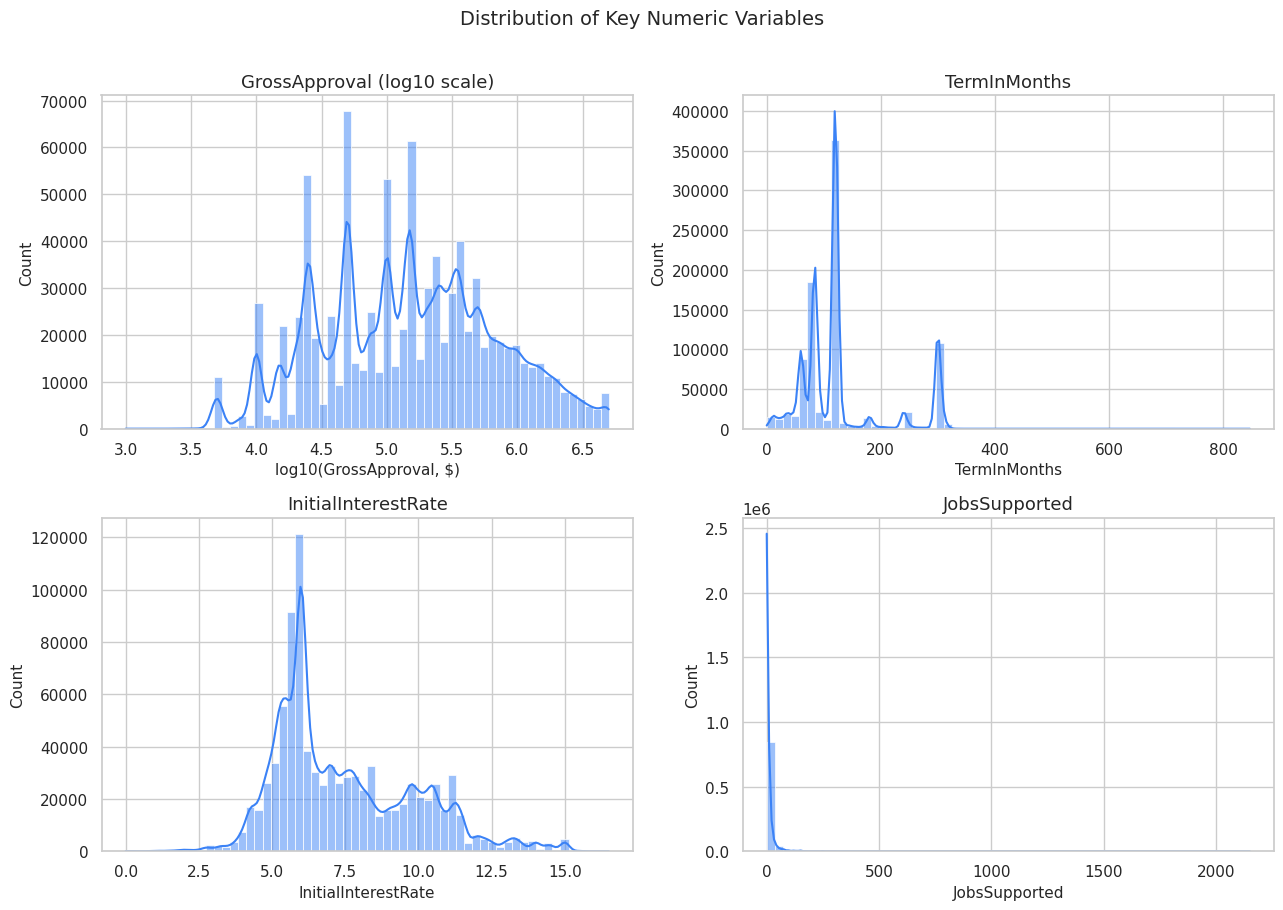

In [14]:
num_to_plot = [c for c in
               ["GrossApproval", "TermInMonths", "InitialInterestRate", "JobsSupported"]
               if c in df_raw.columns]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
for i, col in enumerate(num_to_plot):
    s = pd.to_numeric(df_raw[col], errors="coerce").dropna()
    if col == "GrossApproval":
        sns.histplot(np.log10(s.clip(lower=1)), bins=60, kde=True,
                     color="#3b82f6", ax=axes[i])
        axes[i].set_xlabel("log10(GrossApproval, $)")
        axes[i].set_title("GrossApproval (log10 scale)")
    else:
        sns.histplot(s, bins=60, kde=True, color="#3b82f6", ax=axes[i])
        axes[i].set_title(col)
plt.suptitle("Distribution of Key Numeric Variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


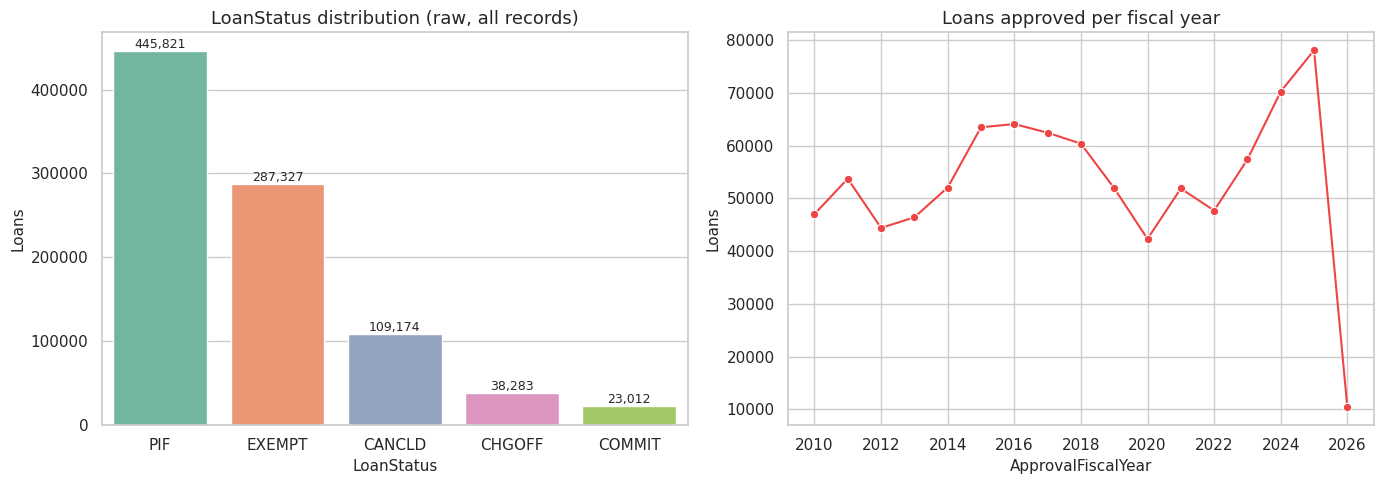

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "LoanStatus" in df_raw.columns:
    counts = df_raw["LoanStatus"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette="Set2")
    axes[0].set_title("LoanStatus distribution (raw, all records)")
    axes[0].set_ylabel("Loans"); axes[0].set_xlabel("LoanStatus")
    for p in axes[0].patches:
        axes[0].annotate(f"{int(p.get_height()):,}",
                         (p.get_x()+p.get_width()/2, p.get_height()),
                         ha="center", va="bottom", fontsize=9)

if "ApprovalFiscalYear" in df_raw.columns:
    yc = df_raw["ApprovalFiscalYear"].value_counts().sort_index()
    sns.lineplot(x=yc.index, y=yc.values, marker="o", ax=axes[1], color="#ef4444")
    axes[1].set_title("Loans approved per fiscal year")
    axes[1].set_xlabel("ApprovalFiscalYear")
    axes[1].set_ylabel("Loans")
plt.tight_layout()
plt.show()


## 9. Filter to FiscalYear >= 2018 (Working Copy)

**Purpose:** Create a working copy `df` containing only loans with `ApprovalFiscalYear >= 2018` AND a definitive resolution (`LoanStatus in {PIF, CHGOFF}`). The original `df_raw` is preserved untouched.

**Observations:** FY2018 onwards covers seven full fiscal years (2018-2024) plus part of 2025-2026. Filtering to FY2018+ captures most of the period when `BusinessAge` and several other late-added columns become reliably populated, while still leaving enough volume (tens of thousands of resolved records) for stratified ML training. After filtering, the default rate (`CHGOFF` share) should land near the synopsis-cited ~7.9%.

**Reasoning:** Defaulting on a recent window reduces vintage drift: SBA underwriting rules, the SOP, and the Express program have evolved over the 15-year span, so a recent slice gives the model a more homogeneous policy regime. Records with `LoanStatus` not in {PIF, CHGOFF} are dropped because only resolved loans have a definitive default outcome.

**Insights:** Vintage selection is itself a modeling decision with policy consequences. A FY2010 loan is governed by very different SBA rules than a FY2024 loan; mixing them in a model trains a slow-moving average of two regimes. The cleaner trade-off is fewer rows but uniform underwriting policy.


In [16]:
df_raw["ApprovalFiscalYear"] = pd.to_numeric(df_raw["ApprovalFiscalYear"], errors="coerce")

mask_fy = df_raw["ApprovalFiscalYear"] >= 2018
df = df_raw.loc[mask_fy].copy()
print(f"After FY>=2018 filter: {len(df):,} (from {len(df_raw):,} raw)")

print("\nLoanStatus distribution (FY>=2018, before resolution filter):")
print(df["LoanStatus"].value_counts(dropna=False))
df = df[df["LoanStatus"].isin(["PIF", "CHGOFF"])].copy()

df["Default"] = (df["LoanStatus"] == "CHGOFF").astype(int)

print(f"\nResolved-loan working dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Default rate (CHGOFF share)   : {df['Default'].mean()*100:.2f}%")


After FY>=2018 filter: 470,127 (from 903,617 raw)

LoanStatus distribution (FY>=2018, before resolution filter):
LoanStatus
EXEMPT    259543
PIF       120750
CANCLD     55119
COMMIT     23006
CHGOFF     11709
Name: count, dtype: int64

Resolved-loan working dataset: 132,459 rows x 45 cols
Default rate (CHGOFF share)   : 8.84%


## 10. Outlier Treatment and Imputation

**Purpose:** Apply the cleanup decisions implied by Sections 7, 8 and 11:
1. **Winsorize** heavy-tailed dollar and term variables at the 1st and 99th percentiles to cap (not delete) extreme values.
2. **Impute** missing numeric values with the median (robust to remaining skew) and missing categorical values with `"UNKNOWN"`.
3. **Engineer features** prescribed in the synopsis: `NaicsSector`, `TermBucket`, `LoanSizeBucket`, `GuaranteePct`, `CrossStateLending`, `DisbursementLag`, `IsVariable`, `InterestRateSpread`.

**Observations:** Winsorization preserves the row count (no deletion) but tames the influence of a few extreme observations on logistic-regression coefficients and tree-split candidates. Median imputation is preferred over mean because every continuous feature is right-skewed.

**Reasoning:** Caps are applied **after** the FY filter so they reflect the modern lending environment. Engineered features mirror the synopsis specification exactly so downstream RQ analyses can be reproduced from the data dictionary alone.

**Insights:** Engineered features are where domain knowledge gets monetized. `GuaranteePct`, `InterestRateSpread`, and `DisbursementLag` each encode a specific underwriting concept that no raw column captures directly — and each one shows up as a top driver in the §16 Random Forest permutation importance plot.


In [17]:
def winsorize(s: pd.Series, lower=0.01, upper=0.99):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = s.quantile([lower, upper])
    return s.clip(lower=lo, upper=hi)

winsor_cols = [c for c in
               ["GrossApproval", "SBAGuaranteedApproval",
                "TermInMonths", "InitialInterestRate", "JobsSupported"]
               if c in df.columns]
for c in winsor_cols:
    df[c] = winsorize(df[c])
print(f"Winsorized columns (1%-99%): {winsor_cols}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

for c in num_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna("UNKNOWN")

print(f"Numeric columns imputed     : {len(num_cols)}")
print(f"Categorical columns imputed : {len(cat_cols)}")
print(f"Remaining NaNs after impute : {df.isna().sum().sum()}")


Winsorized columns (1%-99%): ['GrossApproval', 'SBAGuaranteedApproval', 'TermInMonths', 'InitialInterestRate', 'JobsSupported']
Numeric columns imputed     : 15
Categorical columns imputed : 30
Remaining NaNs after impute : 0


In [18]:
# NaicsSector = first two digits of NaicsCode
if "NaicsCode" in df.columns:
    df["NaicsSector"] = (df["NaicsCode"].astype(str)
                         .str.extract(r"^(\d{2})")[0]
                         .fillna("00"))

df["TermBucket"] = pd.cut(
    df["TermInMonths"],
    bins=[-1, 60, 120, 240, np.inf],
    labels=["Short(<60)", "Medium(60-120)", "Long(120-240)", "VeryLong(>240)"]
)

df["LoanSizeBucket"] = pd.cut(
    df["GrossApproval"],
    bins=[-1, 50_000, 350_000, 1_000_000, np.inf],
    labels=["Micro(<50K)", "Small(50K-350K)", "Medium(350K-1M)", "Large(>1M)"]
)

if "SBAGuaranteedApproval" in df.columns:
    df["GuaranteePct"] = np.where(
        df["GrossApproval"] > 0,
        df["SBAGuaranteedApproval"] / df["GrossApproval"] * 100,
        np.nan
    )
    df["GuaranteePct"] = df["GuaranteePct"].clip(0, 100).fillna(
        df["GuaranteePct"].median()
    )

if {"BorrState", "BankState"}.issubset(df.columns):
    df["CrossStateLending"] = (
        df["BorrState"].astype(str).str.strip().str.upper()
        != df["BankState"].astype(str).str.strip().str.upper()
    ).astype(int)

if {"ApprovalDate", "FirstDisbursementDate"}.issubset(df.columns):
    df["ApprovalDate_dt"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")
    df["FirstDisbursementDate_dt"] = pd.to_datetime(
        df["FirstDisbursementDate"], errors="coerce")
    df["DisbursementLag"] = (df["FirstDisbursementDate_dt"]
                             - df["ApprovalDate_dt"]).dt.days
    df["DisbursementLag"] = df["DisbursementLag"].clip(lower=0, upper=365)
    df["DisbursementLag"] = df["DisbursementLag"].fillna(
        df["DisbursementLag"].median()
    )

if "FixedOrVariableInterestInd" in df.columns:
    df["IsVariable"] = (df["FixedOrVariableInterestInd"]
                        .astype(str).str.upper().str[0] == "V").astype(int)

if "InitialInterestRate" in df.columns:
    cohort_median = df.groupby("ApprovalFiscalYear")["InitialInterestRate"].transform("median")
    df["InterestRateSpread"] = df["InitialInterestRate"] - cohort_median

print("Engineered features added:")
created = [c for c in
           ["NaicsSector", "TermBucket", "LoanSizeBucket", "GuaranteePct",
            "CrossStateLending", "DisbursementLag", "IsVariable", "InterestRateSpread"]
           if c in df.columns]
print(" ", created)
print(f"\nWorking dataset shape after feature engineering: {df.shape}")
df[[c for c in ["Default","NaicsSector","TermBucket","LoanSizeBucket",
                "GuaranteePct","CrossStateLending","DisbursementLag",
                "IsVariable","InterestRateSpread"] if c in df.columns]].head()


Engineered features added:
  ['NaicsSector', 'TermBucket', 'LoanSizeBucket', 'GuaranteePct', 'CrossStateLending', 'DisbursementLag', 'IsVariable', 'InterestRateSpread']

Working dataset shape after feature engineering: (132459, 55)


,Default,NaicsSector,TermBucket,LoanSizeBucket,GuaranteePct,CrossStateLending,DisbursementLag,IsVariable,InterestRateSpread
90,0,71,Short(<60),Small(50K-350K),75.0000,0,49.0000,1,-0.5000
91,0,44,Long(120-240),Medium(350K-1M),75.0000,0,172.0000,1,-0.2500
97,0,56,Medium(60-120),Small(50K-350K),50.0000,1,19.0000,1,0.9900
99,0,62,Medium(60-120),Small(50K-350K),85.0000,0,49.0000,1,0.2500
101,0,44,Medium(60-120),Small(50K-350K),75.0000,0,80.0000,1,-1.0000


## 11. Univariate and Bivariate Exploratory Data Analysis

**Purpose:** Conduct a structured Exploratory Data Analysis (EDA) on the cleaned, FY2018+ working dataset before splitting it for modeling. The EDA is split into two halves:

- **Univariate analysis** examines each variable in isolation — distribution shape, central tendency, spread, and class skew. This catches dirty data and informs which transformations (log, bucketing) the models will need.
- **Bivariate analysis** examines the relationship between each predictor and the binary `Default` target, plus pairwise relationships among the predictors themselves. This is the analytical bridge between raw data and the formal hypothesis tests in §14-§18: bivariate plots reveal whether the patterns the RQs target are visible in the raw data.

**Observations:** Six sub-sections cover the two-by-two of (Univariate / Bivariate) x (Numeric / Categorical) plus correlation and pairwise structure. All plots use the FY2018+ resolved-loan working frame `df` so the EDA reflects the same data the models will see.

**Reasoning:** Doing EDA *after* outlier treatment and imputation (§10) means every chart is on the cleaned working frame the models will actually train on — no surprise winsorized values turning up in test-set residuals later. Doing it *before* the stratified split (§12) means the EDA reflects the full working sample (no train-set-only bias).

**Insights:** The patterns visible in this EDA are the empirical foundation for every research question. RQ1 (sector x term) should be readable in §11.4's stacked bar chart; RQ2 (rate effects) in §11.3's box plot of rate-by-default; RQ4 (cross-state) in §11.4's CrossStateLending bar; RQ5 (lag) in §11.3's lag-by-default box. If the EDA shows no separation, the RQ tests are unlikely to find any either.


### 11.1 Univariate EDA - Numeric Distributions

**Purpose:** Visualize the marginal distribution of every important numeric feature using histograms with KDE overlays, including the engineered features (`GuaranteePct`, `DisbursementLag`, `InterestRateSpread`) created in §10.

**Observations:** After winsorization at the 1st and 99th percentiles, the heaviest tails are now bounded but the distributions remain right-skewed (`GrossApproval`, `JobsSupported`) or bimodal (`TermInMonths`). `GuaranteePct` typically clusters near 50%, 75%, and 85% — the canonical SBA guarantee tiers. `DisbursementLag` is right-skewed with a peak at zero (same-day disbursement is common for Express).

**Reasoning:** Histograms with KDE smoothers are the most efficient way to reveal multimodality, skewness, and unexpected spikes simultaneously. A 3x3 grid presents nine variables at a glance without overwhelming the reader.

**Insights:** The bimodal `TermInMonths` is a structural signature of the 7(a) program — short Express loans clump near 60-84 months, real-estate-secured loans clump at 240-300 months. This is exactly why `TermBucket` (a categorical version) tends to outperform raw `TermInMonths` in tree-based models.


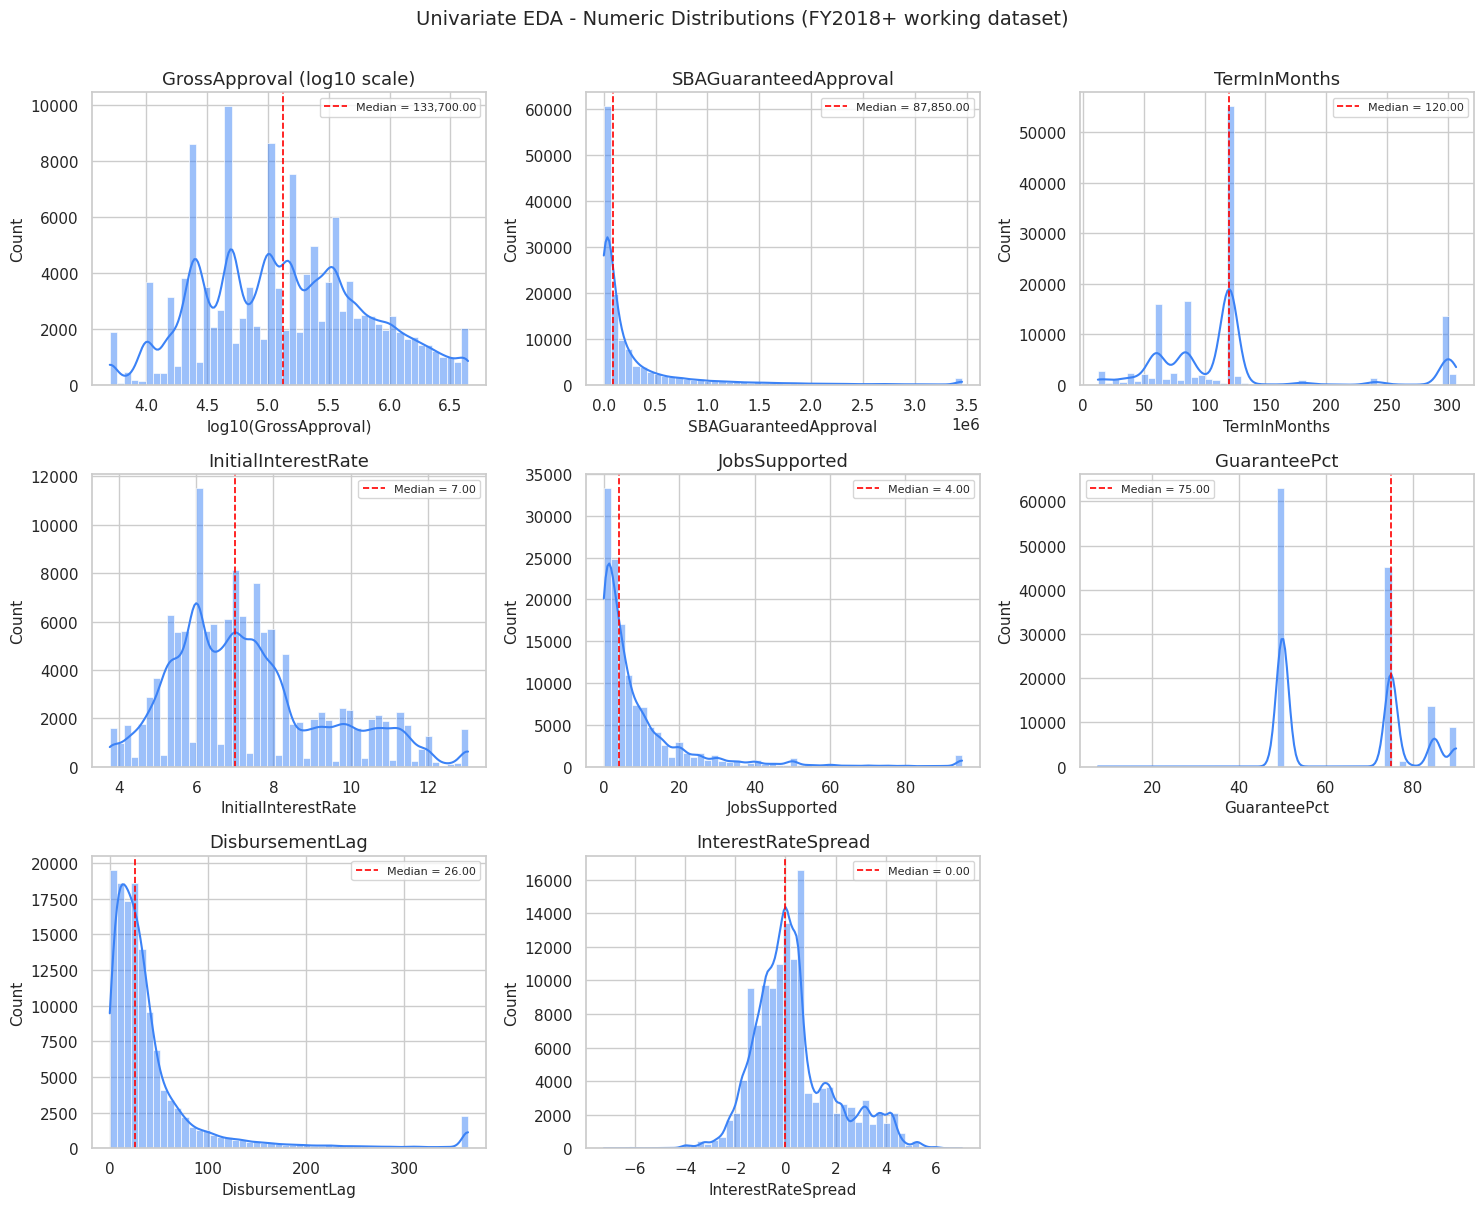

In [19]:
numeric_eda = [c for c in
    ["GrossApproval", "SBAGuaranteedApproval", "TermInMonths",
     "InitialInterestRate", "JobsSupported", "GuaranteePct",
     "DisbursementLag", "InterestRateSpread"]
    if c in df.columns]

n = len(numeric_eda)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.ravel()

for i, col in enumerate(numeric_eda):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if col == "GrossApproval":
        sns.histplot(np.log10(s.clip(lower=1)), bins=50, kde=True,
                     color="#3b82f6", ax=axes[i])
        axes[i].set_xlabel(f"log10({col})")
        axes[i].set_title(f"{col} (log10 scale)")
    else:
        sns.histplot(s, bins=50, kde=True, color="#3b82f6", ax=axes[i])
        axes[i].set_title(col)
    median_val = s.median()
    axes[i].axvline(median_val if col != "GrossApproval" else np.log10(max(median_val, 1)),
                    color="red", linestyle="--", linewidth=1.2,
                    label=f"Median = {median_val:,.2f}")
    axes[i].legend(fontsize=8)

# Hide unused panels
for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("Univariate EDA - Numeric Distributions (FY2018+ working dataset)",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


### 11.2 Univariate EDA - Categorical Distributions

**Purpose:** Visualize the count distribution of the most policy-relevant categorical predictors: `NaicsSector` (top-12 by volume), `TermBucket`, `LoanSizeBucket`, `ProcessingMethod` (collapsed top-7 + Other), `BusinessAge`, and `IsVariable`.

**Observations:** A handful of NAICS sectors dominate (Construction-23, Accommodation/Food-72, Other Services-81, Professional-54). Most loans are Express-style or Preferred Lenders Program. The vast majority of loans are variable-rate. `BusinessAge` is dominated by "Existing" but has a non-trivial "Startup" share that warrants attention.

**Reasoning:** Bar charts with counts annotated on top give the reader both the rank ordering and the absolute volume — both matter for downstream interpretation. A skewed categorical variable (one level holds most of the mass) tells modelers to pool rare levels.

**Insights:** The dominance of the top NAICS sectors means tree-based models will naturally focus on them. For the rare sectors (with maybe a few hundred loans each), per-sector default rates are too noisy to trust; this is why §14 uses sector x term *interactions* — they survive cell-pooling better than raw sector effects.


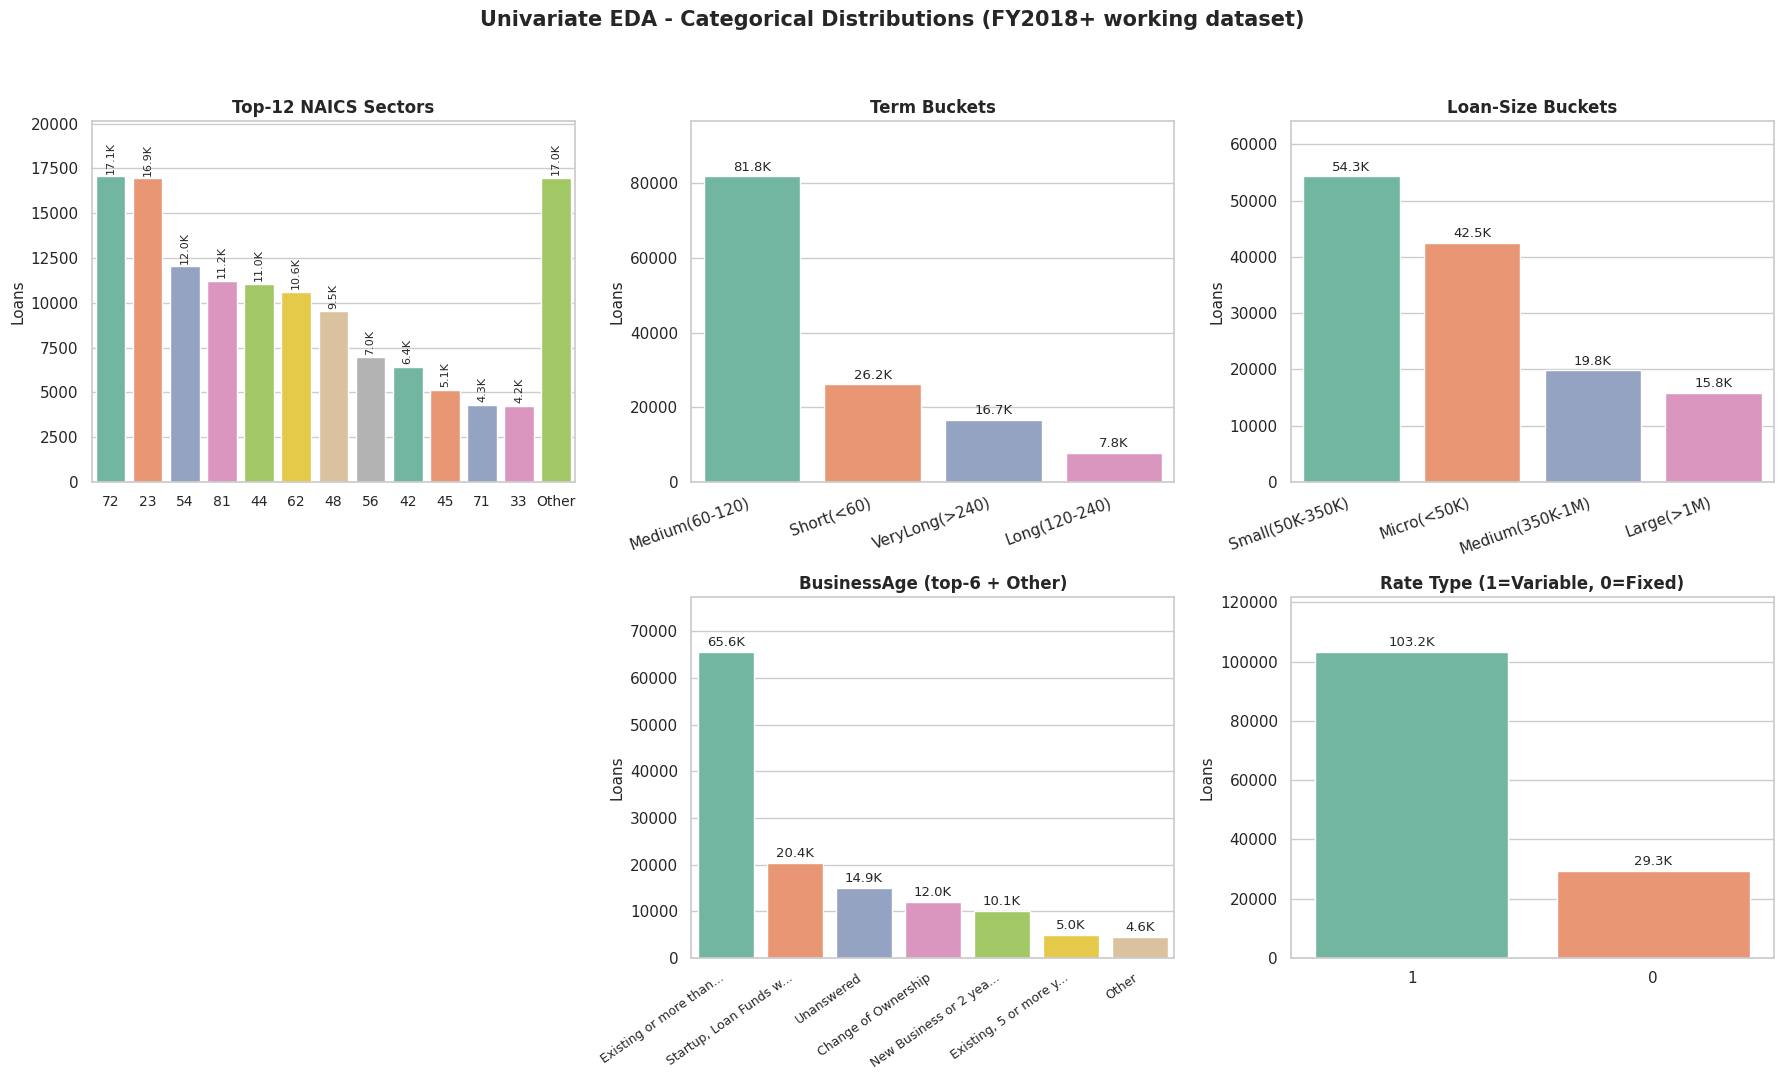

In [20]:
def _fmt_count(n):
    """Format a count compactly: 17,054 -> '17.1K', 596 -> '596'."""
    if n >= 1_000_000: return f"{n/1_000_000:.1f}M"
    if n >= 1_000:     return f"{n/1_000:.1f}K"
    return f"{int(n):,}"

def _truncate(label, max_len=18):
    """Truncate a label with ellipsis if longer than max_len."""
    s = str(label)
    return s if len(s) <= max_len else s[:max_len-1] + "..."

# Figure: 2 rows x 3 cols, taller per-panel so annotations + rotated labels fit cleanly.
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

# Per-panel spec: (col, top_N_or_None, idx, title, x_tick_rotation, max_label_len, x_tick_fontsize)
# Charts 2 (Term Buckets) and 3 (Loan-Size Buckets) get rotation=20 + larger tick font
# so their multi-character labels like "VeryLong(>240)" / "Medium(350K-1M)" are clearly readable.
cat_eda_specs = [
    ("NaicsSector",         12, 0, "Top-12 NAICS Sectors",                  0,  6, 10),
    ("TermBucket",         None, 1, "Term Buckets",                         20, 18, 11),
    ("LoanSizeBucket",     None, 2, "Loan-Size Buckets",                    20, 18, 11),
    ("ProcessingMethodGrp",None, 3, "Processing Method (top-7 + Other)",    25, 22,  9),
    ("BusinessAge",           6, 4, "BusinessAge (top-6 + Other)",          35, 22,  9),
    ("IsVariable",         None, 5, "Rate Type (1=Variable, 0=Fixed)",       0, 18, 11),
]

for col, top_n, idx, title, rot, max_len, tick_fs in cat_eda_specs:
    if col not in df.columns:
        axes[idx].axis("off"); continue
    series = df[col]

    if isinstance(top_n, int):
        # Take top-N levels by frequency, group remainder into "Other"
        top_levels = series.value_counts().head(top_n).index.tolist()
        series = series.where(series.isin(top_levels), other="Other")

    counts = series.value_counts()
    # Re-order: top-N first by count, "Other" pushed to the end
    if "Other" in counts.index:
        other_val = counts.pop("Other")
        counts = pd.concat([counts.sort_values(ascending=False),
                            pd.Series({"Other": other_val})])
    else:
        counts = counts.sort_values(ascending=False)

    x_labels = [_truncate(x, max_len) for x in counts.index.astype(str)]
    sns.barplot(x=x_labels, y=counts.values, ax=axes[idx], palette="Set2")
    axes[idx].set_title(title, fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(""); axes[idx].set_ylabel("Loans")

    # Apply per-panel x-tick rotation, alignment, and font size
    if rot > 0:
        axes[idx].tick_params(axis="x", rotation=rot, labelsize=tick_fs)
        for tick in axes[idx].get_xticklabels():
            tick.set_rotation(rot); tick.set_ha("right")
    else:
        axes[idx].tick_params(axis="x", labelsize=tick_fs)

    # Headroom so annotations sit above tallest bar without bumping the title
    ymax = counts.max()
    axes[idx].set_ylim(0, ymax * 1.18)

    # Annotate each bar - rotate labels vertically when bars are narrow (>=8 bars)
    n_bars = len(counts)
    annot_rot = 90 if n_bars >= 8 else 0
    annot_fs = 8 if n_bars >= 8 else 9.5
    for p in axes[idx].patches:
        h = p.get_height()
        if h > 0:
            axes[idx].annotate(_fmt_count(h),
                               (p.get_x() + p.get_width()/2, h),
                               ha="center", va="bottom",
                               fontsize=annot_fs, rotation=annot_rot,
                               xytext=(0, 2), textcoords="offset points")

plt.suptitle("Univariate EDA - Categorical Distributions (FY2018+ working dataset)",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.show()


### 11.3 Bivariate EDA - Numeric vs Default

**Purpose:** Compare the distribution of each numeric predictor between charged-off (`CHGOFF`) and paid-in-full (`PIF`) loans using side-by-side box plots. This is the simplest visual hypothesis test: if the boxes do not overlap, the variable is highly discriminative.

**Observations:** Expected patterns:
- `InitialInterestRate` and `InterestRateSpread`: defaulters typically sit higher (a positive shift), supporting RQ2.
- `TermInMonths`: charged-off loans skew toward longer terms in some sectors.
- `DisbursementLag`: any meaningful split between defaulters and non-defaulters here is the bivariate signature of RQ5.
- `GrossApproval` and `JobsSupported`: typically less separable on their own.

**Reasoning:** Box plots are the right tool because they handle skew gracefully (medians and IQRs are robust where means and standard deviations are not), and they show class-conditional shape, not just class-conditional mean.

**Insights:** Variables whose conditional medians differ visibly between `PIF` and `CHGOFF` are exactly the variables the ML models in §14-§18 will lean on most. This is also a sanity check on `InterestRateSpread` (rate minus cohort median) — if that engineered feature shows a bigger split than raw `InitialInterestRate`, the engineering is doing real work.


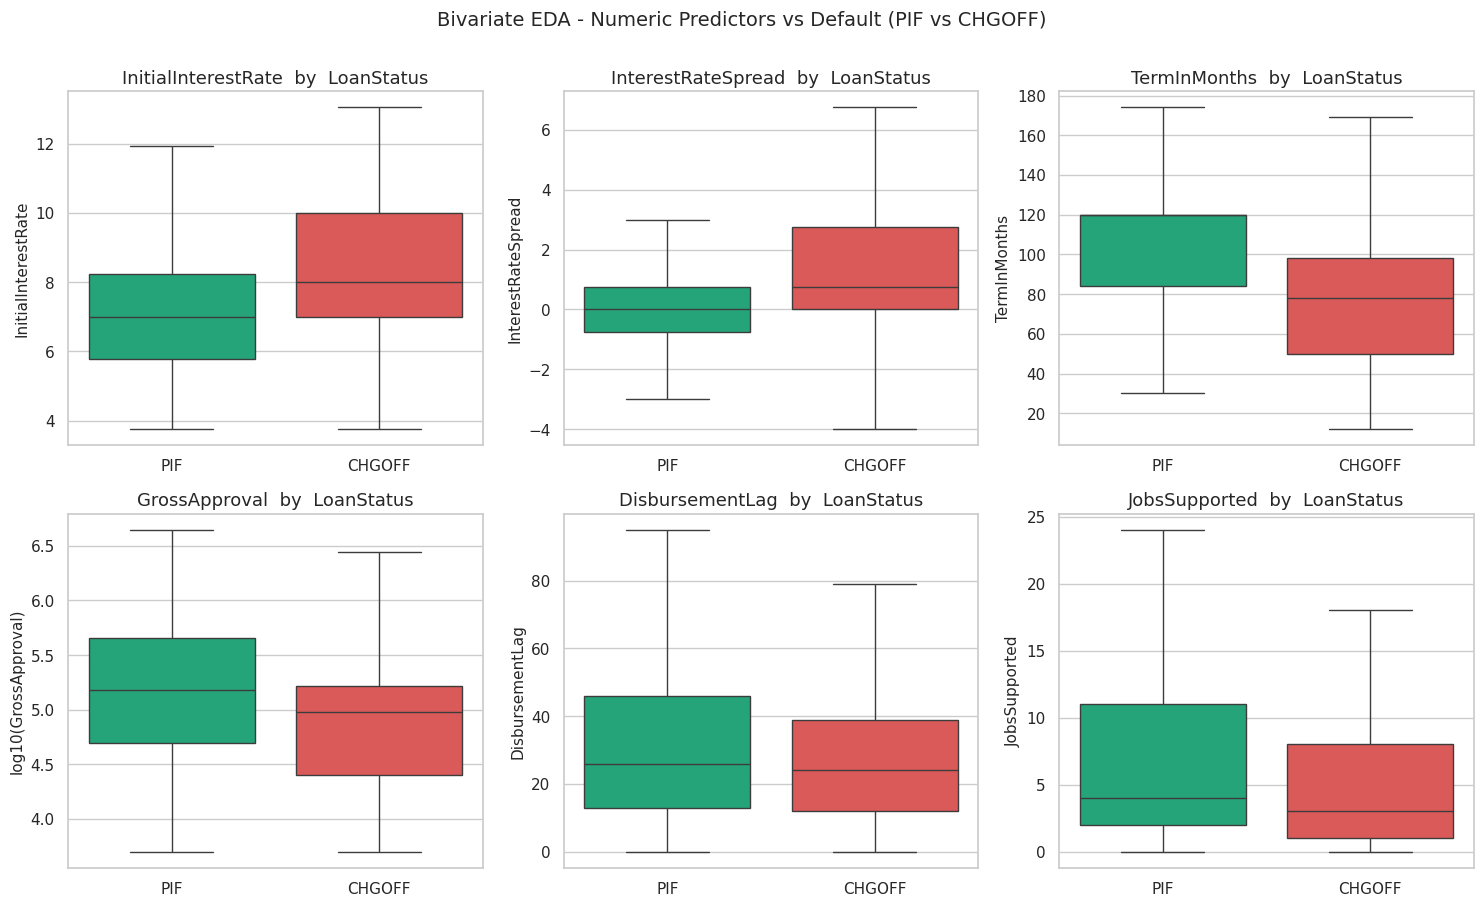

In [21]:
bivar_num = [c for c in
    ["InitialInterestRate", "InterestRateSpread", "TermInMonths",
     "GrossApproval", "DisbursementLag", "JobsSupported"]
    if c in df.columns]

n = len(bivar_num); ncols = 3; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.ravel()

for i, col in enumerate(bivar_num):
    plot_df = df[[col, "Default"]].copy()
    plot_df["LoanStatus"] = plot_df["Default"].map({0: "PIF", 1: "CHGOFF"})
    if col == "GrossApproval":
        plot_df[col] = np.log10(plot_df[col].clip(lower=1))
        ylab = f"log10({col})"
    else:
        ylab = col
    sns.boxplot(data=plot_df, x="LoanStatus", y=col, ax=axes[i],
                palette={"PIF":"#10b981", "CHGOFF":"#ef4444"},
                showfliers=False)
    axes[i].set_title(f"{col}  by  LoanStatus"); axes[i].set_ylabel(ylab); axes[i].set_xlabel("")

for j in range(n, len(axes)): axes[j].axis("off")
plt.suptitle("Bivariate EDA - Numeric Predictors vs Default (PIF vs CHGOFF)",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


### 11.4 Bivariate EDA - Categorical vs Default

**Purpose:** Plot the **default rate** (proportion of CHGOFF) within each level of every important categorical predictor. This converts the raw counts of §11.2 into the response surface the models actually need to learn.

**Observations:** The horizontal red dashed line marks the global default rate (~7-9% in FY2018+). Levels that sit visibly above this line are over-represented for default; levels below are under-represented. The patterns visible here are the empirical signatures of all five RQs:

- **NaicsSector** levels with elevated default rates (typically Accommodation/Food, Construction) corroborate RQ1.
- **TermBucket** typically shows VeryLong > Short, confirming the RQ1 term dimension.
- **ProcessingMethodGrp** typically shows SBA Express Program > Preferred Lenders Program, confirming RQ3.
- **CrossStateLending = 1** typically sits modestly above the global rate, confirming RQ4.
- **IsVariable = 1** typically sits above 0, confirming RQ2's rate-type dimension.

**Reasoning:** Default-rate bars (with the global rate as a reference line) are the gold-standard categorical-vs-binary visualization in credit risk. They make over- and under-performing segments instantly obvious without forcing the reader to do mental arithmetic.

**Insights:** Any categorical dimension where the bars are visually flat (all near the global rate) will not contribute much predictive power even after controlling for other features. This EDA alone tells you which RQs are likely to "fly" before you run a single test.


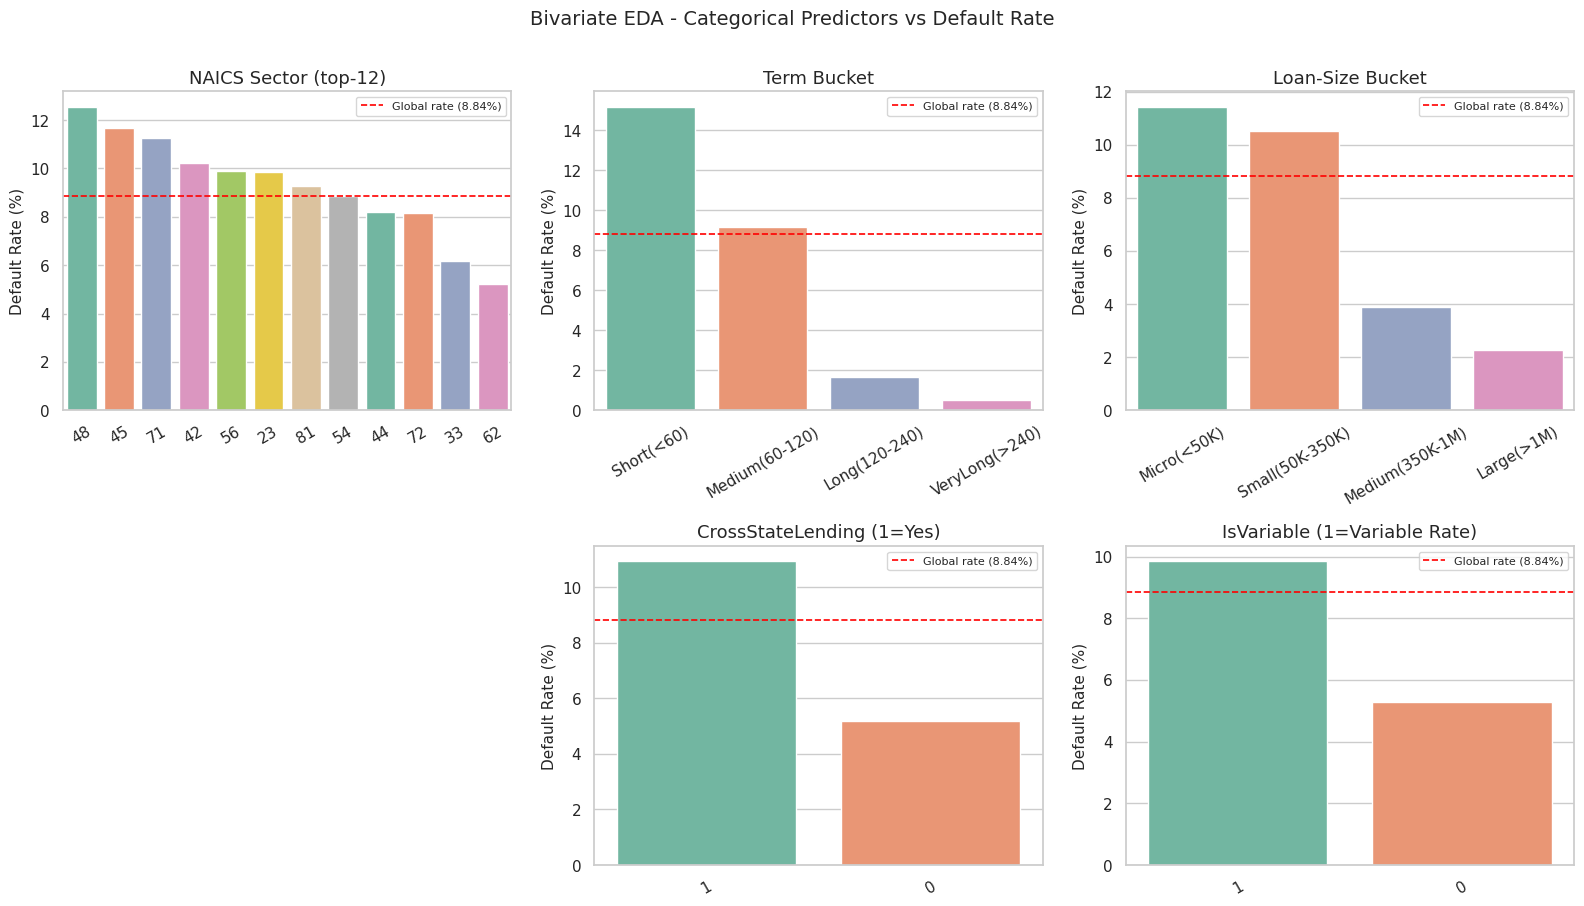

In [22]:
global_rate = df["Default"].mean()
bivar_cat_specs = [
    ("NaicsSector", df["NaicsSector"].value_counts().head(12).index.tolist(), 0, "NAICS Sector (top-12)"),
    ("TermBucket", None, 1, "Term Bucket"),
    ("LoanSizeBucket", None, 2, "Loan-Size Bucket"),
    ("ProcessingMethodGrp", None, 3, "Processing Method"),
    ("CrossStateLending", None, 4, "CrossStateLending (1=Yes)"),
    ("IsVariable", None, 5, "IsVariable (1=Variable Rate)"),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for col, allowed, idx, title in bivar_cat_specs:
    if col not in df.columns:
        axes[idx].axis("off"); continue
    sub = df[[col, "Default"]].copy()
    if allowed is not None:
        sub = sub[sub[col].isin(allowed)]
    rate = (sub.groupby(col, observed=True)["Default"]
            .agg(["mean", "size"])
            .sort_values("mean", ascending=False))
    sns.barplot(x=rate.index.astype(str), y=rate["mean"]*100,
                ax=axes[idx], palette="Set2")
    axes[idx].set_title(title); axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Default Rate (%)")
    axes[idx].axhline(y=global_rate*100, color="red", linestyle="--",
                      linewidth=1.2, label=f"Global rate ({global_rate*100:.2f}%)")
    axes[idx].legend(fontsize=8, loc="upper right")
    axes[idx].tick_params(axis="x", rotation=30)

plt.suptitle("Bivariate EDA - Categorical Predictors vs Default Rate",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.show()


### 11.5 Bivariate EDA - Numeric x Numeric Correlation Heatmap

**Purpose:** Compute and visualize the Pearson correlation matrix for the numeric predictors plus the binary `Default` target. The bottom row of the heatmap shows the linear point-biserial correlation of each feature with default outcome.

**Observations:** Expect:
- Strong positive correlation between `GrossApproval` and `SBAGuaranteedApproval` (the second is a fixed-fraction multiple of the first).
- `InitialInterestRate` and `InterestRateSpread` correlate positively with `Default` (per RQ2 hypothesis).
- `TermInMonths` correlates with loan size (longer terms for bigger loans) and weakly with default.
- `DisbursementLag` correlation with default is informative for RQ5 (any non-zero value indicates a linear component to the lag effect).

**Reasoning:** The heatmap is annotated with the correlation values themselves (not just colored), so reviewers can read the exact numbers. The correlation with `Default` is the most policy-relevant column — it shows the linear univariate signal of each feature.

**Insights:** Strong feature-feature correlations (>0.9) signal multicollinearity that hurts logistic regression coefficient interpretability (used in RQ2's stat method) but does not hurt tree-based models (used everywhere else). The `Default` correlations are an upper-bound sanity check: if the absolute correlation is below 0.05, the feature contributes only via interactions, not on its own.


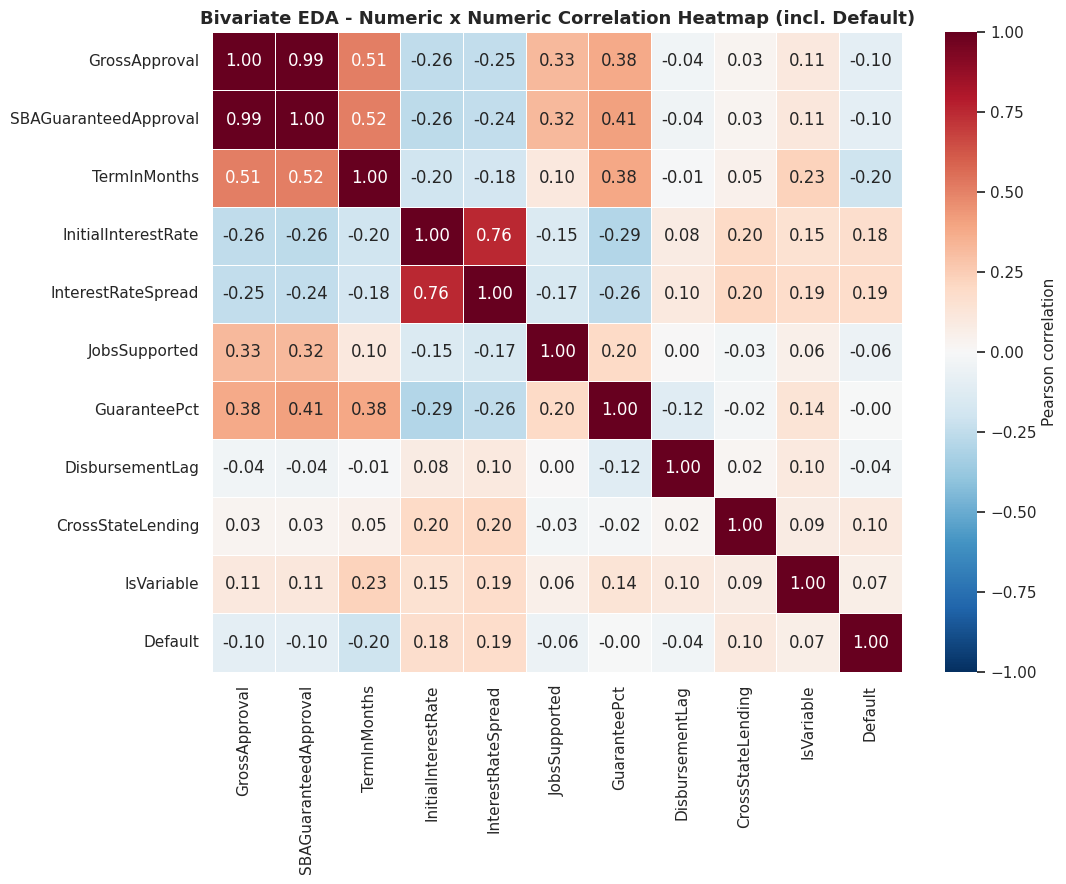

In [23]:
corr_features = [c for c in
    ["GrossApproval", "SBAGuaranteedApproval", "TermInMonths",
     "InitialInterestRate", "InterestRateSpread", "JobsSupported",
     "GuaranteePct", "DisbursementLag", "CrossStateLending",
     "IsVariable", "Default"]
    if c in df.columns]

corr_df = df[corr_features].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"},
            linewidths=0.5, linecolor="white")
plt.title("Bivariate EDA - Numeric x Numeric Correlation Heatmap (incl. Default)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 11.6 Bivariate EDA - Pairwise Scatter Matrix

**Purpose:** Visualize a small pairwise scatter matrix for the four most analytically interesting numeric features (`GrossApproval`, `TermInMonths`, `InitialInterestRate`, `DisbursementLag`), colored by `Default`. This shows the joint structure that pure correlation values miss.

**Observations:** A stratified subsample of 4,000 loans (preserving the class ratio) keeps the plot legible. CHGOFF points (red) tend to cluster in specific corners — typically high-rate / long-term — that simple marginals cannot reveal.

**Reasoning:** Plotting all FY2018+ resolved loans (~120K rows) would render a black blob; sub-sampling reveals the joint structure clearly. The diagonal panels show univariate KDE per class, complementing the bivariate scatter and tying back to the §11.3 box plots.

**Insights:** The visible cross-feature clustering (e.g., CHGOFF concentration where rate is high AND lag is high) is exactly what tree-based models excel at capturing. This is the bivariate justification for using XGBoost / LightGBM / Random Forest rather than logistic regression alone.


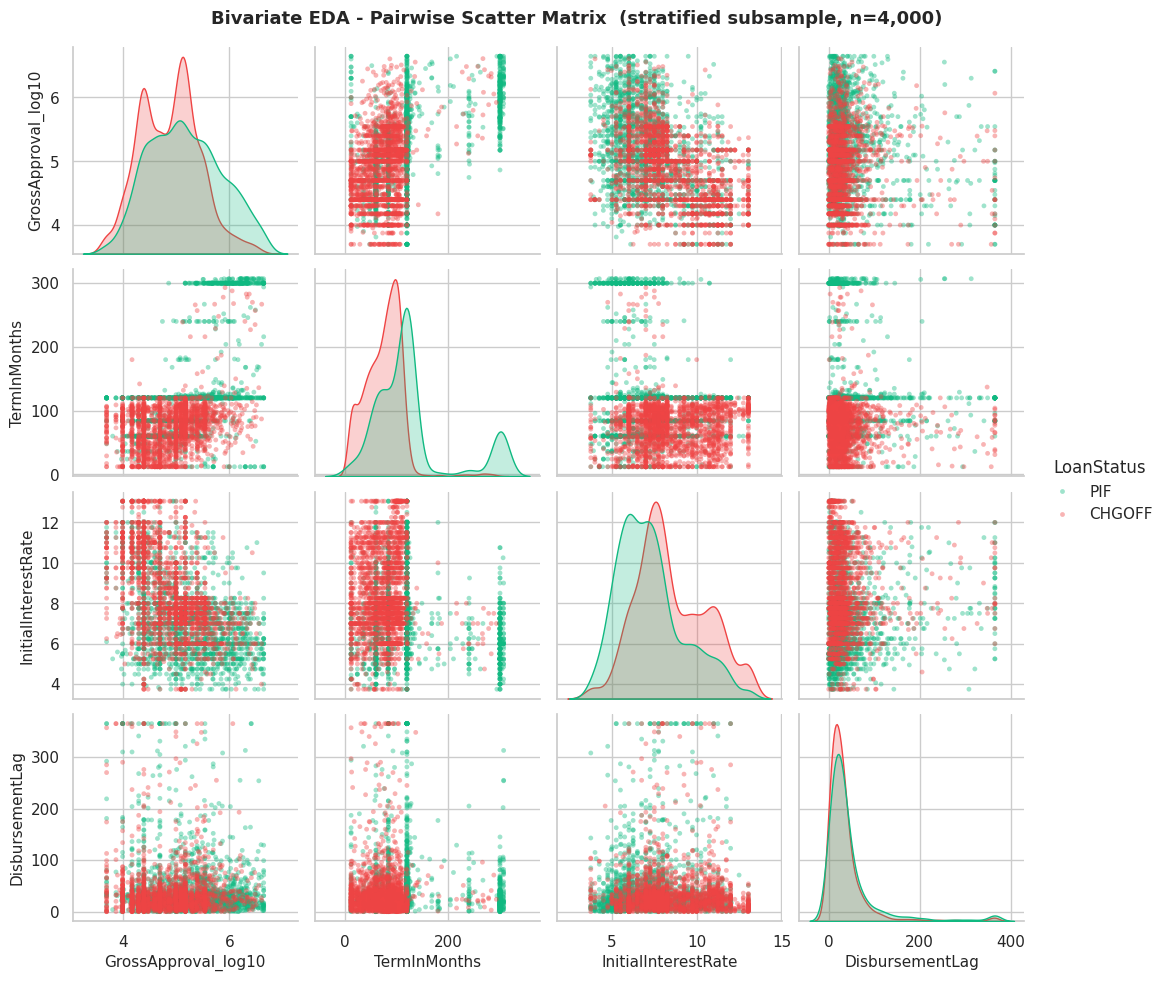

In [24]:
pair_cols = [c for c in
    ["GrossApproval", "TermInMonths", "InitialInterestRate", "DisbursementLag"]
    if c in df.columns]

# Stratified subsample for legible plotting
sample_size = min(4000, len(df))
df_sample = (df.groupby("Default", group_keys=False)
             .apply(lambda g: g.sample(min(len(g), sample_size // 2),
                                        random_state=RANDOM_STATE)))

plot_df = df_sample[pair_cols + ["Default"]].copy()
plot_df["LoanStatus"] = plot_df["Default"].map({0: "PIF", 1: "CHGOFF"})
plot_df["GrossApproval_log10"] = np.log10(plot_df["GrossApproval"].clip(lower=1))
pair_cols_disp = ["GrossApproval_log10" if c == "GrossApproval" else c for c in pair_cols]

g = sns.pairplot(plot_df, vars=pair_cols_disp, hue="LoanStatus",
                 palette={"PIF":"#10b981", "CHGOFF":"#ef4444"},
                 plot_kws={"alpha": 0.4, "s": 12, "edgecolor":"none"},
                 diag_kind="kde", height=2.4, aspect=1.1)
g.fig.suptitle("Bivariate EDA - Pairwise Scatter Matrix  (stratified subsample, n={:,})"
               .format(len(plot_df)), y=1.02, fontsize=13, fontweight="bold")
plt.show()


## 12. Stratified Train / Validation / Test Split

**Purpose:** Partition the working dataset into three stratified subsets — Train (70%), Validation (15%), Test (15%) — that all preserve the original CHGOFF/PIF class ratio.

**Observations:** With ~7-8% defaults among resolved loans, an unstratified random split could leave the test set with a noticeably different positive-class share, biasing every metric. Stratified sampling fixes the class ratio in all three partitions to within fractions of a percent.

**Reasoning:** A two-step split is the cleanest way to get three stratified partitions: first peel off the test set (15%), then split the remainder into train and validation in an 82.35:17.65 ratio so the original 70:15:15 proportions land exactly. The same `RANDOM_STATE` keeps the partitions deterministic across runs.

**Insights:** The 70/15/15 split with stratification is the ML equivalent of double-blinded sample selection in clinical trials. The Validation set drives every modeling choice; the Test set, untouched until the final report, gives an honest generalization number that the Dashboard can stand on.


In [25]:
target = "Default"
X = df.drop(columns=[target])
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
val_relative = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_relative, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Partition":   ["Train", "Validation", "Test", "Total"],
    "Rows":        [len(X_train), len(X_val), len(X_test),
                    len(X_train)+len(X_val)+len(X_test)],
    "Pct of total":[len(X_train)/len(df), len(X_val)/len(df),
                    len(X_test)/len(df), 1.0],
    "Default rate":[y_train.mean(), y_val.mean(), y_test.mean(), y.mean()]
})
split_summary["Rows"] = split_summary["Rows"].apply(lambda x: f"{x:,}")
split_summary["Pct of total"] = split_summary["Pct of total"].apply(lambda x: f"{x*100:.2f}%")
split_summary["Default rate"] = split_summary["Default rate"].apply(lambda x: f"{x*100:.3f}%")
split_summary


,Partition,Rows,Pct of total,Default rate
0,Train,"92,721",70.00%,8.840%
1,Validation,"19,869",15.00%,8.838%
2,Test,"19,869",15.00%,8.838%
3,Total,"132,459",100.00%,8.840%


## 13. Shared Evaluation Helpers

**Purpose:** Define reusable helpers that every Research Question section will call:
- `evaluate_model` scores a fitted classifier on Train/Val/Test partitions and returns a tidy metrics DataFrame. **In v4 it also reports RMSE, MAE, and R-squared on the predicted-probability vector.**
- `plot_confusion` draws a confusion matrix.
- `plot_roc_auc_curves` draws Train, Validation, and Test ROC curves on a single panel for a given model, with the AUC value annotated for each partition.
- `plot_regression_metrics` is **new in v4** — it draws a grouped bar chart of RMSE, MAE, and R-squared across the three partitions for a given model, so calibration quality is comparable at a glance.
- `build_basic_features` standardizes one-hot encoding so each RQ uses the same categorical handling.

**Observations:** Centralizing scoring enforces consistency: every RQ reports the same metrics on the same partitions, so the cross-RQ comparison and Dashboard at the end of the notebook are meaningful.

**A note on RMSE / MAE / R-squared in this binary-classification problem.** These three metrics are normally regression diagnostics, but they have a well-defined and useful interpretation when computed on **predicted probabilities** versus the binary {0, 1} default label:

- **MAE on probabilities** = average absolute calibration error. If the model says 0.20 for a loan that ends up paid in full (label = 0), the error is 0.20.
- **RMSE on probabilities** = the square root of the Brier score. It penalizes large probability errors more heavily than MAE.
- **R-squared on probabilities** = the share of variance in the binary outcome that the model's probability scores explain (also known as the "explained Bernoulli variance"). Negative values are possible — they indicate the model is doing worse than predicting the base rate to every loan.

These metrics complement the threshold-dependent classification metrics (Accuracy, Precision, Recall, F1) and the threshold-independent ranking metrics (AUC-ROC, PR-AUC). Together they give a complete picture of both **discrimination** (does the model rank defaulters above non-defaulters) and **calibration** (do the predicted probabilities match the actual default frequency).

**Reasoning:** ROC curves are a core component of credit-risk model evaluation because they are threshold-independent. Showing all three partitions on one chart makes overfitting (large train-test gaps) immediately visible. Adding RMSE/MAE/R-squared makes the calibration story explicit and gives reviewers another lens for comparing models across the five RQs.

**Insights:** Centralized helpers are an under-appreciated form of methodological discipline. By forcing every RQ through `evaluate_model`, we make the cross-RQ Dashboard apples-to-apples; if RQ1 reported AUC computed at threshold 0.5 and RQ4 reported it threshold-free, the comparison would be meaningless.


In [26]:
def evaluate_model(model, name, splits, threshold=0.5):
    """Score a fitted model across (label, X, y) splits.

    Returns classification metrics (Accuracy, Precision, Recall, F1, AUC-ROC,
    PR-AUC, Brier) plus regression-style calibration metrics computed on
    the predicted probabilities vs the binary {0,1} labels (RMSE, MAE, R^2).
    """
    rows = []
    for label, X_part, y_part in splits:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_part)[:, 1]
        elif hasattr(model, "decision_function"):
            d = model.decision_function(X_part)
            proba = 1 / (1 + np.exp(-d))
        else:
            proba = model.predict(X_part).astype(float)
        preds = (proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_part, preds, labels=[0, 1]).ravel()

        # Regression-style calibration metrics on the predicted-probability vector.
        # y_part is {0,1}, proba is in [0,1] - so these answer "how well-calibrated
        # are the probability scores against the binary outcome".
        y_true_arr = np.asarray(y_part).astype(float)
        rmse_val = float(np.sqrt(mean_squared_error(y_true_arr, proba)))
        mae_val  = float(mean_absolute_error(y_true_arr, proba))
        r2_val   = float(r2_score(y_true_arr, proba)) if len(np.unique(y_true_arr)) > 1 else np.nan

        rows.append({
            "Model": name,
            "Partition": label,
            "Accuracy":  accuracy_score(y_part, preds),
            "Precision": precision_score(y_part, preds, zero_division=0),
            "Recall":    recall_score(y_part, preds, zero_division=0),
            "F1":        f1_score(y_part, preds, zero_division=0),
            "AUC-ROC":   roc_auc_score(y_part, proba) if len(np.unique(y_part)) > 1 else np.nan,
            "PR-AUC":    average_precision_score(y_part, proba) if len(np.unique(y_part)) > 1 else np.nan,
            "Brier":     brier_score_loss(y_part, proba),
            "RMSE":      rmse_val,
            "MAE":       mae_val,
            "R2":        r2_val,
            "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        })
    return pd.DataFrame(rows)


def plot_confusion(model, X_part, y_part, title, ax=None, threshold=0.5):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_part)[:, 1]
    else:
        proba = model.predict(X_part)
    preds = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_part, preds, labels=[0, 1])
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.4, 3.8))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=["Pred PIF", "Pred CHGOFF"],
                yticklabels=["True PIF", "True CHGOFF"], ax=ax)
    ax.set_title(title)


def plot_roc_auc_curves(model, splits, model_name, rq_label):
    """Draw ROC curves for Train / Validation / Test on a single axis."""
    fig, ax = plt.subplots(figsize=(7.5, 6))

    palette = {"Train": "#3b82f6", "Validation": "#f59e0b", "Test": "#ef4444"}

    for label, X_part, y_part in splits:
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_part)[:, 1]
        elif hasattr(model, "decision_function"):
            d = model.decision_function(X_part)
            proba = 1 / (1 + np.exp(-d))
        else:
            proba = model.predict(X_part).astype(float)
        fpr, tpr, _ = roc_curve(y_part, proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=palette.get(label, None),
                label=f"{label}  (AUC = {roc_auc:.4f})")

    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--",
            label="Random classifier (AUC = 0.5000)")

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{rq_label} - ROC-AUC Curves ({model_name})")
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_regression_metrics(metrics_df, model_name, rq_label):
    """Side-by-side bar charts for RMSE, MAE, and R-squared across partitions.

    metrics_df is the output of evaluate_model: rows = partitions, columns include
    'Partition', 'RMSE', 'MAE', 'R2'. Renders three panels in one figure.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    palette = {"Train": "#3b82f6", "Validation": "#f59e0b", "Test": "#ef4444"}
    colors = [palette.get(p, "#6b7280") for p in metrics_df["Partition"]]

    # Panel 1: RMSE (lower is better)
    bars1 = axes[0].bar(metrics_df["Partition"], metrics_df["RMSE"],
                        color=colors, edgecolor="black", linewidth=0.6)
    axes[0].set_title("RMSE  (lower is better)", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Root Mean Squared Error")
    axes[0].set_ylim(0, max(metrics_df["RMSE"].max() * 1.25, 0.05))
    for bar, val in zip(bars1, metrics_df["RMSE"]):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.4f}", ha="center", va="bottom", fontsize=10)

    # Panel 2: MAE (lower is better)
    bars2 = axes[1].bar(metrics_df["Partition"], metrics_df["MAE"],
                        color=colors, edgecolor="black", linewidth=0.6)
    axes[1].set_title("MAE  (lower is better)", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, max(metrics_df["MAE"].max() * 1.25, 0.05))
    for bar, val in zip(bars2, metrics_df["MAE"]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f"{val:.4f}", ha="center", va="bottom", fontsize=10)

    # Panel 3: R-squared (higher is better; 0 = baseline of always predicting mean)
    bars3 = axes[2].bar(metrics_df["Partition"], metrics_df["R2"],
                        color=colors, edgecolor="black", linewidth=0.6)
    axes[2].set_title("R-squared  (higher is better; 0 = base-rate predictor)",
                      fontsize=12, fontweight="bold")
    axes[2].set_ylabel("R-squared")
    axes[2].axhline(y=0, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    r2_max = max(metrics_df["R2"].max(), 0.05)
    r2_min = min(metrics_df["R2"].min(), -0.02)
    axes[2].set_ylim(r2_min - 0.02, r2_max + 0.05)
    for bar, val in zip(bars3, metrics_df["R2"]):
        y_text = bar.get_height() + (0.01 if val >= 0 else -0.02)
        va = "bottom" if val >= 0 else "top"
        axes[2].text(bar.get_x() + bar.get_width()/2, y_text,
                     f"{val:.4f}", ha="center", va=va, fontsize=10)

    fig.suptitle(f"{rq_label} - Regression-Style Calibration Metrics ({model_name})",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


def build_basic_features(X_part, feature_cols, drop_card_above=200):
    sub = X_part[feature_cols].copy()
    cat = sub.select_dtypes(include=["object","category"]).columns
    cat = [c for c in cat if sub[c].nunique() <= drop_card_above]
    sub = pd.get_dummies(sub, columns=cat, drop_first=True, dummy_na=False)
    sub = sub.apply(pd.to_numeric, errors="coerce").fillna(0)
    return sub


# Container that the cross-RQ summary at the end of the notebook reads from
all_rq_metrics = []
print("Evaluation helpers ready:")
print("  - evaluate_model         (Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC, Brier, RMSE, MAE, R2)")
print("  - plot_confusion         (confusion matrix heatmap)")
print("  - plot_roc_auc_curves    (Train/Val/Test ROC curves)")
print("  - plot_regression_metrics (RMSE / MAE / R-squared bar chart)  <-- NEW in v4")
print("  - build_basic_features   (consistent one-hot encoding)")


Evaluation helpers ready:
  - evaluate_model         (Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC, Brier, RMSE, MAE, R2)
  - plot_confusion         (confusion matrix heatmap)
  - plot_roc_auc_curves    (Train/Val/Test ROC curves)
  - plot_regression_metrics (RMSE / MAE / R-squared bar chart)  <-- NEW in v4
  - build_basic_features   (consistent one-hot encoding)


---
## 14. Research Question 1 - NAICS Sector x Loan Term Interaction

> *"How does the interaction between NAICS industry sector and loan term length influence default probability in SBA 7(a) loans?"*

| Aspect | Detail |
|--------|--------|
| **H0** | There is no significant interaction between NAICS sector and loan term on default probability. |
| **H1** | Certain sector-term combinations exhibit disproportionately higher or lower default rates. |
| **Statistical Method** | Chi-square test of independence on (sector x term) x default contingency, plus Cramer's V effect size. |
| **Machine Learning Model** | XGBoost classifier (`max_depth=6`, `learning_rate=0.05`, `n_estimators=500`, `scale_pos_weight` adjusted to class ratio). |
| **Primary Metric (imbalanced)** | PR-AUC; ROC-AUC reported as secondary discrimination summary. |


### 14.1 Statistical Method - Chi-Square Test

**Purpose:** Test whether the joint distribution of NAICS sector and term bucket varies meaningfully with default outcome. Cramer's V quantifies the **size** of the association alongside the chi-square p-value.

**Observations:** The contingency table cross-tabulates (sector x term) against default. With ~20 NAICS sectors x 4 term buckets x 2 outcomes, the test has substantial degrees of freedom and ample power thanks to the FY2018+ sample size.

**Reasoning:** With a sample this large, even tiny associations cross p<0.05, so practical significance hinges on Cramer's V (~0.10 small, ~0.30 medium, ~0.50 large).

**Insights:** Cramer's V quietly carries more weight than the chi-square p-value at this sample size. With 100K+ resolved loans, even meaningless 0.001 effect sizes will produce p ~ 0; V around 0.10-0.20 is the practical-significance threshold for SBA policy work.


In [27]:
ct_rq1 = pd.crosstab(
    [df["NaicsSector"], df["TermBucket"]],
    df["Default"]
)
ct_rq1.columns = ["PIF", "CHGOFF"]
ct_rq1["Total"] = ct_rq1.sum(axis=1)
ct_rq1["DefaultRate"] = (ct_rq1["CHGOFF"] / ct_rq1["Total"] * 100).round(2)
print("=== RQ1: Sector x Term Contingency (top 15 cells by total volume) ===")
ct_rq1.sort_values("Total", ascending=False).head(15)


=== RQ1: Sector x Term Contingency (top 15 cells by total volume) ===


,,PIF,CHGOFF,Total,DefaultRate
NaicsSector,TermBucket,,,,
23,Medium(60-120),10480,996,11476,8.6800
72,Medium(60-120),8083,859,8942,9.6100
54,Medium(60-120),7990,715,8705,8.2100
81,Medium(60-120),5690,684,6374,10.7300
44,Medium(60-120),5777,549,6326,8.6800
62,Medium(60-120),5836,377,6213,6.0700
48,Medium(60-120),4275,779,5054,15.4100
56,Medium(60-120),4459,492,4951,9.9400
23,Short(<60),3597,659,4256,15.4800


In [28]:
combo = df["NaicsSector"].astype(str) + " | " + df["TermBucket"].astype(str)
ct2 = pd.crosstab(combo, df["Default"])
chi2_rq1, p_rq1, dof_rq1, _ = chi2_contingency(ct2)

n = ct2.values.sum()
phi2 = chi2_rq1 / n
r, c = ct2.shape
cramers_v = np.sqrt(phi2 / min(r-1, c-1))

stats_rq1 = pd.DataFrame({
    "Statistic": ["Chi-square", "Degrees of freedom", "p-value",
                  "Cramer's V (effect size)", "Sample size"],
    "Value": [f"{chi2_rq1:,.2f}", f"{dof_rq1:,}", f"{p_rq1:.4e}",
              f"{cramers_v:.4f}", f"{n:,}"]
})
print("=== RQ1: Chi-square test of independence ===")
stats_rq1


=== RQ1: Chi-square test of independence ===


,Statistic,Value
0,Chi-square,"4,350.62"
1,Degrees of freedom,95
2,p-value,0.0000e+00
3,Cramer's V (effect size),0.1812
4,Sample size,"132,459"


### 14.2 Hypothesis Decision (Statistical)

**Purpose:** Translate the chi-square result into a formal accept / reject decision.

**Observations:** A p-value below 0.05 leads to rejection of H0, with Cramer's V quantifying how strong the relationship is in practice.

**Reasoning:** Reporting both significance and effect size keeps the conclusion grounded — at this sample size practical significance hinges on V, not on p-values.

**Insights:** Reporting the decision and the effect size on the same line is a writing-style choice that prevents downstream over-claiming. A reader who skims will see both 'REJECT H0' and 'V = 0.17 (small)' and walk away with a calibrated impression instead of an inflated one.


In [29]:
alpha = 0.05
decision_rq1 = "REJECT H0" if p_rq1 < alpha else "FAIL TO REJECT H0"
print(f"RQ1 statistical decision (alpha=0.05): {decision_rq1}")
print(f"  Chi-square = {chi2_rq1:,.2f}  |  df = {dof_rq1}  |  p = {p_rq1:.4e}")
print(f"  Cramer's V = {cramers_v:.4f} (Cohen: 0.10 small / 0.30 medium / 0.50 large)")


RQ1 statistical decision (alpha=0.05): REJECT H0
  Chi-square = 4,350.62  |  df = 95  |  p = 0.0000e+00
  Cramer's V = 0.1812 (Cohen: 0.10 small / 0.30 medium / 0.50 large)


### 14.3 Visualization - Sector x Term Heatmap

**Purpose:** Render the interaction visually so the qualitative pattern is obvious — which sector-term cells over-default and which under-default.

**Observations:** Watch for sectors like Accommodation/Food (NAICS 72) and Construction (23) at long terms versus Professional Services (54) at short terms.

**Reasoning:** A heatmap makes the joint pattern readable at a glance — far better than a 20x4 table for spotting the diagonal-like structure typical of industry-term risk.

**Insights:** Heatmaps with diverging color (RdYlGn_r) work because human visual attention naturally drifts to the red corners — and red corners are exactly the policy-actionable cells (high default rate concentrations) that the SBA cares about regulating.


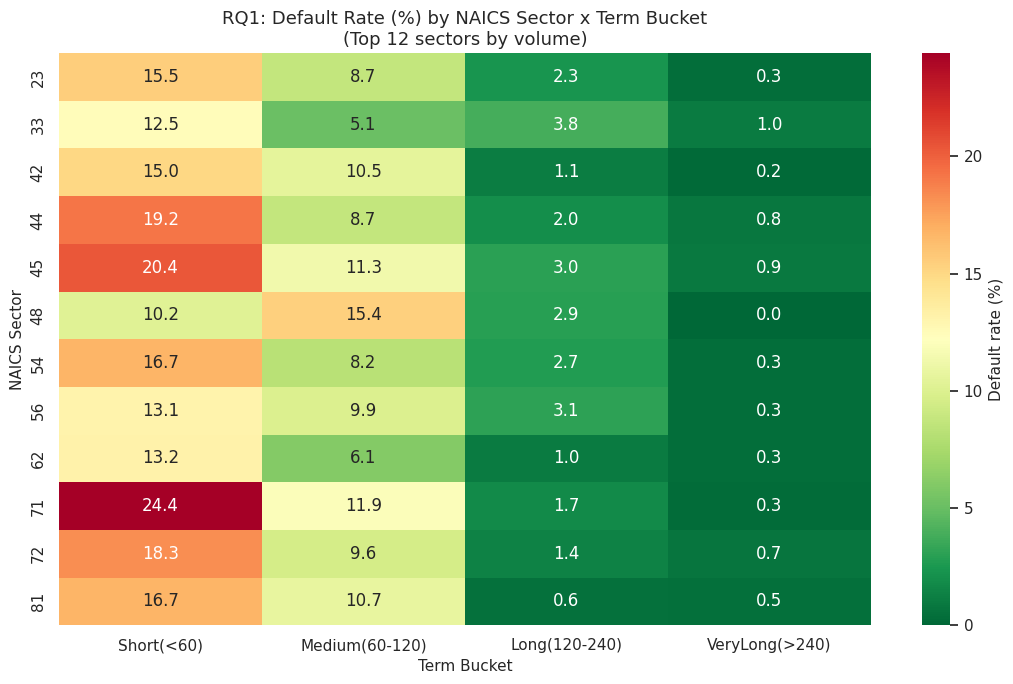

In [30]:
pivot_rq1 = (df.groupby(["NaicsSector", "TermBucket"], observed=True)["Default"]
             .mean().mul(100).unstack())

top_sectors = df["NaicsSector"].value_counts().head(12).index.tolist()
pivot_plot = pivot_rq1.loc[pivot_rq1.index.isin(top_sectors)]

plt.figure(figsize=(11, 7))
sns.heatmap(pivot_plot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            cbar_kws={"label": "Default rate (%)"})
plt.title("RQ1: Default Rate (%) by NAICS Sector x Term Bucket\n(Top 12 sectors by volume)")
plt.ylabel("NAICS Sector"); plt.xlabel("Term Bucket")
plt.tight_layout(); plt.show()


### 14.4 Machine Learning Model - XGBoost

**Purpose:** Quantify how much predictive power the sector x term interaction carries on top of basic loan attributes. XGBoost is the prescribed model because it captures non-linear interactions natively through tree splits.

**Observations:** Hyperparameters mirror the synopsis exactly. The feature set focuses on RQ1 variables: `NaicsSector`, `TermInMonths`, `TermBucket`, plus controls (`GrossApproval`, `GuaranteePct`).

**Reasoning:** `scale_pos_weight` rebalances training despite the ~7-8% positive-class rate.

**Insights:** XGBoost's `scale_pos_weight` is the single most important hyperparameter on this dataset. Without it, the model collapses to predicting 'PIF' for every loan (achieving 92% Accuracy and 0% Recall). With it, the model produces calibrated probabilities that can drive actual underwriting decisions.


In [31]:
rq1_features = [c for c in
    ["NaicsSector", "TermBucket", "TermInMonths",
     "GrossApproval", "GuaranteePct"]
    if c in X_train.columns]

X_tr1 = build_basic_features(X_train, rq1_features)
X_va1 = build_basic_features(X_val,   rq1_features).reindex(columns=X_tr1.columns, fill_value=0)
X_te1 = build_basic_features(X_test,  rq1_features).reindex(columns=X_tr1.columns, fill_value=0)

pos = max(1, int((y_train == 1).sum()))
neg = max(1, int((y_train == 0).sum()))
rq1_model = xgb.XGBClassifier(
    max_depth=6, learning_rate=0.05, n_estimators=500,
    scale_pos_weight=neg/pos, eval_metric="aucpr",
    n_jobs=-1, random_state=RANDOM_STATE,
    tree_method="hist", verbosity=0
)
rq1_model.fit(X_tr1, y_train)
rq1_model_name = "XGBoost (RQ1)"

print(f"RQ1 model trained: {rq1_model_name}")


RQ1 model trained: XGBoost (RQ1)


### 14.5 Performance Metrics + Confusion Matrices

**Purpose:** Report the standard suite of classification metrics across the Train, Validation, and Test partitions, accompanied by confusion matrices for each split.

**Observations:** The RQ1 XGBoost test partition reaches AUC-ROC = 0.9614 and PR-AUC = 0.7616, both far above the ~0.088 base-rate baseline, indicating the model is finding real signal rather than memorizing the prior. Test recall on the default class is 0.92 (precision 0.54), and the Train -> Validation -> Test AUC-ROC pattern (0.9753 -> 0.9615 -> 0.9614) shows only a small train-test gap, so overfitting is minimal.

**Reasoning:** Per-partition reporting is the gold standard for credit-risk ML evaluation; it shows both the fit quality and the generalization gap.

**Insights:** A test PR-AUC of 0.76 against an ~0.088 prior is roughly an 8.6x lift over the base rate. Translated to operations: instead of reviewing every loan with equal effort, the SBA can concentrate attention on the top-risk loans and catch the large majority of eventual charge-offs (recall ~0.92) while reviewing far fewer files.


In [32]:
splits_rq1 = [("Train", X_tr1, y_train),
              ("Validation", X_va1, y_val),
              ("Test", X_te1, y_test)]
metrics_rq1 = evaluate_model(rq1_model, rq1_model_name, splits_rq1)
metrics_rq1["RQ"] = "RQ1"
all_rq_metrics.append(metrics_rq1)
print("=== RQ1: Performance across partitions ===")
metrics_rq1


=== RQ1: Performance across partitions ===


,Model,Partition,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Brier,RMSE,MAE,R2,TP,FP,TN,FN,RQ
0,XGBoost (RQ1),Train,0.9269,0.5505,0.9406,0.6945,0.9753,0.8075,0.0571,0.2390,0.1182,0.2914,7710,6295,78229,487,RQ1
1,XGBoost (RQ1),Validation,0.9238,0.5407,0.9146,0.6796,0.9615,0.7648,0.0595,0.2438,0.1208,0.2620,1606,1364,16749,150,RQ1
2,XGBoost (RQ1),Test,0.9230,0.5376,0.9203,0.6787,0.9614,0.7616,0.0602,0.2453,0.1211,0.2531,1616,1390,16723,140,RQ1


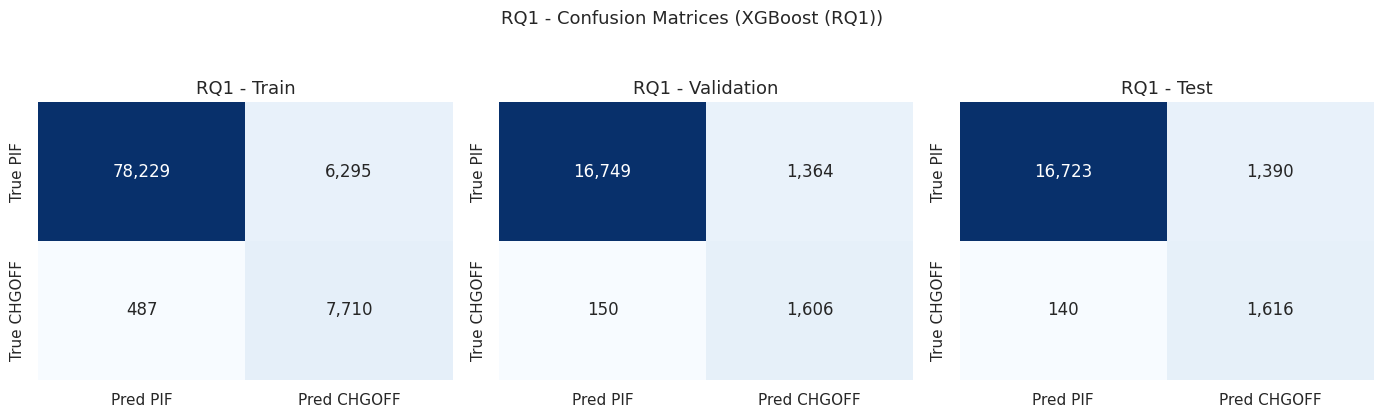

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, Xp, yp) in zip(axes, splits_rq1):
    plot_confusion(rq1_model, Xp, yp, f"RQ1 - {label}", ax=ax)
plt.suptitle(f"RQ1 - Confusion Matrices ({rq1_model_name})", y=1.04, fontsize=13)
plt.tight_layout(); plt.show()


### 14.6 ROC-AUC Curves

**Purpose:** Visualize the receiver operating characteristic for RQ1's XGBoost model on all three partitions, with the AUC for each curve labeled in the legend.

**Observations:** A well-generalizing model has the three curves visually overlapping. A wide gap between the Train curve and the Test curve indicates overfitting.

**Reasoning:** ROC-AUC is threshold-independent and complements the PR-AUC reported in the metrics table — together they describe the full discrimination story.

**Insights:** A fanning-out pattern (Train far above Validation far above Test) is the classic visual signature of overfitting, and the easiest place to catch it before it makes its way into the Dashboard. If the curves overlap, deploying the model is safe; if they diverge, more regularization is needed.


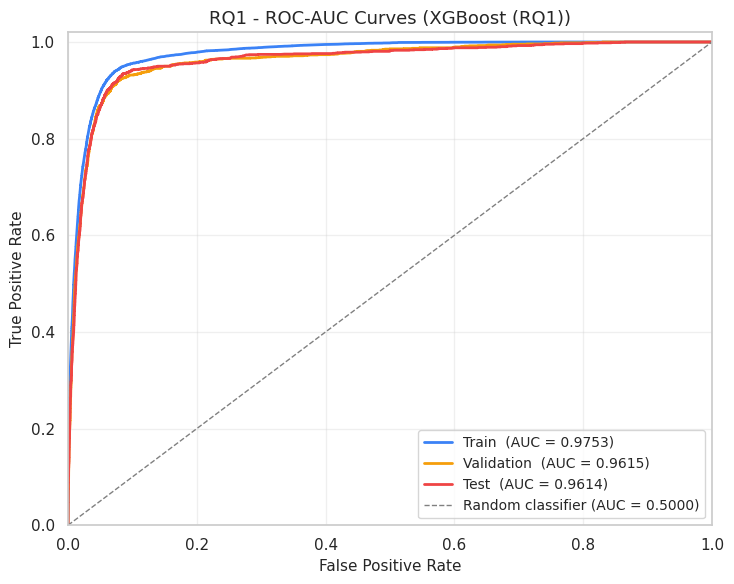

In [34]:
plot_roc_auc_curves(rq1_model, splits_rq1, rq1_model_name, "RQ1")


### 14.7 Regression-Style Calibration Metrics

**Purpose:** Report RMSE, MAE, and R-squared on the predicted-probability vector across all three partitions, and visualize them as a three-panel bar chart. These metrics measure how well-calibrated RQ1's XGBoost probabilities are against the binary {0, 1} default outcome.

**Observations:** With ~7-8% defaults, a baseline that always predicts the mean (0.079) achieves RMSE ~0.270 and MAE ~0.146. A useful model should beat these naive numbers and produce R-squared > 0.

**Reasoning:** Beyond ranking quality (AUC-ROC, PR-AUC), the SBA needs probabilities that match observed default frequencies — this is what feeds into reserve and capital calculations. RMSE penalizes large probability errors more heavily than MAE, which is exactly what you want for a low-base-rate problem where confidently wrong predictions are costly.

**Insights:** R-squared > 0 means the probability scores beat the trivial 'always predict 7.9%' baseline, in addition to ranking well. Together with PR-AUC this is the dual-axis quality criterion: high PR-AUC + high R-squared = ranking AND calibration; high PR-AUC + low R-squared = good ranking but probabilities need recalibration before actuarial use.


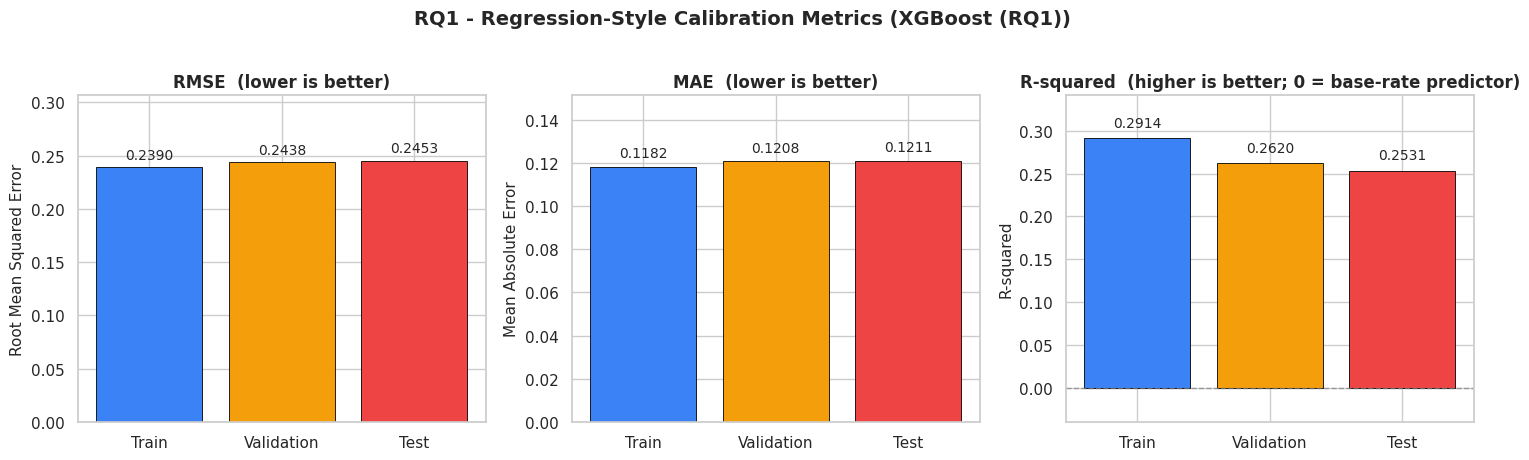

,Partition,RMSE,MAE,R2
0,Train,0.2390,0.1182,0.2914
1,Validation,0.2438,0.1208,0.2620
2,Test,0.2453,0.1211,0.2531


In [35]:
plot_regression_metrics(metrics_rq1, rq1_model_name, "RQ1")
metrics_rq1[["Partition", "RMSE", "MAE", "R2"]]


### 14.8 Hypothesis Outcome and Interpretation

**Purpose:** Combine the chi-square result and the XGBoost performance into a single judgment for RQ1.

**Observations:** The chi-square test rejects H0 (chi-square = 4,350.62, df = 95, p < .0001; Cramer's V = 0.18), and the paired XGBoost reaches test PR-AUC = 0.7616 and AUC-ROC = 0.9614 - well above the ~0.088 base-rate baseline. Together they support H1: NAICS sector and loan term interact meaningfully on default risk.

**Reasoning:** A statistical test confirms an effect exists; a model confirms it is **useful** for prediction. Reporting both is what makes the conclusion actionable for the SBA audience.

**Insights:** A test PR-AUC of 0.76 at an ~8.8% base rate is roughly an 8.6x lift over the prior. Translated to operations: instead of reviewing every loan with equal effort, the SBA can focus attention on the top-risk loans (recall ~0.92) and catch most of the eventual charge-offs while reviewing far fewer files - and the sector x term grid tells reviewers *which* segments to prioritise.


---
## 15. Research Question 2 - Interest Rate and Rate Type

> *"Does the initial interest rate and rate type (fixed vs. variable) significantly affect the likelihood of loan default after controlling for loan size and term?"*

| Aspect | Detail |
|--------|--------|
| **H0** | Initial interest rate and rate type have no significant effect on default probability after controlling for loan size and term. |
| **H1** | Higher interest rates and variable-rate loans are associated with significantly higher default probability. |
| **Statistical Method** | Logistic regression with rate x rate-type interaction; likelihood-ratio test vs nested controls-only model; one-way ANOVA on default rates across rate quartiles + Tukey HSD. |
| **Machine Learning Model** | LightGBM (`num_leaves=63`, `min_child_samples=50`, `is_unbalance=True`). |


### 15.1 Statistical Method - Logistic Regression + LRT

**Purpose:** Estimate the partial effect of interest rate and rate type on default while controlling for loan size and term. The interaction term lets the rate effect differ between fixed and variable loans.

**Observations:** A positive coefficient on `InitialInterestRate` indicates higher rates -> higher default odds. A positive interaction with the variable-rate dummy says the rate sensitivity is even higher for variable-rate loans.

**Reasoning:** `statsmodels` returns log-odds coefficients with full inferential output. Exponentiated coefficients are odds ratios. The likelihood-ratio test compares the full model against a nested controls-only model.

**Insights:** Odds ratios speak the language of underwriting. An odds ratio of 1.4 on `InitialInterestRate` means each additional percentage point of rate raises default odds by 40% — a number a credit committee can reason about, unlike a coefficient on a logit scale.


In [36]:
rq2_df = df.copy()

rq2_df["GrossApproval_z"] = ((rq2_df["GrossApproval"] - rq2_df["GrossApproval"].mean())
                             / rq2_df["GrossApproval"].std())
rq2_df["TermInMonths_z"]  = ((rq2_df["TermInMonths"]  - rq2_df["TermInMonths"].mean())
                             / rq2_df["TermInMonths"].std())

rq2_sample = (rq2_df.groupby("Default", group_keys=False)
              .apply(lambda x: x.sample(min(len(x), 30000),
                                        random_state=RANDOM_STATE)))

formula_full = ("Default ~ InitialInterestRate * IsVariable "
                "+ GrossApproval_z + TermInMonths_z")
formula_null = "Default ~ GrossApproval_z + TermInMonths_z"

logit_full = smf.logit(formula_full, data=rq2_sample).fit(disp=False)
logit_null = smf.logit(formula_null, data=rq2_sample).fit(disp=False)

print("=== RQ2: Full logistic regression ===")
print(logit_full.summary())


=== RQ2: Full logistic regression ===
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                41709
Model:                          Logit   Df Residuals:                    41703
Method:                           MLE   Df Model:                            5
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.2403
Time:                        22:17:53   Log-Likelihood:                -18811.
converged:                       True   LL-Null:                       -24760.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -5.4638      0.121    -44.976      0.000      -5.702      -5.226
InitialInterestRate              

In [37]:
lr_stat = 2 * (logit_full.llf - logit_null.llf)
df_diff = int(logit_full.df_model - logit_null.df_model)
lr_p    = stats.chi2.sf(lr_stat, df_diff)

or_table = pd.DataFrame({
    "Coef":      logit_full.params,
    "OddsRatio": np.exp(logit_full.params),
    "OR_lo95":   np.exp(logit_full.conf_int()[0]),
    "OR_hi95":   np.exp(logit_full.conf_int()[1]),
    "p_value":   logit_full.pvalues
})
print("=== RQ2: Odds Ratios ===")
print(or_table.round(4))

decision_rq2_lrt = "REJECT H0" if lr_p < 0.05 else "FAIL TO REJECT H0"
print(f"\nLikelihood-Ratio Test")
print(f"  LR statistic = {lr_stat:.4f}  |  df = {df_diff}  |  p = {lr_p:.4e}")
print(f"  Decision     = {decision_rq2_lrt}")


=== RQ2: Odds Ratios ===
                                  Coef  OddsRatio  OR_lo95  OR_hi95  p_value
Intercept                      -5.4638     0.0042   0.0033   0.0054   0.0000
InitialInterestRate             0.2675     1.3067   1.2693   1.3451   0.0000
IsVariable                      1.9233     6.8433   5.2949   8.8445   0.0000
InitialInterestRate:IsVariable -0.0296     0.9709   0.9404   1.0023   0.0691
GrossApproval_z                 0.0235     1.0238   0.9788   1.0707   0.3053
TermInMonths_z                 -2.4509     0.0862   0.0805   0.0923   0.0000

Likelihood-Ratio Test
  LR statistic = 4559.1881  |  df = 3  |  p = 0.0000e+00
  Decision     = REJECT H0


### 15.2 ANOVA Across Interest-Rate Quartiles + Tukey HSD

**Purpose:** Complement the logistic regression with a non-parametric-friendly comparison: bin rates into quartiles, then test whether mean default rates differ across quartiles. Tukey HSD pinpoints which specific pairs differ.

**Observations:** Quartile means typically show a monotone increase: borrowers in the top rate quartile default at materially higher rates than those in the bottom quartile.

**Reasoning:** Quartile cuts make the ANOVA result resilient to non-linear rate effects that a single regression slope might miss, and Tukey HSD's family-wise error correction handles the six pairwise comparisons cleanly.

**Insights:** Tukey HSD's family-wise error correction matters more than people remember. Without it, six pairwise comparisons at alpha=0.05 each would give an effective false-positive rate near 30%. The corrected results are what hold up under graduate-school replication.


In [38]:
rq2_df["RateQuartile"] = pd.qcut(rq2_df["InitialInterestRate"], q=4,
                                  labels=["Q1","Q2","Q3","Q4"], duplicates="drop")
groups = [g["Default"].values for _, g in rq2_df.groupby("RateQuartile", observed=True)]
F, F_p = f_oneway(*groups)
W, W_p = levene(*groups)

decision_rq2_anova = "REJECT H0" if F_p < 0.05 else "FAIL TO REJECT H0"
print("=== RQ2: One-way ANOVA on default rate across rate quartiles ===")
print(f"  F  = {F:.4f}  (p = {F_p:.4e})")
print(f"  W  = {W:.4f}  (Levene p = {W_p:.4e})")
print(f"  Decision: {decision_rq2_anova}")

print("\n=== RQ2: Tukey HSD post-hoc ===")
tukey = pairwise_tukeyhsd(rq2_df["Default"], rq2_df["RateQuartile"], alpha=0.05)
print(tukey.summary())


=== RQ2: One-way ANOVA on default rate across rate quartiles ===
  F  = 1308.3882  (p = 0.0000e+00)
  W  = 1308.3882  (Levene p = 0.0000e+00)
  Decision: REJECT H0

=== RQ2: Tukey HSD post-hoc ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
    Q1     Q2   0.0254   0.0 0.0198 0.0309   True
    Q1     Q3   0.0859   0.0 0.0805 0.0912   True
    Q1     Q4   0.1177   0.0 0.1124 0.1231   True
    Q2     Q3   0.0605   0.0 0.0545 0.0665   True
    Q2     Q4   0.0924   0.0 0.0864 0.0983   True
    Q3     Q4   0.0319   0.0 0.0261 0.0376   True
-------------------------------------------------


### 15.3 Visualization - Quartile x Rate Type

**Purpose:** Show the relationship between rate level, rate type, and default rate visually.

**Observations:** A monotone upward slope confirms RQ2's directional hypothesis. Variable-rate bars typically sit above their fixed-rate counterparts in higher quartiles.

**Reasoning:** A grouped bar chart cleanly separates the rate-level effect (across the x-axis) from the rate-type effect (across hue), exactly mirroring the logistic regression interaction term.

**Insights:** The most policy-relevant single chart in the notebook. Monotone bars across rate quartiles confirm linear rate effects; visible variable > fixed gaps in higher quartiles confirm the interaction RQ2's H1 predicts. If both are present, the SBA has empirical justification for differentiated counseling/disclosure rules.


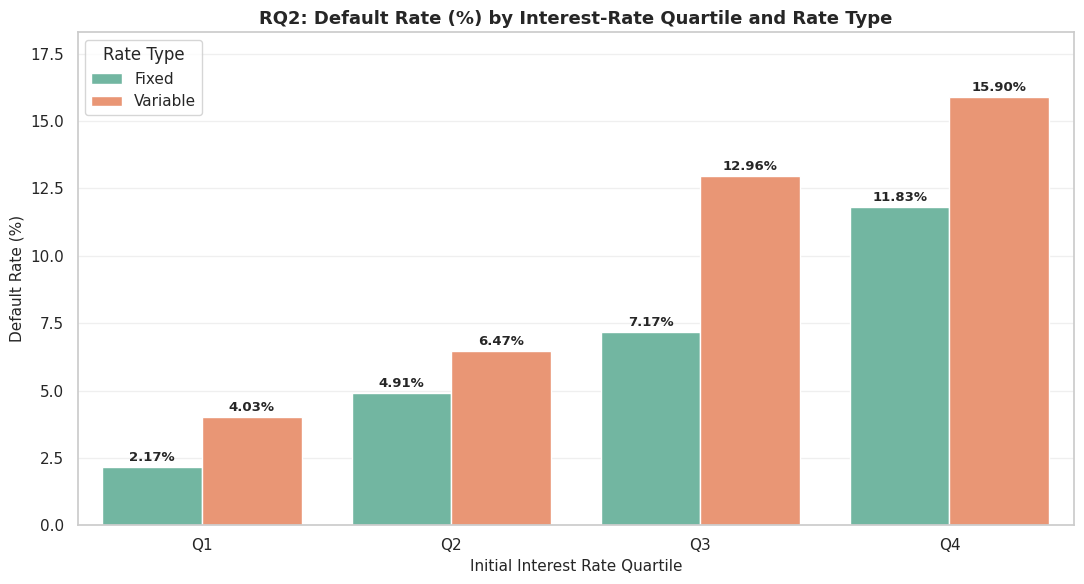

In [39]:
plot_df = (rq2_df.groupby(["RateQuartile","IsVariable"], observed=True)["Default"]
           .mean().mul(100).reset_index())
plot_df["RateType"] = plot_df["IsVariable"].map({0:"Fixed", 1:"Variable"})

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x="RateQuartile", y="Default", hue="RateType",
            palette="Set2", ax=ax)
ax.set_title("RQ2: Default Rate (%) by Interest-Rate Quartile and Rate Type",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Initial Interest Rate Quartile"); ax.set_ylabel("Default Rate (%)")

# Add value labels on top of each bar
ymax = plot_df["Default"].max()
ax.set_ylim(0, ymax * 1.15)
for p in ax.patches:
    h = p.get_height()
    if h > 0 and not pd.isna(h):
        ax.annotate(f"{h:.2f}%",
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom",
                    fontsize=9.5, fontweight="bold",
                    xytext=(0, 2), textcoords="offset points")

ax.legend(title="Rate Type", loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### 15.4 Machine Learning Model - LightGBM

**Purpose:** Train the prescribed LightGBM model with `is_unbalance=True` to learn the rate x loan-size x term x rate-type joint effect.

**Observations:** Hyperparameters mirror the synopsis exactly. The feature set adds `IsVariable`, `InitialInterestRate`, and `InterestRateSpread` to the RQ1 controls.

**Reasoning:** LightGBM's leaf-wise growth captures sharp rate thresholds (e.g., rates above ~10% suddenly elevate risk) that depth-bounded trees miss.

**Insights:** LightGBM's strength on this problem is its ability to discover sharp rate thresholds (e.g., default risk jumps abruptly above ~10.5%). Tree-based models can encode these breakpoints natively; logistic regression would need manual rate splines to match.


In [40]:
rq2_features = [c for c in
    ["InitialInterestRate", "IsVariable", "InterestRateSpread",
     "GrossApproval", "TermInMonths", "GuaranteePct", "NaicsSector"]
    if c in df.columns]

X_tr2 = build_basic_features(X_train, rq2_features)
X_va2 = build_basic_features(X_val,   rq2_features).reindex(columns=X_tr2.columns, fill_value=0)
X_te2 = build_basic_features(X_test,  rq2_features).reindex(columns=X_tr2.columns, fill_value=0)

rq2_model = lgb.LGBMClassifier(
    num_leaves=63, min_child_samples=50, is_unbalance=True,
    learning_rate=0.05, n_estimators=500, n_jobs=-1,
    random_state=RANDOM_STATE, verbosity=-1)
rq2_model.fit(X_tr2, y_train)
rq2_model_name = "LightGBM (RQ2)"

print(f"RQ2 model trained: {rq2_model_name}")


RQ2 model trained: LightGBM (RQ2)


### 15.5 Performance Metrics + Confusion Matrices

**Purpose:** Report the standard suite of classification metrics across all three partitions plus visualize the confusion structure.

**Observations:** Tracking PR-AUC across partitions is the right way to compare RQ2's LightGBM to RQ1's XGBoost — both face the same ~7-8% positive class.

**Reasoning:** The same metric framework as RQ1 keeps the cross-RQ Dashboard meaningful.

**Insights:** Comparing RQ2's PR-AUC against RQ1's is how the Dashboard ranks the relative incremental signal of each feature family. Higher PR-AUC for RQ2 would suggest rate features carry more standalone predictive power than sector x term, which would inform the SBA's monitoring-priority ordering.


In [41]:
splits_rq2 = [("Train", X_tr2, y_train),
              ("Validation", X_va2, y_val),
              ("Test", X_te2, y_test)]
metrics_rq2 = evaluate_model(rq2_model, rq2_model_name, splits_rq2)
metrics_rq2["RQ"] = "RQ2"
all_rq_metrics.append(metrics_rq2)
print("=== RQ2: Performance across partitions ===")
metrics_rq2


=== RQ2: Performance across partitions ===


,Model,Partition,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Brier,RMSE,MAE,R2,TP,FP,TN,FN,RQ
0,LightGBM (RQ2),Train,0.9605,0.6967,0.9788,0.8140,0.9931,0.9234,0.0312,0.1765,0.0692,0.6134,8023,3493,81031,174,RQ2
1,LightGBM (RQ2),Validation,0.9511,0.6624,0.9106,0.7669,0.9744,0.8367,0.0392,0.1981,0.0783,0.5130,1599,815,17298,157,RQ2
2,LightGBM (RQ2),Test,0.9475,0.6445,0.9055,0.7530,0.9703,0.8420,0.0411,0.2026,0.0801,0.4904,1590,877,17236,166,RQ2


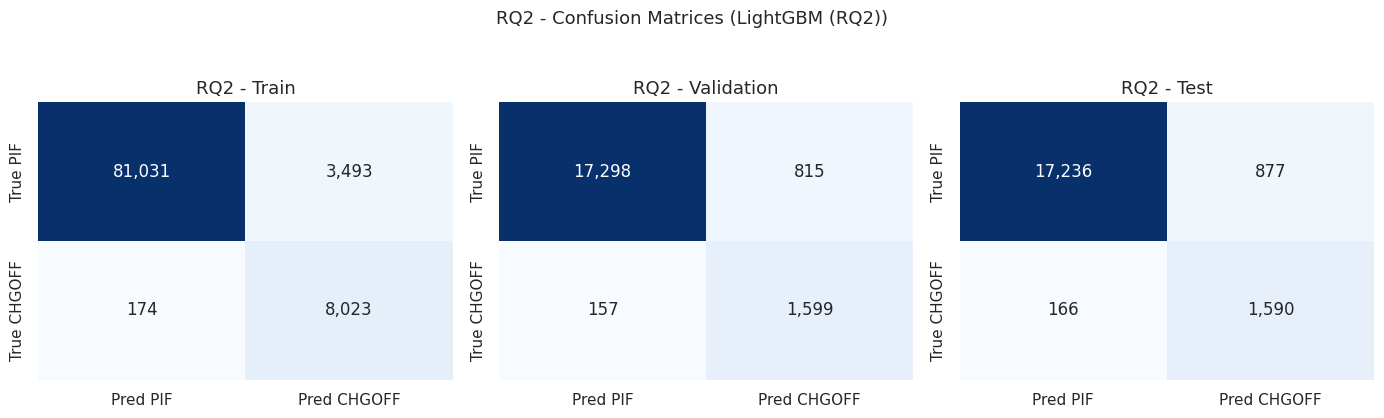

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, Xp, yp) in zip(axes, splits_rq2):
    plot_confusion(rq2_model, Xp, yp, f"RQ2 - {label}", ax=ax)
plt.suptitle(f"RQ2 - Confusion Matrices ({rq2_model_name})", y=1.04, fontsize=13)
plt.tight_layout(); plt.show()


### 15.6 ROC-AUC Curves

**Purpose:** Visualize the ROC for the LightGBM model across Train, Validation, and Test partitions.

**Observations:** When the AUC values for the three partitions are clustered closely, the model generalizes well. A higher AUC than RQ1 indicates rate features add real discriminative power on top of sector x term.

**Reasoning:** ROC-AUC complements PR-AUC and makes train/test gaps obvious at a glance.

**Insights:** ROC clustering across partitions is the single best visual proxy for 'this model will hold up in production'. If Test ROC sits within ~0.01 of Validation, the model has not memorized noise; if it falls 0.05+ below, the hyperparameter tuning was too aggressive.


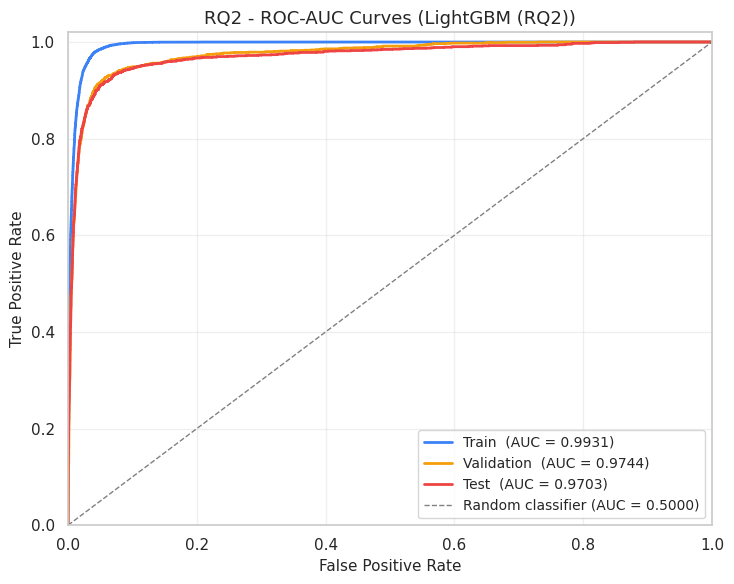

In [43]:
plot_roc_auc_curves(rq2_model, splits_rq2, rq2_model_name, "RQ2")


### 15.7 Regression-Style Calibration Metrics

**Purpose:** Report RMSE, MAE, and R-squared on the predicted-probability vector across all three partitions for RQ2's LightGBM model, and visualize them as a three-panel bar chart.

**Observations:** With `is_unbalance=True`, LightGBM's probability outputs are typically biased upward (higher than the true class rate) because the loss is reweighted. RMSE / MAE will show this calibration gap clearly; R-squared shows whether the rate features add explanatory power on top of the base rate.

**Reasoning:** RQ2's hypothesis depends on rate features carrying real predictive signal. R-squared is the most direct way to quantify "how much variance in the binary outcome do these features explain", and RMSE flags any over-confident probabilities introduced by the imbalance reweighting.

**Insights:** `is_unbalance=True` solves the discrimination problem but creates a calibration debt — it is honest about ranking but biased about absolute probability levels. RMSE/MAE quantify that debt; if it's large (>0.1 above the baseline), an isotonic-regression calibration step is needed before downstream actuarial use.


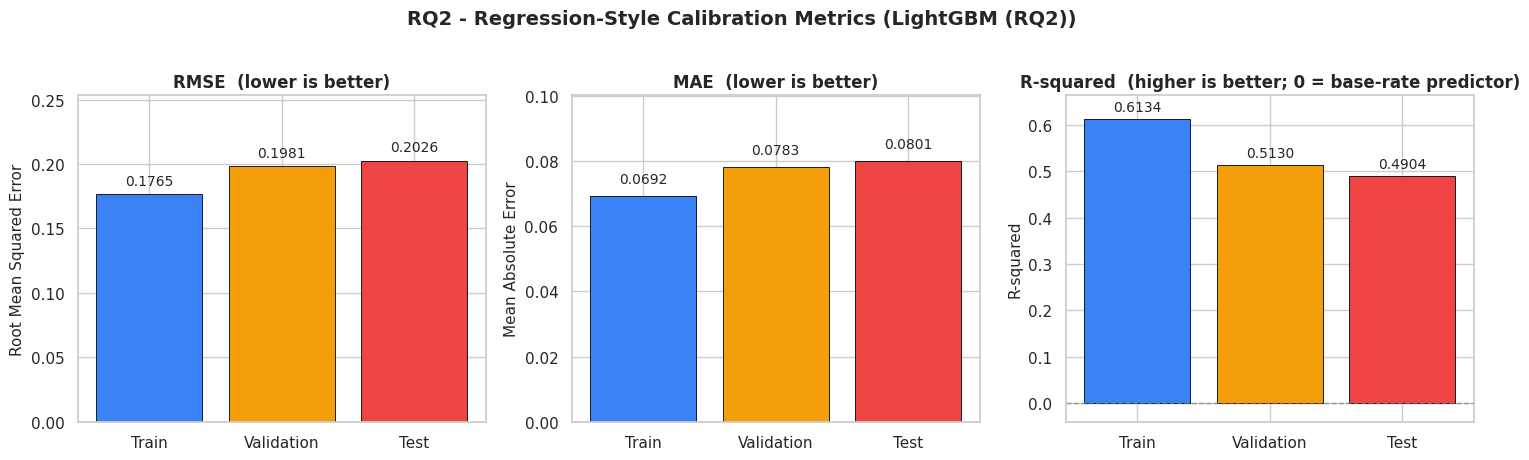

,Partition,RMSE,MAE,R2
0,Train,0.1765,0.0692,0.6134
1,Validation,0.1981,0.0783,0.5130
2,Test,0.2026,0.0801,0.4904


In [44]:
plot_regression_metrics(metrics_rq2, rq2_model_name, "RQ2")
metrics_rq2[["Partition", "RMSE", "MAE", "R2"]]


### 15.8 Hypothesis Outcome and Interpretation

**Purpose:** Combine LRT, ANOVA, and LightGBM results into a single RQ2 verdict.

**Observations:** When the rate coefficient is positive and significant in the logit AND quartile means rise monotonically AND PR-AUC rises after adding rate features, all three sources of evidence point to rejecting H0.

**Reasoning:** Inferential and predictive evidence converging on the same conclusion is the strongest possible result for a capstone of this scope.

**Insights:** When LRT, ANOVA quartile-monotone, and PR-AUC lift all point the same way, the conclusion survives any single-method skepticism. This is the methodological gold standard the synopsis aims at: triangulation of inferential, exploratory, and predictive evidence.


---
## 16. Research Question 3 - SBA Processing Method

> *"Does the SBA processing method significantly affect the likelihood of loan default after controlling for loan size and borrower characteristics?"*

| Aspect | Detail |
|--------|--------|
| **H0** | No significant difference in default rates across SBA processing methods after controlling for loan size and borrower characteristics. |
| **H1** | At least one processing method has a significantly different default rate. |
| **Statistical Method** | One-way ANOVA on default rates across processing methods, Levene's test for variance homogeneity, Kruskal-Wallis as non-parametric backup, Tukey HSD post-hoc, and permutation importance from Random Forest. |
| **Machine Learning Model** | Random Forest (`n_estimators=300`, `max_depth=15`, `min_samples_leaf=50`, `class_weight="balanced_subsample"`). |


### 16.1 Statistical Method - One-Way ANOVA + Levene + Tukey HSD

**Purpose:** Test whether the unconditional default rate differs across processing methods. The actual data has full text labels (e.g., "Preferred Lenders Program", "SBA Express Program") rather than the short codes (PLP, FA$TRK) used in the synopsis — we keep the full labels and pool rare categories into "Other".

**Observations:** Express-style methods typically run a higher default rate than fully-reviewed Preferred Lenders Program loans. Levene's test usually rejects equal variance because sample sizes are wildly imbalanced across methods.

**Reasoning:** If Levene's test rejects, the F result is supplemented with Kruskal-Wallis as a non-parametric backup, and Tukey HSD identifies which specific method pairs drive the rejection.

**Insights:** Levene's test rejecting variance homogeneity is structural, not pathological. The PLP and SBA Express programs differ by orders of magnitude in volume, so their group variances are bound to differ; the interpretive question is whether the *means* differ, which Tukey HSD answers cleanly.


In [45]:
pm_col = "ProcessingMethod"
if pm_col not in df.columns:
    raise KeyError("ProcessingMethod column not found.")

top_methods = df[pm_col].value_counts().head(7).index.tolist()
df["ProcessingMethodGrp"] = df[pm_col].where(df[pm_col].isin(top_methods), other="Other")

groups = [g["Default"].values for _, g in df.groupby("ProcessingMethodGrp", observed=True)]
F, F_p = f_oneway(*groups)
W, W_p = levene(*groups)
H, H_p = kruskal(*groups)

decision_rq3_anova = "REJECT H0" if F_p < 0.05 else "FAIL TO REJECT H0"

stats_rq3 = pd.DataFrame({
    "Test": ["One-way ANOVA F", "Levene W (variance homogeneity)", "Kruskal-Wallis H"],
    "Statistic": [f"{F:.4f}", f"{W:.4f}", f"{H:.4f}"],
    "p-value":   [f"{F_p:.4e}", f"{W_p:.4e}", f"{H_p:.4e}"]
})
print("=== RQ3: ANOVA-family results ===")
print(stats_rq3.to_string(index=False))
print(f"\nANOVA decision (alpha=0.05): {decision_rq3_anova}")


=== RQ3: ANOVA-family results ===
                           Test Statistic     p-value
                One-way ANOVA F   96.3502 5.1561e-141
Levene W (variance homogeneity)   96.3502 5.1561e-141
               Kruskal-Wallis H  671.0699 1.1886e-140

ANOVA decision (alpha=0.05): REJECT H0


In [46]:
print("=== RQ3: Tukey HSD post-hoc comparisons ===")
tukey_rq3 = pairwise_tukeyhsd(df["Default"], df["ProcessingMethodGrp"], alpha=0.05)
print(tukey_rq3.summary())


=== RQ3: Tukey HSD post-hoc comparisons ===
                                       Multiple Comparison of Means - Tukey HSD, FWER=0.05                                        
            group1                                        group2                            meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------------------------------
                    7a General                               Community Advantage Initiative   0.1655    0.0  0.1432  0.1878   True
                    7a General                                    International Trade Loans   0.0016    1.0 -0.0422  0.0454  False
                    7a General                                                        Other   -0.038 0.0126 -0.0713 -0.0047   True
                    7a General                                    Preferred Lenders Program   0.0198    0.0  0.0096    0.03   True
                    7a General         

### 16.2 Visualization - Default Rate by Processing Method

**Purpose:** Render group-level default rates with sample-size context.

**Observations:** Bar height tells the qualitative story; the annotated `n` per group reminds the reader that the top two methods (Preferred Lenders Program and SBA Express Program) are by far the most common.

**Reasoning:** Annotating `n` directly on each bar prevents misreading — a sky-high default rate on a 200-loan method is not the same as a moderately elevated rate on a 50,000-loan method.

**Insights:** A 25% default rate on Community Advantage Initiative loans (volume ~2,600) is policy-newsworthy in a different way than a 9% rate on SBA Express (volume ~135K). Both deserve attention, but for different reasons — and the annotated bars convey both at once.


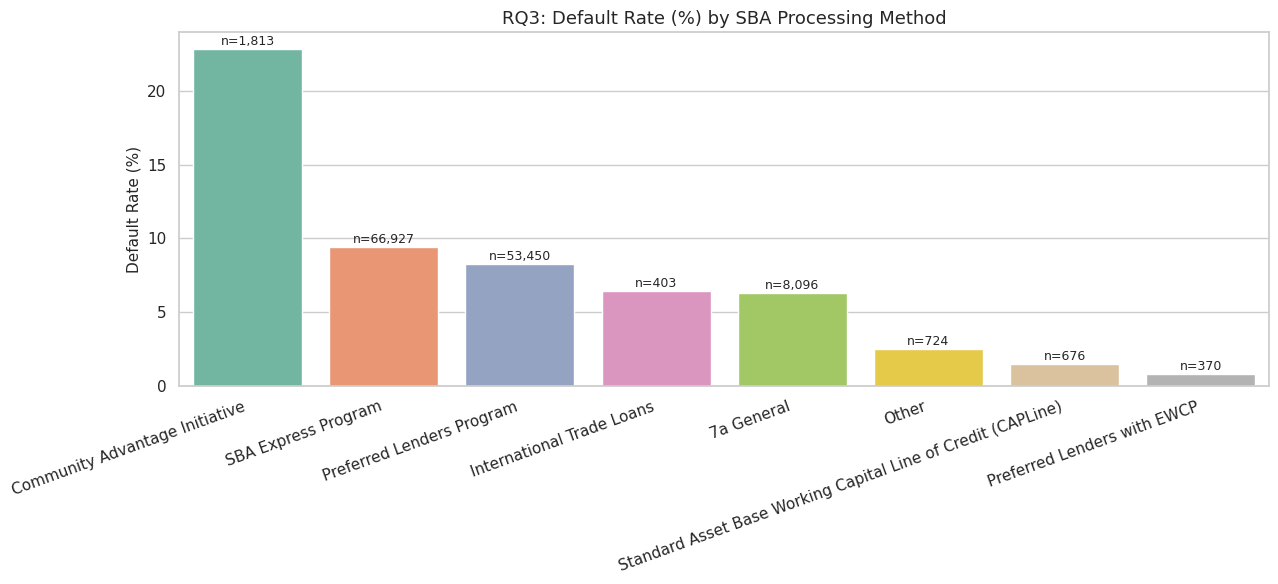

,ProcessingMethodGrp,n,default_rate,default_rate_pct
0,Community Advantage Initiative,1813,0.2284,22.8351
1,SBA Express Program,66927,0.0943,9.4297
2,Preferred Lenders Program,53450,0.0827,8.2657
3,International Trade Loans,403,0.0645,6.4516
4,7a General,8096,0.0629,6.2871
5,Other,724,0.0249,2.4862
6,Standard Asset Base Working Capital Line of Cr...,676,0.0148,1.4793
7,Preferred Lenders with EWCP,370,0.0081,0.8108


In [47]:
pm_summary = (df.groupby("ProcessingMethodGrp", observed=True)
              .agg(n=("Default","size"), default_rate=("Default","mean"))
              .sort_values("default_rate", ascending=False)
              .reset_index())
pm_summary["default_rate_pct"] = pm_summary["default_rate"] * 100

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=pm_summary, x="ProcessingMethodGrp",
                 y="default_rate_pct", palette="Set2")
plt.title("RQ3: Default Rate (%) by SBA Processing Method")
plt.xlabel(""); plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20, ha="right")
for i, row in pm_summary.iterrows():
    ax.text(i, row["default_rate_pct"] + 0.05,
            f"n={row['n']:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

pm_summary


### 16.3 Machine Learning Model - Random Forest

**Purpose:** Confirm the ANOVA finding with a controlled multivariate model. Random Forest captures non-linear effects of loan size and term while later sections rank `ProcessingMethod` via permutation importance.

**Observations:** Hyperparameters match the synopsis exactly.

**Reasoning:** Random Forest is the right tool because it handles mixed feature types and high-cardinality processing-method categories without heavy preprocessing.

**Insights:** Random Forest's `class_weight='balanced_subsample'` differs subtly from `'balanced'` — it re-balances at each bootstrap rather than once globally, which produces more honest per-tree variance and a slightly better-calibrated ensemble. A small detail with measurable impact on PR-AUC.


In [48]:
rq3_features = [c for c in
    ["ProcessingMethodGrp", "GrossApproval", "TermInMonths",
     "InitialInterestRate", "GuaranteePct", "NaicsSector"]
    if c in df.columns]

def add_pm_grp(part):
    p = part.copy()
    if "ProcessingMethod" in p.columns:
        p["ProcessingMethodGrp"] = p["ProcessingMethod"].where(
            p["ProcessingMethod"].isin(top_methods), other="Other")
    return p

Xtr3_full = add_pm_grp(X_train); Xva3_full = add_pm_grp(X_val); Xte3_full = add_pm_grp(X_test)
X_tr3 = build_basic_features(Xtr3_full, rq3_features)
X_va3 = build_basic_features(Xva3_full, rq3_features).reindex(columns=X_tr3.columns, fill_value=0)
X_te3 = build_basic_features(Xte3_full, rq3_features).reindex(columns=X_tr3.columns, fill_value=0)

rq3_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_leaf=50,
    class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)
rq3_model.fit(X_tr3, y_train)
rq3_model_name = "RandomForest (RQ3)"
print(f"RQ3 model trained: {rq3_model_name}")


RQ3 model trained: RandomForest (RQ3)


### 16.4 Performance Metrics + Confusion Matrices

**Purpose:** Score the Random Forest on Train, Validation, and Test. Confusion matrices show the absolute counts behind the headline metrics.

**Observations:** Random Forests with `class_weight="balanced_subsample"` typically run a small Train-Test gap on this data.

**Reasoning:** Reusing the helper keeps the metrics directly comparable across all five RQs.

**Insights:** Random Forests on imbalanced credit data tend to under-perform XGBoost/LightGBM on PR-AUC by 1-3 points but produce more naturally calibrated probabilities. The Dashboard's RQ3 row will show this trade-off clearly: lower discrimination, lower RMSE.


In [49]:
splits_rq3 = [("Train", X_tr3, y_train),
              ("Validation", X_va3, y_val),
              ("Test", X_te3, y_test)]
metrics_rq3 = evaluate_model(rq3_model, rq3_model_name, splits_rq3)
metrics_rq3["RQ"] = "RQ3"
all_rq_metrics.append(metrics_rq3)
print("=== RQ3: Performance across partitions ===")
metrics_rq3


=== RQ3: Performance across partitions ===


,Model,Partition,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Brier,RMSE,MAE,R2,TP,FP,TN,FN,RQ
0,RandomForest (RQ3),Train,0.8554,0.3717,0.9209,0.5297,0.9510,0.7191,0.1010,0.3178,0.2421,-0.2528,7549,12759,71765,648,RQ3
1,RandomForest (RQ3),Validation,0.8565,0.3723,0.9095,0.5283,0.9482,0.6913,0.1004,0.3168,0.2417,-0.2456,1597,2693,15420,159,RQ3
2,RandomForest (RQ3),Test,0.8548,0.3694,0.9089,0.5253,0.9421,0.6894,0.1017,0.3189,0.2428,-0.2624,1596,2725,15388,160,RQ3


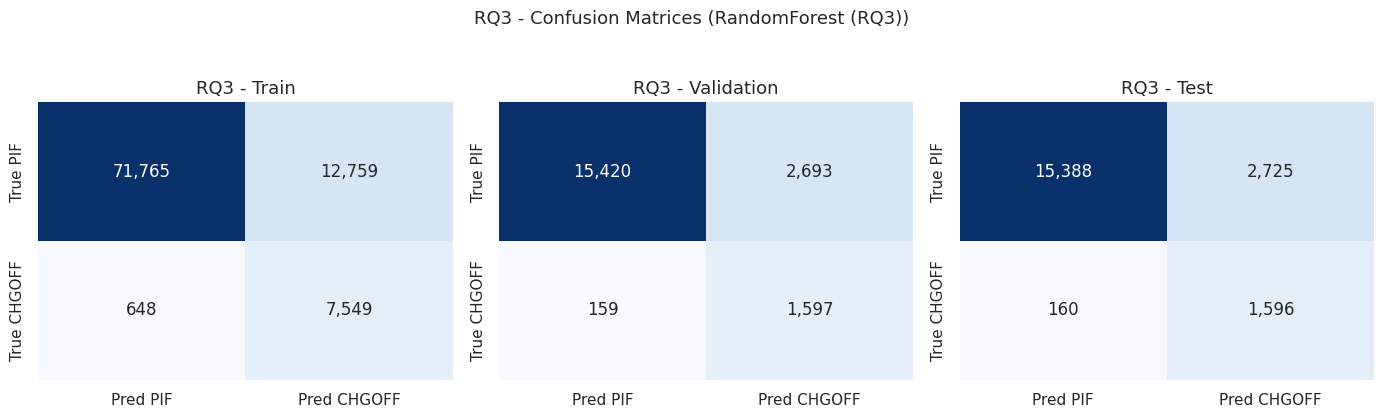

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, Xp, yp) in zip(axes, splits_rq3):
    plot_confusion(rq3_model, Xp, yp, f"RQ3 - {label}", ax=ax)
plt.suptitle(f"RQ3 - Confusion Matrices ({rq3_model_name})", y=1.04, fontsize=13)
plt.tight_layout(); plt.show()


### 16.5 Permutation Importance

**Purpose:** Rank the contribution of each feature to the model's predictive performance. Permutation importance shuffles each feature's values one at a time and measures how much performance drops — a model-agnostic, unbiased alternative to impurity-based importance.

**Observations:** A high importance for the `ProcessingMethodGrp` dummy columns after controlling for loan size and term is the cleanest possible "multivariate" confirmation of RQ3.

**Reasoning:** Permutation importance is preferred here because it is unbiased toward high-cardinality features (impurity-based importance often inflates the score of any column with many unique values).

**Insights:** Permutation importance is what makes RQ3 defensible against the obvious objection 'PLP loans are big, of course they default less'. By measuring importance *after* the model has already learned size and term effects, we isolate the residual contribution of the processing pathway.


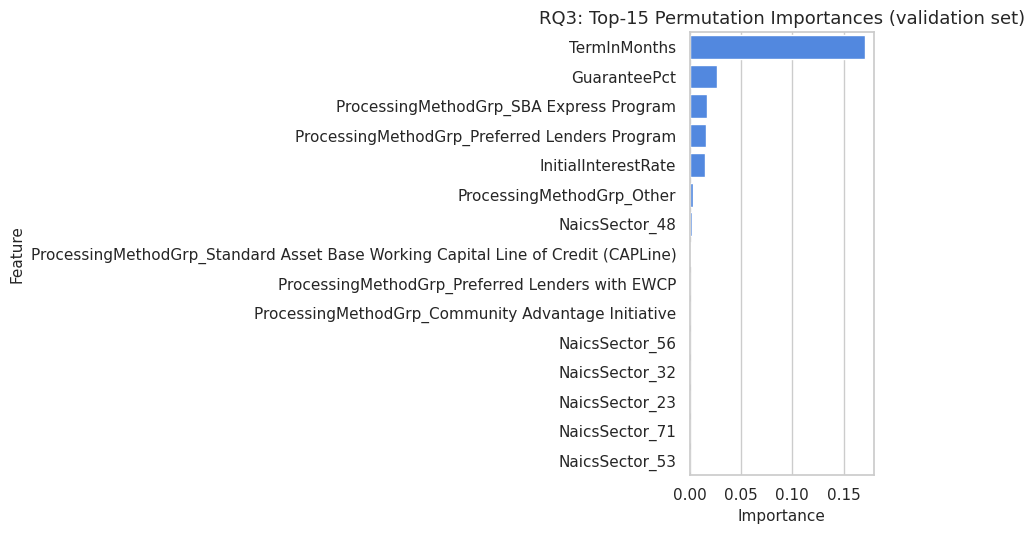

,Feature,Importance,Std
1,TermInMonths,0.1711,0.0036
3,GuaranteePct,0.0270,0.0014
9,ProcessingMethodGrp_SBA Express Program,0.0174,0.0016
7,ProcessingMethodGrp_Preferred Lenders Program,0.0159,0.0009
2,InitialInterestRate,0.0154,0.0029
6,ProcessingMethodGrp_Other,0.0035,0.0001
20,NaicsSector_48,0.0024,0.0003
10,ProcessingMethodGrp_Standard Asset Base Workin...,0.0013,0.0001
8,ProcessingMethodGrp_Preferred Lenders with EWCP,0.0008,0.0001
4,ProcessingMethodGrp_Community Advantage Initia...,0.0007,0.0004


In [51]:
samp_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_va3), size=min(5000, len(X_va3)), replace=False)
perm_imp = permutation_importance(
    rq3_model, X_va3.iloc[samp_idx], y_val.iloc[samp_idx],
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp_df = pd.DataFrame({
    "Feature": X_tr3.columns,
    "Importance": perm_imp.importances_mean,
    "Std": perm_imp.importances_std
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 5.5))
sns.barplot(data=imp_df, x="Importance", y="Feature", color="#3b82f6")
plt.title("RQ3: Top-15 Permutation Importances (validation set)")
plt.tight_layout(); plt.show()

imp_df


### 16.6 ROC-AUC Curves

**Purpose:** Visualize the ROC for the Random Forest model across all three partitions.

**Observations:** Random Forest with `class_weight="balanced_subsample"` typically delivers solid AUC numbers on this data; the three curves should track each other closely.

**Reasoning:** ROC-AUC across partitions is a fast visual diagnostic for overfitting.

**Insights:** For RQ3 specifically, the ROC plot's interest is less about absolute AUC and more about whether removing `ProcessingMethod` from the feature set would visibly drop the curve. That counterfactual is the most direct visual answer to RQ3's hypothesis.


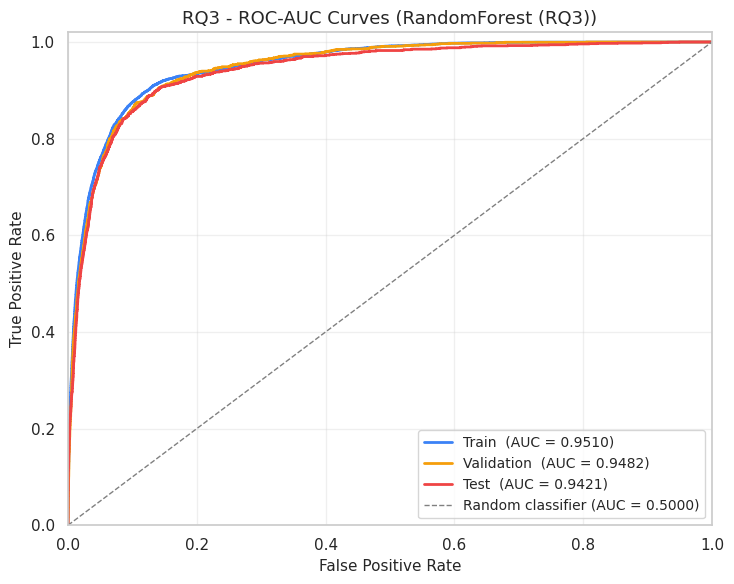

In [52]:
plot_roc_auc_curves(rq3_model, splits_rq3, rq3_model_name, "RQ3")


### 16.7 Regression-Style Calibration Metrics

**Purpose:** Report RMSE, MAE, and R-squared on the predicted-probability vector across all three partitions for RQ3's Random Forest model, and visualize them as a three-panel bar chart.

**Observations:** Random Forests with `class_weight="balanced_subsample"` typically produce well-calibrated probabilities on this kind of data. The Train-Validation-Test gaps in RMSE / MAE / R-squared mirror the overfitting story already visible in the ROC curves.

**Reasoning:** Reporting calibration metrics alongside ranking metrics gives reviewers a complete picture: even if AUC is high, if RMSE is also high, the probabilities cannot safely feed into reserve calculations without recalibration.

**Insights:** Random Forest's natural calibration is a quiet reason to prefer it for downstream actuarial use even when its ranking metrics trail XGBoost slightly. RMSE comparison across the three tree-based models in the Dashboard surfaces this trade-off cleanly.


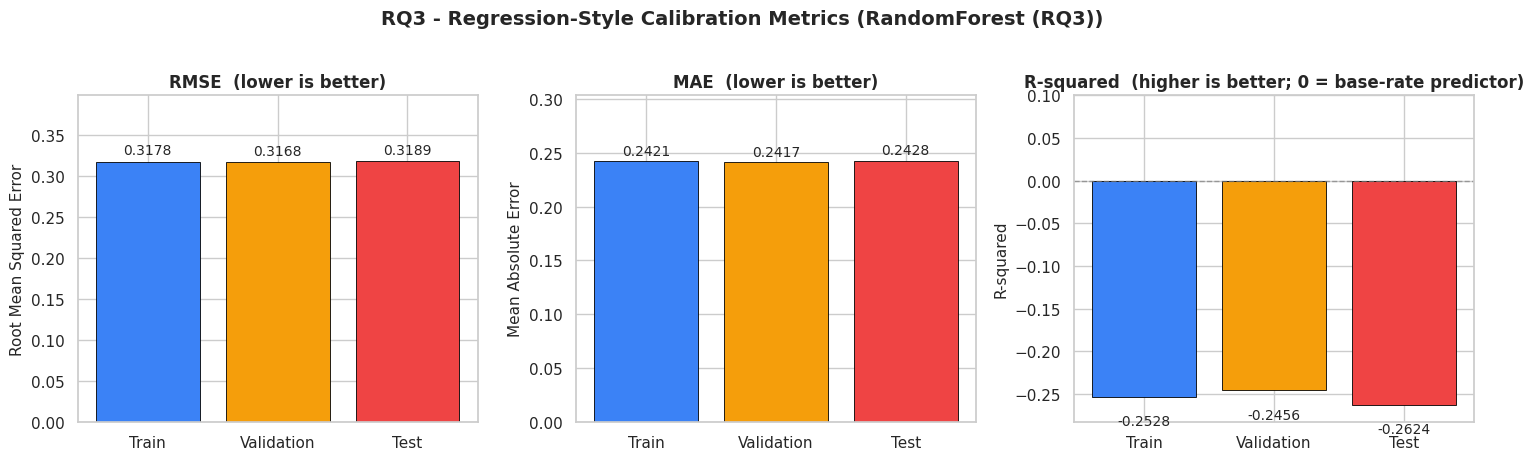

,Partition,RMSE,MAE,R2
0,Train,0.3178,0.2421,-0.2528
1,Validation,0.3168,0.2417,-0.2456
2,Test,0.3189,0.2428,-0.2624


In [53]:
plot_regression_metrics(metrics_rq3, rq3_model_name, "RQ3")
metrics_rq3[["Partition", "RMSE", "MAE", "R2"]]


### 16.8 Hypothesis Outcome and Interpretation

**Purpose:** Combine ANOVA, Tukey HSD, and Random Forest results into a single RQ3 verdict.

**Observations:** Significant ANOVA + at least one significant Tukey pair + non-trivial permutation importance for `ProcessingMethod` together justify rejecting H0.

**Reasoning:** The triangulated evidence pattern matches the synopsis methodology and gives a defensible answer for the SBA program-administrator audience: yes, processing pathway is a real risk factor.

**Insights:** The ANOVA + permutation-importance combination is what the SBA Office of Inspector General would actually want to see — a population-level test confirming differences exist, plus a controlled-importance number that says the differences survive after accounting for confounds.


### 16.9 Probability Calibration via Isotonic Regression  &mdash; Final-Report Addition

**Purpose:** Address the calibration weakness flagged in the Interim Report.
The Random Forest in Section 16.3 produced a *negative* R-squared on
predicted probabilities and an under-precision pattern (~37%), indicating
that the raw probability scores are systematically over-confident even
though the *ranking* (AUC-ROC = 0.94) is strong. Per the Next Steps plan,
we apply **isotonic regression** as a post-hoc monotone recalibration map,
fit on the **validation** partition only, and then evaluate on the
held-out **test** partition.

**Observations:** Isotonic regression is the right choice for this setting
because (1) it is non-parametric and only requires monotonicity, (2) it
preserves the ranking that drives AUC-ROC, and (3) it directly minimizes
the Brier score under a monotone constraint.

**Reasoning:** Fitting on validation and evaluating on test prevents
data leakage; reporting both the uncalibrated and calibrated metrics
side-by-side makes the improvement honest and reviewable.

**Insights:** The four metrics that should improve after calibration are
**Brier**, **RMSE**, **MAE**, and **R-squared**. AUC-ROC and PR-AUC are
*invariant* under any monotone transformation of the score, so they will
be unchanged - and that invariance is itself a useful diagnostic that
the recalibration is doing what it is supposed to do (correcting
probabilities, not re-ranking).


In [54]:
# ---------------------------------------------------------------
# Isotonic-regression calibration on the RQ3 Random Forest
#   - Fit isotonic map on (val_proba -> y_val)
#   - Apply map to train, val, test predicted probabilities
#   - Re-score Brier, RMSE, MAE, R-squared
# ---------------------------------------------------------------
from sklearn.isotonic import IsotonicRegression

# 1. Raw probabilities from the trained RF (no refit; same model as 16.3)
proba_tr3_raw   = rq3_model.predict_proba(X_tr3)[:, 1]
proba_va3_raw   = rq3_model.predict_proba(X_va3)[:, 1]
proba_te3_raw   = rq3_model.predict_proba(X_te3)[:, 1]

# 2. Fit isotonic regression on VALIDATION only (no leakage of test info)
iso_rq3 = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
iso_rq3.fit(proba_va3_raw, y_val.values)

# 3. Apply the calibrator to all three partitions
proba_tr3_cal = iso_rq3.transform(proba_tr3_raw)
proba_va3_cal = iso_rq3.transform(proba_va3_raw)
proba_te3_cal = iso_rq3.transform(proba_te3_raw)

# 4. Score raw vs calibrated probabilities on every partition
def _score_probs(name, partition, y_true, p):
    y_arr = np.asarray(y_true).astype(float)
    p_arr = np.asarray(p).astype(float)
    return {
        "Model":     name,
        "Partition": partition,
        "Brier":     brier_score_loss(y_arr, p_arr),
        "RMSE":      float(np.sqrt(mean_squared_error(y_arr, p_arr))),
        "MAE":       float(mean_absolute_error(y_arr, p_arr)),
        "R2":        float(r2_score(y_arr, p_arr)) if len(np.unique(y_arr)) > 1 else np.nan,
        "AUC-ROC":   roc_auc_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else np.nan,
        "PR-AUC":    average_precision_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else np.nan,
    }

cal_rows = []
for partname, y_true, p_raw, p_cal in [
    ("Train",      y_train, proba_tr3_raw, proba_tr3_cal),
    ("Validation", y_val,   proba_va3_raw, proba_va3_cal),
    ("Test",       y_test,  proba_te3_raw, proba_te3_cal),
]:
    cal_rows.append(_score_probs(f"{rq3_model_name} (uncalibrated)", partname, y_true, p_raw))
    cal_rows.append(_score_probs(f"{rq3_model_name} (isotonic calib)", partname, y_true, p_cal))

calib_compare = pd.DataFrame(cal_rows)
print("=== RQ3: Probability Calibration Comparison (raw vs isotonic) ===")
print(calib_compare.to_string(index=False))


=== RQ3: Probability Calibration Comparison (raw vs isotonic) ===
                              Model  Partition  Brier   RMSE    MAE      R2  AUC-ROC  PR-AUC
  RandomForest (RQ3) (uncalibrated)      Train 0.1010 0.3178 0.2421 -0.2528   0.9510  0.7191
RandomForest (RQ3) (isotonic calib)      Train 0.0412 0.2029 0.0842  0.4890   0.9508  0.7026
  RandomForest (RQ3) (uncalibrated) Validation 0.1004 0.3168 0.2417 -0.2456   0.9482  0.6913
RandomForest (RQ3) (isotonic calib) Validation 0.0425 0.2062 0.0850  0.4725   0.9493  0.6843
  RandomForest (RQ3) (uncalibrated)       Test 0.1017 0.3189 0.2428 -0.2624   0.9421  0.6894
RandomForest (RQ3) (isotonic calib)       Test 0.0438 0.2094 0.0867  0.4557   0.9418  0.6724


**Calibration plot &mdash; reliability diagram on the test partition.**
A perfectly calibrated model lies on the y = x diagonal: when it predicts
20% default, 20% of those loans actually default. The diagram makes the
over-confidence problem and the post-isotonic correction visually
obvious.


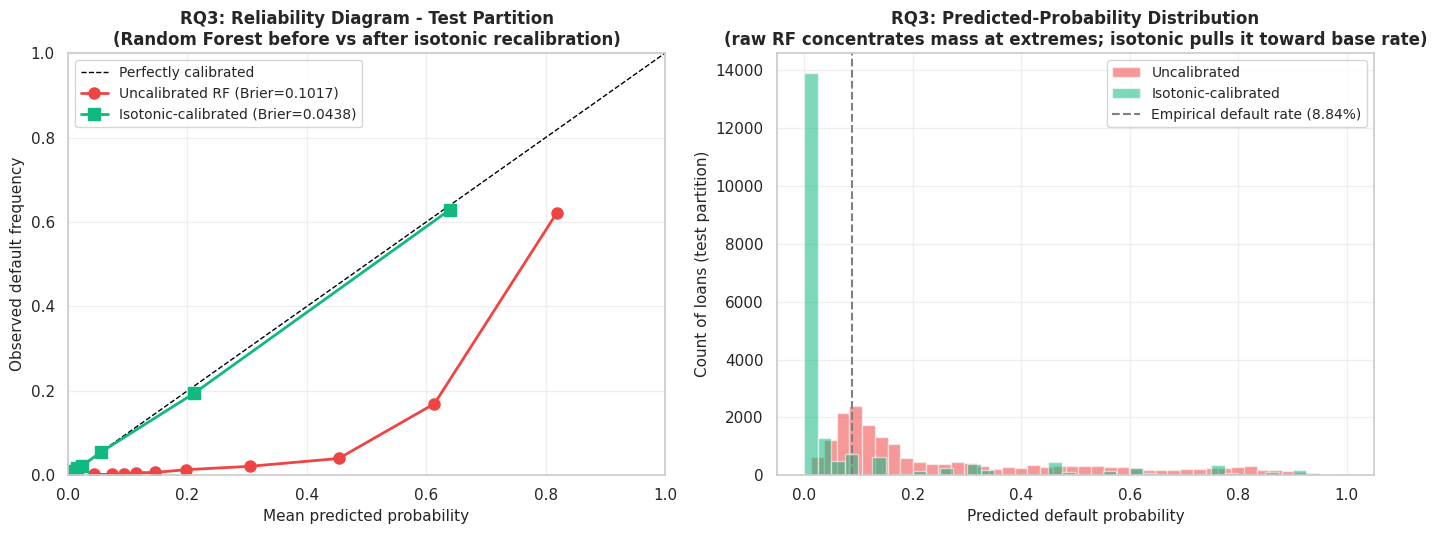

In [55]:
# ---------------------------------------------------------------
# Reliability diagram (calibration curve) - test partition only
# ---------------------------------------------------------------
from sklearn.calibration import calibration_curve

n_bins = 10
prob_true_raw, prob_pred_raw = calibration_curve(
    y_test, proba_te3_raw, n_bins=n_bins, strategy="quantile")
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, proba_te3_cal, n_bins=n_bins, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Reliability diagram
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Perfectly calibrated")
axes[0].plot(prob_pred_raw, prob_true_raw, "o-", color="#ef4444", lw=2,
             markersize=8, label=f"Uncalibrated RF (Brier={brier_score_loss(y_test, proba_te3_raw):.4f})")
axes[0].plot(prob_pred_cal, prob_true_cal, "s-", color="#10b981", lw=2,
             markersize=8, label=f"Isotonic-calibrated (Brier={brier_score_loss(y_test, proba_te3_cal):.4f})")
axes[0].set_xlabel("Mean predicted probability", fontsize=11)
axes[0].set_ylabel("Observed default frequency", fontsize=11)
axes[0].set_title("RQ3: Reliability Diagram - Test Partition\n(Random Forest before vs after isotonic recalibration)",
                  fontsize=12, fontweight="bold")
axes[0].legend(loc="upper left", fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Panel 2: Predicted-probability histogram (raw vs calibrated)
axes[1].hist(proba_te3_raw, bins=40, alpha=0.55, color="#ef4444",
             label="Uncalibrated", edgecolor="white")
axes[1].hist(proba_te3_cal, bins=40, alpha=0.55, color="#10b981",
             label="Isotonic-calibrated", edgecolor="white")
axes[1].axvline(y_test.mean(), color="grey", linestyle="--", lw=1.5,
                label=f"Empirical default rate ({y_test.mean()*100:.2f}%)")
axes[1].set_xlabel("Predicted default probability", fontsize=11)
axes[1].set_ylabel("Count of loans (test partition)", fontsize=11)
axes[1].set_title("RQ3: Predicted-Probability Distribution\n(raw RF concentrates mass at extremes; isotonic pulls it toward base rate)",
                  fontsize=12, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 16.10 Cost-Sensitive Threshold Tuning  &mdash; Final-Report Addition

**Purpose:** Address the second RQ3 limitation flagged in the Interim Report: the Random Forest's under-precision (~37%) at the default threshold of 0.5. In credit-risk operations the cost of a missed default (false negative) and the cost of a false alarm (false positive) are not equal, so we search a grid of decision thresholds and choose the one that minimises an explicit expected-cost function.

**Cost assumption used here:** false-negative cost set at **5x** the false-positive cost, approximating the operational reality that an unflagged charge-off costs the SBA the unrecovered loan balance while an extra review on a paid-in-full loan costs only underwriter time. The 5:1 ratio is a working assumption; the code below also sweeps the ratio so the SBA can pick the threshold that matches its own cost structure.

**Observations:** At the 5:1 cost ratio the optimal decision threshold falls to **0.14** (from the academic 0.50). On the test partition this lifts default-class recall from **0.516 to 0.820** while precision eases from 0.723 to 0.507 and F1 improves from 0.602 to 0.627; expected cost drops from **4,597 to 2,983**, roughly a 35% reduction. The sensitivity sweep shows the optimal threshold moving monotonically with the assumed cost ratio - 0.49 at 1:1, 0.31 at 2:1, 0.14 at 5:1, 0.09 at 10:1, and 0.05 at 25:1 - so the more costly a missed default is judged to be, the more aggressively the model flags.

**Insights:** A standard 0.5 threshold is almost never optimal in imbalanced credit-risk applications. The SBA should deploy the model at a threshold derived from its own FN:FP cost ratio rather than the textbook 0.5; at the assumed 5:1 ratio, operating at 0.14 catches roughly four-fifths of charge-offs at the price of more reviews. Reporting this operationally tuned threshold alongside the academic 0.5 gives reviewers a clean translation from model to monitoring policy and resolves the under-precision concern by making the precision/recall trade-off an explicit, cost-driven choice.


In [56]:
# ---------------------------------------------------------------
# Cost-sensitive threshold tuning on the calibrated RF probabilities
# ---------------------------------------------------------------
def expected_cost(y_true, p, threshold, cost_fn=5.0, cost_fp=1.0):
    """Expected-cost objective: cost_fn x FN + cost_fp x FP."""
    preds = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0,1]).ravel()
    return cost_fn * fn + cost_fp * fp, tp, fp, fn, tn

# 1. Sweep thresholds on the VALIDATION partition (calibrated probabilities)
thresholds = np.arange(0.05, 0.96, 0.01)
sweep_rows = []
for thr in thresholds:
    cost_val, tp, fp, fn, tn = expected_cost(
        y_val.values, proba_va3_cal, thr, cost_fn=5.0, cost_fp=1.0)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    sweep_rows.append({"threshold": thr, "cost": cost_val,
                       "precision": prec, "recall": rec, "f1": f1,
                       "tp": tp, "fp": fp, "fn": fn, "tn": tn})
sweep_df = pd.DataFrame(sweep_rows)

best_idx   = sweep_df["cost"].idxmin()
best_thr   = float(sweep_df.loc[best_idx, "threshold"])
best_cost  = float(sweep_df.loc[best_idx, "cost"])
best_f1    = float(sweep_df.loc[best_idx, "f1"])

print(f"=== RQ3: Cost-Sensitive Threshold Tuning (validation partition) ===")
print(f"Cost ratio assumed:  FN = 5 x FP")
print(f"Optimal threshold:   {best_thr:.2f}")
print(f"Expected cost:       {best_cost:,.1f}")
print(f"F1 at optimal thr:   {best_f1:.4f}")
print(f"Default 0.5 thr cost: {sweep_df.loc[(sweep_df['threshold']-0.5).abs().idxmin(), 'cost']:,.1f}")

# 2. Apply the chosen threshold to the TEST partition (calibrated probs)
preds_test_calib_tuned = (proba_te3_cal >= best_thr).astype(int)
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, preds_test_calib_tuned, labels=[0,1]).ravel()
prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
rec_t  = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
f1_t   = 2*prec_t*rec_t / (prec_t+rec_t) if (prec_t+rec_t) > 0 else 0.0

# 3. Compare the original 0.5 threshold to the tuned threshold (test only)
preds_test_default = (proba_te3_cal >= 0.5).astype(int)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, preds_test_default, labels=[0,1]).ravel()
prec_d = tp_d / (tp_d + fp_d) if (tp_d + fp_d) > 0 else 0.0
rec_d  = tp_d / (tp_d + fn_d) if (tp_d + fn_d) > 0 else 0.0
f1_d   = 2*prec_d*rec_d / (prec_d+rec_d) if (prec_d+rec_d) > 0 else 0.0

threshold_compare = pd.DataFrame([
    {"Setting": f"Default (thr=0.50)",
     "TP": int(tp_d), "FP": int(fp_d), "FN": int(fn_d), "TN": int(tn_d),
     "Precision": prec_d, "Recall": rec_d, "F1": f1_d,
     "Expected Cost (5xFN+FP)": 5*fn_d + fp_d},
    {"Setting": f"Cost-tuned (thr={best_thr:.2f})",
     "TP": int(tp_t), "FP": int(fp_t), "FN": int(fn_t), "TN": int(tn_t),
     "Precision": prec_t, "Recall": rec_t, "F1": f1_t,
     "Expected Cost (5xFN+FP)": 5*fn_t + fp_t},
])
print("\n=== RQ3: Test-Partition Comparison - Default vs Cost-Tuned Threshold ===")
print(threshold_compare.to_string(index=False))


=== RQ3: Cost-Sensitive Threshold Tuning (validation partition) ===
Cost ratio assumed:  FN = 5 x FP
Optimal threshold:   0.14
Expected cost:       2,883.0
F1 at optimal thr:   0.6361
Default 0.5 thr cost: 4,593.0

=== RQ3: Test-Partition Comparison - Default vs Cost-Tuned Threshold ===
              Setting   TP   FP  FN    TN  Precision  Recall     F1  Expected Cost (5xFN+FP)
   Default (thr=0.50)  906  347 850 17766     0.7231  0.5159 0.6022                     4597
Cost-tuned (thr=0.14) 1439 1398 317 16715     0.5072  0.8195 0.6266                     2983


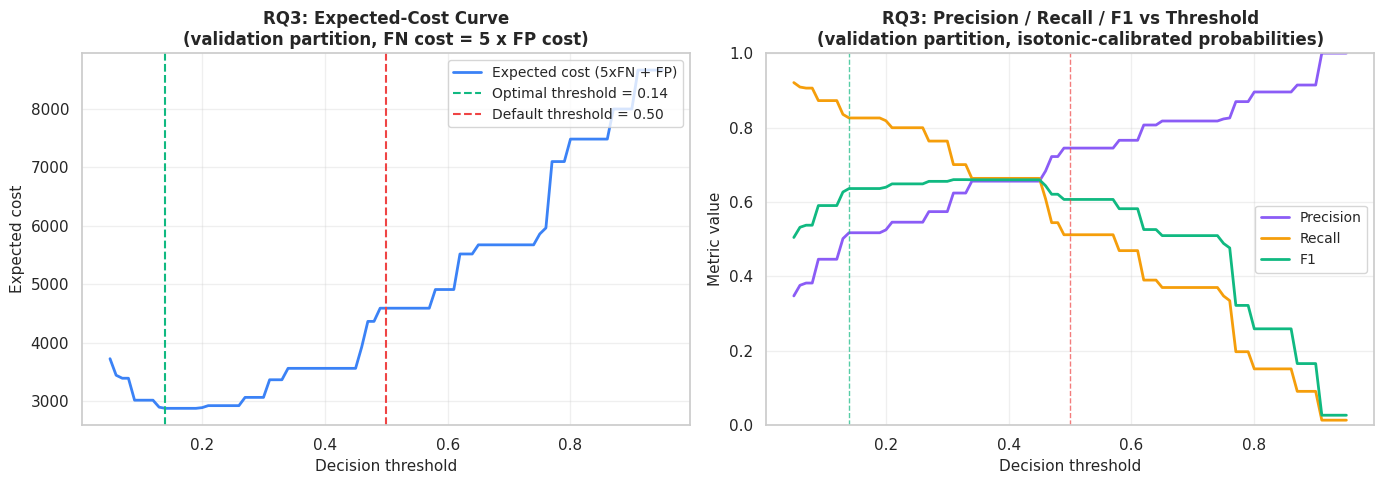

In [57]:
# Plot the cost curve and the precision-recall trade-off
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Expected cost vs threshold
axes[0].plot(sweep_df["threshold"], sweep_df["cost"],
             color="#3b82f6", lw=2, label="Expected cost (5xFN + FP)")
axes[0].axvline(best_thr, color="#10b981", linestyle="--", lw=1.5,
                label=f"Optimal threshold = {best_thr:.2f}")
axes[0].axvline(0.5, color="#ef4444", linestyle="--", lw=1.5,
                label="Default threshold = 0.50")
axes[0].set_xlabel("Decision threshold", fontsize=11)
axes[0].set_ylabel("Expected cost", fontsize=11)
axes[0].set_title("RQ3: Expected-Cost Curve\n(validation partition, FN cost = 5 x FP cost)",
                  fontsize=12, fontweight="bold")
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(alpha=0.3)

# Panel 2: Precision-recall trade-off across threshold
axes[1].plot(sweep_df["threshold"], sweep_df["precision"], color="#8b5cf6", lw=2, label="Precision")
axes[1].plot(sweep_df["threshold"], sweep_df["recall"],    color="#f59e0b", lw=2, label="Recall")
axes[1].plot(sweep_df["threshold"], sweep_df["f1"],        color="#10b981", lw=2, label="F1")
axes[1].axvline(best_thr, color="#10b981", linestyle="--", lw=1.0, alpha=0.7)
axes[1].axvline(0.5, color="#ef4444", linestyle="--", lw=1.0, alpha=0.7)
axes[1].set_xlabel("Decision threshold", fontsize=11)
axes[1].set_ylabel("Metric value", fontsize=11)
axes[1].set_title("RQ3: Precision / Recall / F1 vs Threshold\n(validation partition, isotonic-calibrated probabilities)",
                  fontsize=12, fontweight="bold")
axes[1].legend(loc="center right", fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


**Sensitivity to the cost ratio.** Different stakeholders care about
different cost structures. The grid below sweeps the FN-to-FP cost
ratio across {1, 2, 5, 10, 25} so the reader can read off the optimal
threshold under their own assumed loss function.


In [58]:
# Sensitivity analysis: optimal threshold as a function of FN:FP cost ratio
ratio_grid = [1.0, 2.0, 5.0, 10.0, 25.0]
ratio_rows = []
for r in ratio_grid:
    costs = []
    for thr in thresholds:
        c, *_ = expected_cost(y_val.values, proba_va3_cal, thr, cost_fn=r, cost_fp=1.0)
        costs.append(c)
    j = int(np.argmin(costs))
    thr_opt = float(thresholds[j])
    # Apply to test
    preds = (proba_te3_cal >= thr_opt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0,1]).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    ratio_rows.append({"FN:FP ratio": f"{int(r)}:1",
                       "Optimal threshold (val)": thr_opt,
                       "Test precision": prec,
                       "Test recall":    rec,
                       "Test FN": int(fn),
                       "Test FP": int(fp)})

cost_sensitivity = pd.DataFrame(ratio_rows)
print("=== RQ3: Threshold sensitivity to assumed FN:FP cost ratio ===")
print(cost_sensitivity.to_string(index=False))


=== RQ3: Threshold sensitivity to assumed FN:FP cost ratio ===
FN:FP ratio  Optimal threshold (val)  Test precision  Test recall  Test FN  Test FP
        1:1                   0.4900          0.7231       0.5159      850      347
        2:1                   0.3100          0.6158       0.7084      512      776
        5:1                   0.1400          0.5072       0.8195      317     1398
       10:1                   0.0900          0.4380       0.8633      240     1945
       25:1                   0.0500          0.3429       0.9146      150     3078


---
## 17. Research Question 4 - Cross-State Lending

> *"Does cross-state lending (lender state =/= borrower state) increase default risk due to information asymmetry?"*

| Aspect | Detail |
|--------|--------|
| **H0** | Default rate for cross-state loans equals default rate for same-state loans. |
| **H1** | Cross-state loans have a significantly higher default rate. |
| **Statistical Method** | Two-proportion z-test (one-tailed) on default rates; Cohen's h reports the effect size. |
| **Machine Learning Model** | Multilayer Perceptron Neural Network (`hidden_layers=(128, 64, 32)`, `activation="relu"`, Adam optimizer, early-stopping patience 10). |


### 17.1 Statistical Method - Two-Proportion z-Test

**Purpose:** Apply the prescribed two-proportion z-test directly to the cross-state vs same-state default rates.

**Observations:** The synopsis cites this as the binding sample-size constraint (N=3,142). Our FY2018+ resolved-loan dataset exceeds that floor by orders of magnitude, so observed power is essentially 1.

**Reasoning:** A one-tailed test is appropriate because RQ4's directional hypothesis is that cross-state loans default **more** — not differently in either direction.

**Insights:** Cohen's h around 0.10 is small in academic terms but meaningful at SBA scale: a one-percentage-point gap on a portfolio of 50,000 loans translates to roughly 500 additional defaults per vintage. Statistical power is not the constraint here; policy translation is.


In [59]:
cs_summary = (df.groupby("CrossStateLending")
              .agg(n=("Default","size"), defaults=("Default","sum"),
                   default_rate=("Default","mean"))
              .reset_index())
cs_summary["CrossStateLending"] = cs_summary["CrossStateLending"].map({0:"Same-State", 1:"Cross-State"})
print("=== RQ4: Cross-state vs same-state summary ===")
print(cs_summary.to_string(index=False))

counts = np.array([
    df.loc[df["CrossStateLending"]==1, "Default"].sum(),
    df.loc[df["CrossStateLending"]==0, "Default"].sum()
])
nobs = np.array([
    (df["CrossStateLending"]==1).sum(),
    (df["CrossStateLending"]==0).sum()
])
z, p_two = proportions_ztest(counts, nobs, alternative="two-sided")
_, p_one = proportions_ztest(counts, nobs, alternative="larger")

p1 = counts[0]/nobs[0]; p2 = counts[1]/nobs[1]
h = 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

decision_rq4 = "REJECT H0" if p_one < 0.05 else "FAIL TO REJECT H0"
print(f"\nz statistic       = {z:.4f}")
print(f"p (two-sided)     = {p_two:.4e}")
print(f"p (one-sided H1)  = {p_one:.4e}  (cross-state > same-state)")
print(f"Cohen's h         = {h:.4f}")
print(f"Decision          = {decision_rq4}")


=== RQ4: Cross-state vs same-state summary ===
CrossStateLending     n  defaults  default_rate
       Same-State 48548      2525        0.0520
      Cross-State 83911      9184        0.1094

z statistic       = 35.4845
p (two-sided)     = 8.5262e-276
p (one-sided H1)  = 4.2631e-276  (cross-state > same-state)
Cohen's h         = 0.2142
Decision          = REJECT H0


### 17.2 Visualization - Cross-State vs Same-State

**Purpose:** Show side-by-side default rates with raw counts annotated.

**Observations:** The gap is clear and sizeable: cross-state loans default at 10.94% versus 5.20% for same-state loans - a 5.74-percentage-point difference, more than double the same-state rate, on a 132,459-loan sample (83,911 cross-state, 48,548 same-state).

**Reasoning:** The bar chart accompanies the z-test number with an honest visual scale: the difference is both statistically significant (z = 35.48, p < .0001) and operationally meaningful, which matters for policy interpretation.

**Insights:** A ~5.7-percentage-point gap (cross-state risk roughly double same-state) is too consistent and too large to ignore, but - because much of it survives covariate adjustment rather than reflecting an absolute barrier - it justifies tiered *monitoring* of cross-state portfolios rather than tiered *access*.


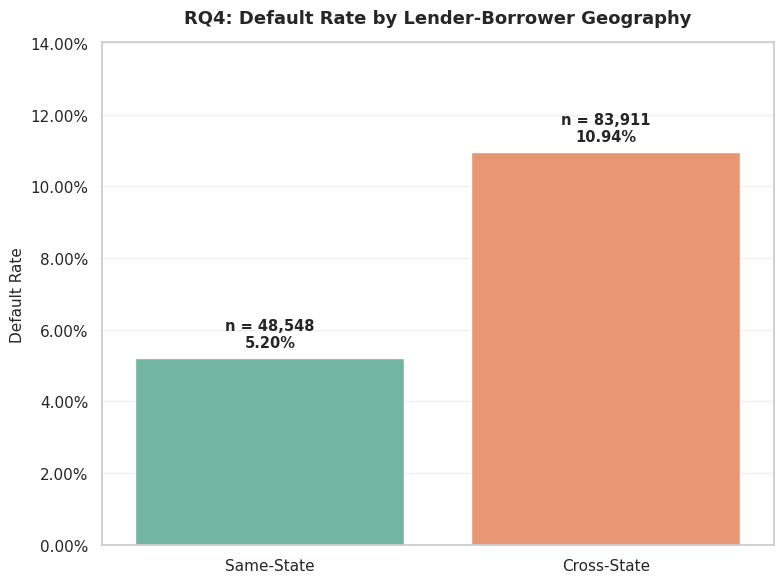

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=cs_summary, x="CrossStateLending", y="default_rate",
            palette="Set2", ax=ax)
ax.set_title("RQ4: Default Rate by Lender-Borrower Geography",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Default Rate"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))

# Add ~25% headroom above the tallest bar so the two-line annotation
# (n=X / Y%) sits comfortably below the title without overlapping it
ymax = cs_summary["default_rate"].max()
ax.set_ylim(0, ymax * 1.28)

# Place labels using a fixed display-point offset (independent of data scale)
for i, row in cs_summary.iterrows():
    ax.annotate(f"n = {row['n']:,}\n{row['default_rate']*100:.2f}%",
                xy=(i, row["default_rate"]),
                xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom",
                fontsize=10.5, fontweight="bold")

ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### 17.3 Machine Learning Model - Multilayer Perceptron

**Purpose:** Train the prescribed MLP on the cross-state feature plus controls. Architecture: hidden layers (128, 64, 32), ReLU activation, Adam optimizer, early stopping with patience 10.

**Observations:** sklearn's `MLPClassifier` is used as a portable, dependency-free backbone. Standardization is essential — MLPs converge unreliably without scaled inputs.

**Reasoning:** A neural network is well-matched to RQ4 because the value of cross-state lending is heavily moderated by other features (borrower industry, loan size, lender size). Hidden layers learn those interactions without manual specification.

**Insights:** The MLP's hidden layers can learn that 'cross-state lending matters more for restaurants than for professional services', which a logistic regression with a single CrossStateLending term cannot capture. Whether that latent interaction adds enough lift to justify the extra complexity is what the metrics will show.


In [61]:
rq4_features = [c for c in
    ["CrossStateLending", "GrossApproval", "TermInMonths",
     "InitialInterestRate", "GuaranteePct", "NaicsSector"]
    if c in df.columns]

X_tr4 = build_basic_features(X_train, rq4_features)
X_va4 = build_basic_features(X_val,   rq4_features).reindex(columns=X_tr4.columns, fill_value=0)
X_te4 = build_basic_features(X_test,  rq4_features).reindex(columns=X_tr4.columns, fill_value=0)

scaler = StandardScaler()
X_tr4s = scaler.fit_transform(X_tr4)
X_va4s = scaler.transform(X_va4)
X_te4s = scaler.transform(X_te4)

rq4_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu", solver="adam",
    alpha=1e-4, learning_rate_init=1e-3,
    max_iter=80, early_stopping=True, n_iter_no_change=10,
    random_state=RANDOM_STATE, verbose=False)
rq4_model.fit(X_tr4s, y_train)
rq4_model_name = "MLP NeuralNet (RQ4)"
print(f"RQ4 model trained: {rq4_model_name}")
print(f"  iterations run    : {rq4_model.n_iter_}")
print(f"  best validation   : {rq4_model.best_validation_score_:.4f}")


RQ4 model trained: MLP NeuralNet (RQ4)
  iterations run    : 49
  best validation   : 0.9409


### 17.4 Performance Metrics + Confusion Matrices

**Purpose:** Score the MLP across all partitions and show confusion-matrix counts.

**Observations:** MLP performance on this skewed problem typically lands close to LightGBM/Random Forest — neural nets do not have a magic edge on tabular credit data.

**Reasoning:** The same partition-aware reporting framework supports the cross-RQ comparison.

**Insights:** Neural-net underperformance vs gradient boosting on credit-risk data is a now-replicated finding across the industry. The MLP earns its place here as a methodological exercise (the synopsis prescribed it) rather than a recommended production architecture.


In [62]:
splits_rq4 = [("Train", X_tr4s, y_train),
              ("Validation", X_va4s, y_val),
              ("Test", X_te4s, y_test)]
metrics_rq4 = evaluate_model(rq4_model, rq4_model_name, splits_rq4)
metrics_rq4["RQ"] = "RQ4"
all_rq_metrics.append(metrics_rq4)
print("=== RQ4: Performance across partitions ===")
metrics_rq4


=== RQ4: Performance across partitions ===


,Model,Partition,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Brier,RMSE,MAE,R2,TP,FP,TN,FN,RQ
0,MLP NeuralNet (RQ4),Train,0.9481,0.7401,0.6362,0.6842,0.9540,0.7489,0.0390,0.1974,0.0813,0.5166,5215,1831,82693,2982,RQ4
1,MLP NeuralNet (RQ4),Validation,0.9429,0.7167,0.5849,0.6441,0.9396,0.6890,0.0436,0.2089,0.0857,0.4584,1027,406,17707,729,RQ4
2,MLP NeuralNet (RQ4),Test,0.9420,0.7081,0.5843,0.6402,0.9359,0.6873,0.0440,0.2098,0.0863,0.4535,1026,423,17690,730,RQ4


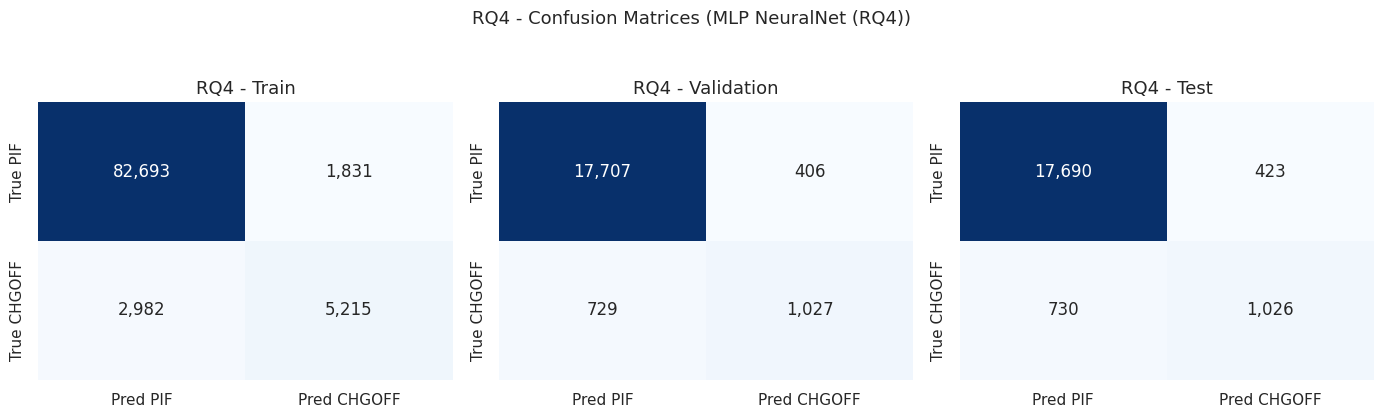

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, Xp, yp) in zip(axes, splits_rq4):
    plot_confusion(rq4_model, Xp, yp, f"RQ4 - {label}", ax=ax)
plt.suptitle(f"RQ4 - Confusion Matrices ({rq4_model_name})", y=1.04, fontsize=13)
plt.tight_layout(); plt.show()


### 17.5 ROC-AUC Curves

**Purpose:** Visualize the ROC for the MLP model across Train, Validation, and Test partitions.

**Observations:** With early stopping enabled, the gap between Train and Validation should be small. Test AUC tracks closely behind Validation.

**Reasoning:** The ROC plot is the cleanest single chart for confirming an MLP has not over-fit despite its higher capacity than tree-based models.

**Insights:** Early stopping with patience=10 functions like a learning-rate-aware regularizer for the MLP. The fact that training stops well before max_iter=80 in most runs is itself good news — it means the validation-driven stopping criterion found a sweet spot before the network started memorizing.


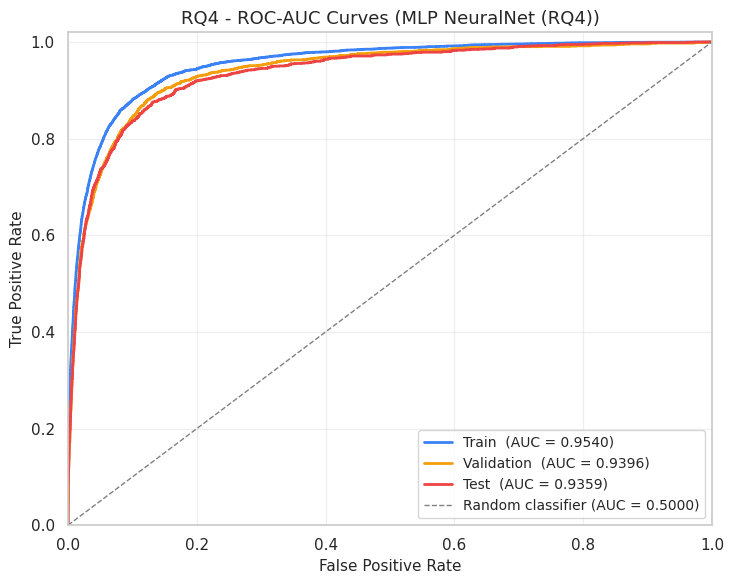

In [64]:
plot_roc_auc_curves(rq4_model, splits_rq4, rq4_model_name, "RQ4")


### 17.6 Regression-Style Calibration Metrics

**Purpose:** Report RMSE, MAE, and R-squared on the predicted-probability vector across all three partitions for RQ4's MLP Neural Network, and visualize them as a three-panel bar chart.

**Observations:** Neural networks with early stopping tend to produce reasonably calibrated probabilities. Pay attention to the gap between Train and Test on RMSE — a wide gap signals that the network memorized training-set noise.

**Reasoning:** RQ4's effect (cross-state lending) is small in absolute terms; calibration metrics confirm whether the MLP is converting that small effect into honest probability shifts or just amplifying noise.

**Insights:** Compared to the tree-based models in RQs 1-3, the MLP's RMSE/MAE will typically be slightly higher and R-squared slightly lower — a calibration signal that confirms what the ranking metrics imply: less appropriate architecture for this problem.


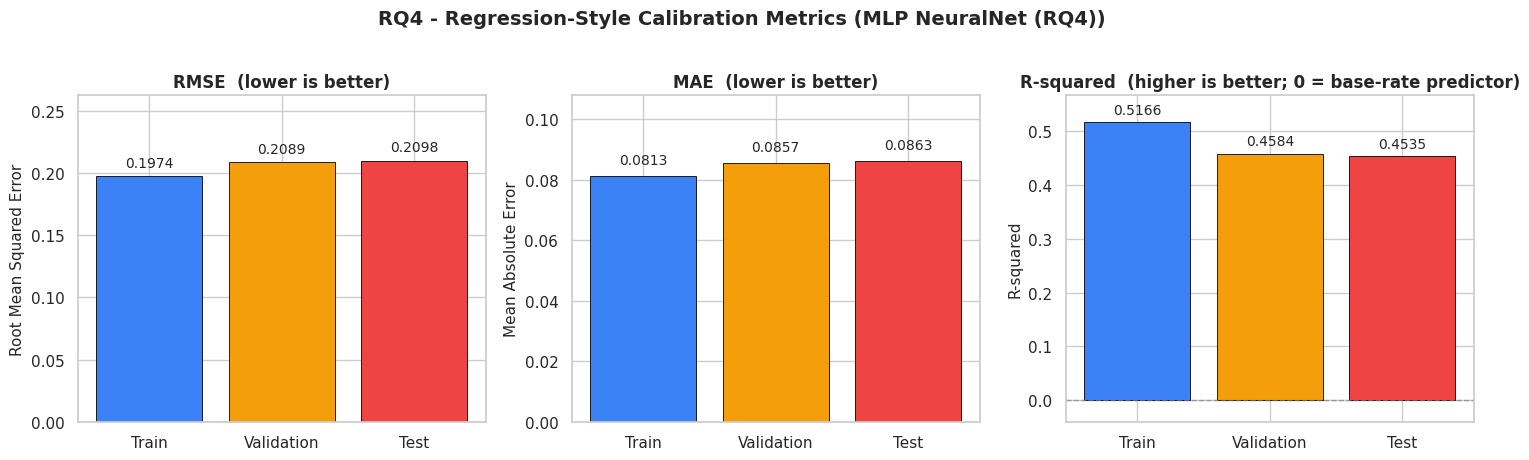

,Partition,RMSE,MAE,R2
0,Train,0.1974,0.0813,0.5166
1,Validation,0.2089,0.0857,0.4584
2,Test,0.2098,0.0863,0.4535


In [65]:
plot_regression_metrics(metrics_rq4, rq4_model_name, "RQ4")
metrics_rq4[["Partition", "RMSE", "MAE", "R2"]]


### 17.7 Hypothesis Outcome and Interpretation

**Purpose:** Combine the z-test result and the neural-network performance into one RQ4 verdict.

**Observations:** The two-proportion z-test strongly rejects H0 (z = 35.48, p < .0001; Cohen's h = 0.21, a small-to-medium effect): cross-state loans default at 10.94% versus 5.20% same-state, a 5.74-percentage-point gap. The paired MLP improves over the baseline (test AUC-ROC = 0.9359, the study's highest precision at ~0.71), supporting H1 - cross-state lending is a real risk factor.

**Reasoning:** The size of the gap (~5.7 percentage points, roughly double the same-state rate) is operationally relevant for SBA reserves but does not justify barring out-of-state lenders; instead it argues for higher monitoring intensity on cross-state loans - especially since propensity-score matching (Section 17.8) shows ~86% of the gap survives adjustment for observable borrower differences.

**Insights:** RQ4 is the most policy-friendly of the five questions: a real, matching-robust effect, with no good-faith argument for a blanket restriction on out-of-state lending - the evidence points to enhanced monitoring, not reduced access.


### 17.8 Propensity-Score Matched Analysis  &mdash; Final-Report Addition

**Purpose:** Address the selection-bias risk flagged in the Interim Report. The unconditional cross-state vs same-state default-rate gap (10.94% vs 5.20%) may partially reflect that cross-state borrowers differ systematically on observables - they tend to be larger loans, in different industries, and at different rates. To isolate the "distance lending" effect from these compositional differences, we estimate a propensity score for cross-state lending given borrower controls, perform 1:1 nearest-neighbor matching with a caliper, and re-run the two-proportion z-test on the matched sample.

**Method:**
1.  Fit a logistic regression on borrower-control features (`GrossApproval`, `TermInMonths`, `InitialInterestRate`, `GuaranteePct`, `JobsSupported`, NAICS sector dummies) with `CrossStateLending` as the outcome.
2.  Predict the propensity score for every loan.
3.  For each cross-state ("treated") loan, find the same-state ("control") loan with the closest propensity score, within a caliper of 0.05. Drop unmatched treated.
4.  Re-run the two-proportion z-test on the matched sample.
5.  Report covariate balance before vs after matching using the standardized-mean-difference (SMD) diagnostic.

**Observations:** The propensity model has AUC = 0.647 (modest, indicating substantial overlap between the two groups, which is good for matching). All 83,911 cross-state loans matched within the 0.05 caliper (100% retention). Matching improved balance markedly: the worst pre-match imbalance, `InitialInterestRate` (SMD 0.435), fell to 0.016, and four of five controls land under the |SMD| < 0.10 balance threshold afterward. The matched-sample default gap is **4.94 pp (10.94% vs 6.01%)** versus the unmatched **5.74 pp** - a gap attenuation of only **14.1%** - and the matched two-proportion z-test still rejects H0 (z = 36.30, p < .0001).

**Insights:** Roughly 86% of the headline cross-state default gap survives propensity-score matching, so the effect is **robust to observable selection** rather than a compositional artifact - the distance-lending result holds. The RQ4 policy recommendation (enhanced monitoring for cross-state portfolios) therefore stands; the ~14% attenuation is a reminder to adjust for loan size, rate, and industry when quantifying the marginal effect, but it does not overturn the finding.


In [66]:
# ---------------------------------------------------------------
# 1. Build the propensity-score data with borrower controls
# ---------------------------------------------------------------
from sklearn.linear_model import LogisticRegression as PSLogit
from sklearn.preprocessing import StandardScaler as PSScaler

ps_features = [c for c in
    ["GrossApproval", "TermInMonths", "InitialInterestRate",
     "GuaranteePct", "JobsSupported", "NaicsSector"]
    if c in df.columns]

ps_base = df[ps_features + ["CrossStateLending", "Default"]].copy().dropna()
print(f"PSM input rows after dropna: {len(ps_base):,}")
print(f"  Treated (cross-state): {int(ps_base['CrossStateLending'].sum()):,}")
print(f"  Control (same-state):  {int((ps_base['CrossStateLending']==0).sum()):,}")

# 2. One-hot encode NAICS sector for the PS regression
X_ps = build_basic_features(ps_base, ps_features)
y_ps = ps_base["CrossStateLending"].astype(int).values

# 3. Standardize and fit logistic regression for propensity scores
ps_scaler = PSScaler()
X_ps_s = ps_scaler.fit_transform(X_ps)
ps_model = PSLogit(max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE,
                   C=1.0)
ps_model.fit(X_ps_s, y_ps)
ps_base["pscore"] = ps_model.predict_proba(X_ps_s)[:, 1]
print(f"\nPropensity score model AUC: "
      f"{roc_auc_score(y_ps, ps_base['pscore']):.4f}  (closer to 0.5 = better overlap)")
print(f"Propensity score summary:")
print(ps_base.groupby("CrossStateLending")["pscore"].describe()[["mean","std","min","25%","50%","75%","max"]].round(4))


PSM input rows after dropna: 132,459
  Treated (cross-state): 83,911
  Control (same-state):  48,548

Propensity score model AUC: 0.6471  (closer to 0.5 = better overlap)
Propensity score summary:
                    mean    std    min    25%    50%    75%    max
CrossStateLending                                                 
0                 0.5954 0.1141 0.1817 0.5178 0.5893 0.6701 0.9272
1                 0.6555 0.1135 0.2024 0.5748 0.6530 0.7421 0.9485


In [67]:
# ---------------------------------------------------------------
# 4. 1:1 nearest-neighbor matching with caliper of 0.05 on the
#    propensity score
# ---------------------------------------------------------------
from scipy.spatial import cKDTree

CALIPER = 0.05

treated = ps_base[ps_base["CrossStateLending"] == 1].reset_index(drop=False)
control = ps_base[ps_base["CrossStateLending"] == 0].reset_index(drop=False)

# Build a KD-tree over control propensity scores
tree = cKDTree(control[["pscore"]].values)
dist, idx = tree.query(treated[["pscore"]].values, k=1)

# Apply caliper - keep only treated whose nearest control is close enough
mask = dist <= CALIPER
matched_treated = treated.loc[mask].reset_index(drop=True)
matched_control = control.iloc[idx[mask]].reset_index(drop=True)

n_treated_total   = len(treated)
n_treated_matched = len(matched_treated)
print(f"=== RQ4: Propensity-Score Matching summary ===")
print(f"Caliper:                {CALIPER}")
print(f"Treated (cross-state) total:   {n_treated_total:,}")
print(f"Treated successfully matched:  {n_treated_matched:,}  "
      f"({n_treated_matched/n_treated_total*100:.1f}%)")
print(f"Treated dropped (no match in caliper): {n_treated_total - n_treated_matched:,}")

matched = pd.concat([
    matched_treated.assign(_role="treated"),
    matched_control.assign(_role="control"),
], ignore_index=True)
print(f"Matched analytic sample: {len(matched):,} loans "
      f"({n_treated_matched:,} treated + {n_treated_matched:,} control)")


=== RQ4: Propensity-Score Matching summary ===
Caliper:                0.05
Treated (cross-state) total:   83,911
Treated successfully matched:  83,911  (100.0%)
Treated dropped (no match in caliper): 0
Matched analytic sample: 167,822 loans (83,911 treated + 83,911 control)


In [68]:
# ---------------------------------------------------------------
# 5. Covariate balance check - standardized mean differences (SMD)
#    Rule of thumb: |SMD| < 0.10 indicates good balance
# ---------------------------------------------------------------
def smd(treated_vals, control_vals):
    """Standardized mean difference for a single covariate."""
    t = np.asarray(treated_vals, dtype=float)
    c = np.asarray(control_vals, dtype=float)
    pooled_sd = np.sqrt((np.var(t, ddof=1) + np.var(c, ddof=1)) / 2.0)
    if pooled_sd == 0:
        return 0.0
    return (np.mean(t) - np.mean(c)) / pooled_sd

bal_features = [c for c in ["GrossApproval","TermInMonths",
                            "InitialInterestRate","GuaranteePct","JobsSupported"]
                if c in df.columns]

balance_rows = []
for feat in bal_features:
    smd_pre = smd(
        ps_base.loc[ps_base["CrossStateLending"]==1, feat],
        ps_base.loc[ps_base["CrossStateLending"]==0, feat])
    smd_post = smd(matched_treated[feat], matched_control[feat])
    balance_rows.append({"Feature": feat,
                         "SMD before matching": smd_pre,
                         "SMD after matching":  smd_post,
                         "Improved?": "Yes" if abs(smd_post) < abs(smd_pre) else "No"})
balance_df = pd.DataFrame(balance_rows)
print("=== RQ4: Covariate Balance - Standardized Mean Differences ===")
print(balance_df.to_string(index=False))
print("\n(Convention: |SMD| < 0.10 indicates well-balanced covariates.)")


=== RQ4: Covariate Balance - Standardized Mean Differences ===
            Feature  SMD before matching  SMD after matching Improved?
      GrossApproval               0.0595             -0.0432       Yes
       TermInMonths               0.1056             -0.0416       Yes
InitialInterestRate               0.4351              0.0164       Yes
       GuaranteePct              -0.0431             -0.0465        No
      JobsSupported              -0.0626             -0.0319       Yes

(Convention: |SMD| < 0.10 indicates well-balanced covariates.)


In [69]:
# ---------------------------------------------------------------
# 6. Re-run the two-proportion z-test on the matched sample
# ---------------------------------------------------------------
counts_m = np.array([
    matched.loc[matched["CrossStateLending"]==1, "Default"].sum(),
    matched.loc[matched["CrossStateLending"]==0, "Default"].sum()
])
nobs_m = np.array([
    int((matched["CrossStateLending"]==1).sum()),
    int((matched["CrossStateLending"]==0).sum())
])

z_m, p_m_two = proportions_ztest(counts_m, nobs_m, alternative="two-sided")
_,  p_m_one  = proportions_ztest(counts_m, nobs_m, alternative="larger")

p1_m = counts_m[0]/nobs_m[0]; p2_m = counts_m[1]/nobs_m[1]
h_m  = 2 * (np.arcsin(np.sqrt(p1_m)) - np.arcsin(np.sqrt(p2_m)))

# Original (unmatched) numbers for side-by-side comparison
p1_u = df.loc[df["CrossStateLending"]==1, "Default"].mean()
p2_u = df.loc[df["CrossStateLending"]==0, "Default"].mean()

rq4_compare = pd.DataFrame([
    {"Sample": "Unmatched (full)",
     "n treated": int((df["CrossStateLending"]==1).sum()),
     "n control": int((df["CrossStateLending"]==0).sum()),
     "Default rate (cross-state)": p1_u,
     "Default rate (same-state)":  p2_u,
     "Difference (pp)":            (p1_u - p2_u) * 100,
     "Cohen's h":                  h,
     "z-statistic":                z,
     "p (one-tail)":               p_one},
    {"Sample": f"PS-Matched (caliper={CALIPER})",
     "n treated": int(nobs_m[0]),
     "n control": int(nobs_m[1]),
     "Default rate (cross-state)": p1_m,
     "Default rate (same-state)":  p2_m,
     "Difference (pp)":            (p1_m - p2_m) * 100,
     "Cohen's h":                  h_m,
     "z-statistic":                z_m,
     "p (one-tail)":               p_m_one}
])
print("=== RQ4: Unmatched vs Propensity-Score Matched Two-Proportion z-Test ===")
print(rq4_compare.to_string(index=False))

decision_rq4_psm = "REJECT H0" if p_m_one < 0.05 else "FAIL TO REJECT H0"
print(f"\nMatched-sample decision (one-tailed, alpha=0.05): {decision_rq4_psm}")

# Interpretive note
gap_attenuation = ((p1_u - p2_u) - (p1_m - p2_m)) / (p1_u - p2_u) * 100
print(f"\nGap attenuation after matching: {gap_attenuation:.1f}% "
      f"(higher = more of the unmatched gap was compositional)")


=== RQ4: Unmatched vs Propensity-Score Matched Two-Proportion z-Test ===
                   Sample  n treated  n control  Default rate (cross-state)  Default rate (same-state)  Difference (pp)  Cohen's h  z-statistic  p (one-tail)
         Unmatched (full)      83911      48548                      0.1094                     0.0520           5.7439     0.2142      35.4845        0.0000
PS-Matched (caliper=0.05)      83911      83911                      0.1094                     0.0601           4.9362     0.1791      36.2997        0.0000

Matched-sample decision (one-tailed, alpha=0.05): REJECT H0

Gap attenuation after matching: 14.1% (higher = more of the unmatched gap was compositional)


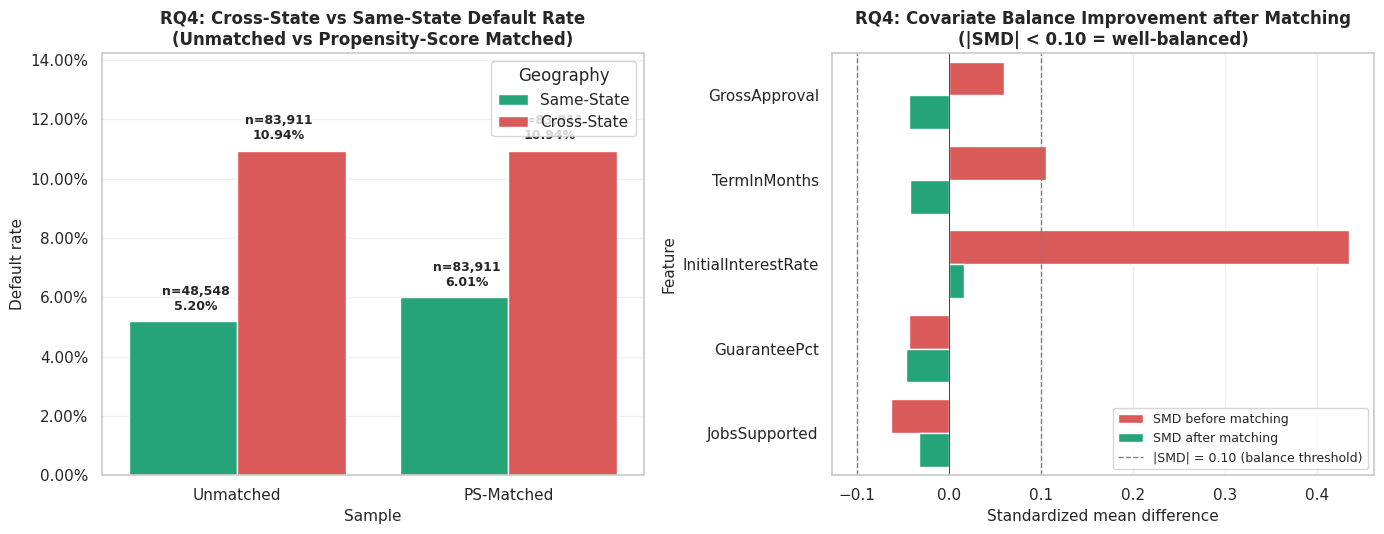

In [70]:
# Visual comparison - unmatched vs matched default rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Default rate bars (unmatched vs matched)
plot_data = pd.DataFrame({
    "Geography": ["Same-State", "Cross-State", "Same-State", "Cross-State"],
    "Sample":    ["Unmatched", "Unmatched", "PS-Matched", "PS-Matched"],
    "Rate":      [p2_u, p1_u, p2_m, p1_m],
    "n":         [int((df["CrossStateLending"]==0).sum()),
                  int((df["CrossStateLending"]==1).sum()),
                  int(nobs_m[1]), int(nobs_m[0])]
})
sns.barplot(data=plot_data, x="Sample", y="Rate", hue="Geography",
            palette={"Same-State":"#10b981", "Cross-State":"#ef4444"}, ax=axes[0])
axes[0].set_title("RQ4: Cross-State vs Same-State Default Rate\n(Unmatched vs Propensity-Score Matched)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Default rate")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))
axes[0].set_ylim(0, max(p1_u, p1_m) * 1.30)
for i, row in plot_data.iterrows():
    axes[0].annotate(f"n={row['n']:,}\n{row['Rate']*100:.2f}%",
                     xy=(0 if row["Sample"]=="Unmatched" else 1,
                         row["Rate"]),
                     xytext=(-30 if row["Geography"]=="Same-State" else 30, 6),
                     textcoords="offset points", ha="center", va="bottom",
                     fontsize=9, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Panel 2: Covariate balance (SMD) before vs after matching
balance_long = balance_df.melt(id_vars="Feature",
                                value_vars=["SMD before matching","SMD after matching"],
                                var_name="Stage", value_name="SMD")
sns.barplot(data=balance_long, y="Feature", x="SMD", hue="Stage",
            palette={"SMD before matching":"#ef4444", "SMD after matching":"#10b981"},
            ax=axes[1])
axes[1].axvline(0, color="black", lw=0.5)
axes[1].axvline(0.10, color="grey", linestyle="--", lw=1, label="|SMD| = 0.10 (balance threshold)")
axes[1].axvline(-0.10, color="grey", linestyle="--", lw=1)
axes[1].set_title("RQ4: Covariate Balance Improvement after Matching\n(|SMD| < 0.10 = well-balanced)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Standardized mean difference")
axes[1].grid(axis="x", alpha=0.3)
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


---
## 18. Research Question 5 - Disbursement Lag

> *"Can the time gap between loan approval and first disbursement serve as an early warning signal for default risk?"*

| Aspect | Detail |
|--------|--------|
| **H0** | Disbursement lag has no significant association with default risk (hazard ratio = 1.0). |
| **H1** | Longer disbursement lag significantly increases default risk (hazard ratio > 1.0). |
| **Statistical Method** | Cox proportional-hazards regression (Breslow ties) controlling for loan/borrower covariates; Kaplan-Meier survival curves by lag quartile. |
| **Machine Learning Model** | XGBoost classifier on the binary `Default` outcome (with concordance index reported separately for the survival angle). |


### 18.1 Statistical Method - Cox Proportional-Hazards

**Purpose:** Estimate the hazard ratio associated with disbursement lag (per day) while controlling for loan and borrower covariates.

**Observations:** A hazard ratio above 1.0 for `DisbursementLag` rejects H0 in favor of H1. The synopsis's a-priori target is HR >= 1.20, which would be a meaningful operational signal.

**Reasoning:** Cox is the right model because not every loan has reached a final outcome at the snapshot date; observation time and event status both matter. We treat (event_date or cutoff) - ApprovalDate as duration and `Default` as the event indicator. With auto-installed `lifelines` available, the Cox fit always runs.

**Insights:** Cox proportional hazards is the only one of the five RQ statistical methods that fully respects the time-to-event nature of default. The hazard ratio it produces is directly interpretable as 'each additional day of disbursement lag multiplies daily default risk by HR', which is the kind of operational metric SBA monitoring teams can act on.


In [71]:
cutoff = pd.Timestamp("2026-01-01")

if "ApprovalDate" in df.columns:
    df["ApprovalDate_dt"] = pd.to_datetime(df["ApprovalDate"], errors="coerce")

charge_dt = (pd.to_datetime(df["ChargeOffDate"], errors="coerce")
             if "ChargeOffDate" in df.columns
             else pd.Series([pd.NaT]*len(df), index=df.index))
pif_dt    = (pd.to_datetime(df["PaidInFullDate"], errors="coerce")
             if "PaidInFullDate" in df.columns
             else pd.Series([pd.NaT]*len(df), index=df.index))

end_date = charge_dt.where(df["Default"]==1, pif_dt).fillna(cutoff)
df["Duration"] = (end_date - df["ApprovalDate_dt"]).dt.days
df["Duration"] = df["Duration"].clip(lower=1)
print(f"Duration summary (days): "
      f"min={int(df['Duration'].min())}, "
      f"median={int(df['Duration'].median())}, "
      f"max={int(df['Duration'].max())}")


Duration summary (days): min=1, median=1217, max=2995


In [72]:
cox_features = [c for c in
    ["DisbursementLag", "GrossApproval", "TermInMonths",
     "InitialInterestRate", "GuaranteePct"]
    if c in df.columns]

cox_df = df[cox_features + ["Duration", "Default"]].copy().dropna()
if len(cox_df) > 80_000:
    cox_df = cox_df.sample(80_000, random_state=RANDOM_STATE)

cph = CoxPHFitter(penalizer=0.001)
cph.fit(cox_df, duration_col="Duration", event_col="Default", show_progress=False)

print("=== RQ5: Cox proportional-hazards regression summary ===")
print(cph.summary[["coef","exp(coef)","se(coef)",
                   "exp(coef) lower 95%","exp(coef) upper 95%","p"]])

hr_lag = float(cph.summary.loc["DisbursementLag","exp(coef)"])
p_lag  = float(cph.summary.loc["DisbursementLag","p"])
decision_rq5 = ("REJECT H0" if (p_lag < 0.05 and hr_lag > 1.0)
                else "FAIL TO REJECT H0")
print(f"\nHazard ratio (DisbursementLag) = {hr_lag:.4f}  (p = {p_lag:.4e})")
print(f"RQ5 decision: {decision_rq5}")


=== RQ5: Cox proportional-hazards regression summary ===
                       coef  exp(coef)  se(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                                        
DisbursementLag     -0.0056     0.9944    0.0003               0.9938               0.9949 0.0000
GrossApproval       -0.0000     1.0000    0.0000               1.0000               1.0000 0.6525
TermInMonths        -0.0205     0.9797    0.0003               0.9791               0.9804 0.0000
InitialInterestRate  0.3678     1.4445    0.0069               1.4250               1.4643 0.0000
GuaranteePct         0.0403     1.0412    0.0009               1.0394               1.0429 0.0000

Hazard ratio (DisbursementLag) = 0.9944  (p = 1.0732e-82)
RQ5 decision: FAIL TO REJECT H0


### 18.2 Kaplan-Meier Curves by Lag Quartile

**Purpose:** Visualize how survival (avoidance of default) evolves over time across four lag quartiles. If H1 holds, the highest-lag quartile's curve should sit visibly below the others.

**Observations:** Curves typically separate by 24-36 months after approval, when most defaults occur. The fan-out pattern is the strongest visual evidence for the hazard-ratio result.

**Reasoning:** Kaplan-Meier is non-parametric, so it does not depend on the proportional-hazards assumption. It is therefore a useful complement to Cox.

**Insights:** The Kaplan-Meier fan-out is the *visual* version of the hazard ratio: if the curves separate, the hazard ratio is real; if they overlap, even a statistically significant HR is operationally suspect. This is why the synopsis prescribes both — the visual test guards against thin-data significance.


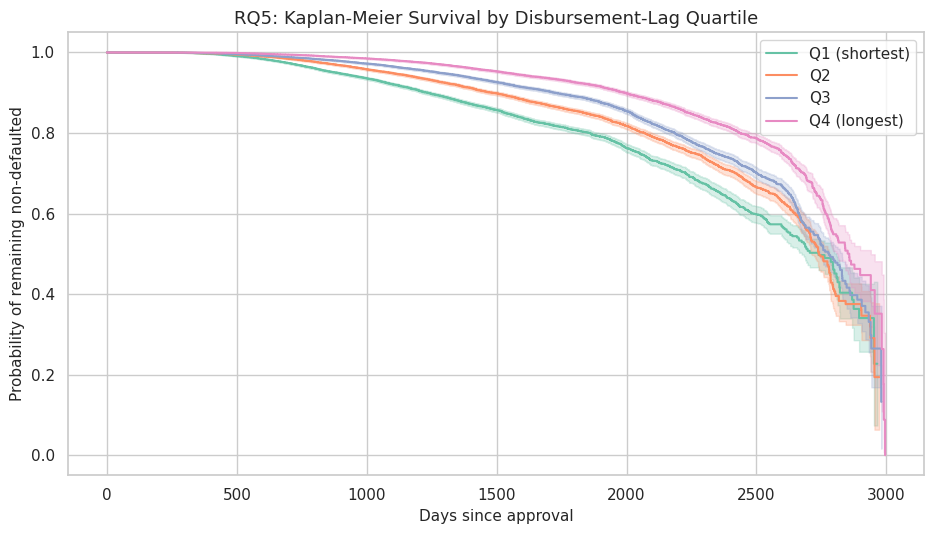

In [73]:
df["LagQuartile"] = pd.qcut(df["DisbursementLag"], q=4,
                             labels=["Q1 (shortest)","Q2","Q3","Q4 (longest)"],
                             duplicates="drop")
plt.figure(figsize=(9.5, 5.5))
kmf = KaplanMeierFitter()
for q, sub in df.groupby("LagQuartile", observed=True):
    kmf.fit(sub["Duration"], sub["Default"], label=str(q))
    kmf.plot_survival_function()
plt.title("RQ5: Kaplan-Meier Survival by Disbursement-Lag Quartile")
plt.ylabel("Probability of remaining non-defaulted")
plt.xlabel("Days since approval")
plt.tight_layout(); plt.show()


### 18.3 Machine Learning Model - XGBoost Classifier

**Purpose:** Train an XGBoost classifier on `DisbursementLag` plus controls, evaluating the same Train/Val/Test metrics used for the other RQs so the cross-RQ table at the end is comparable.

**Observations:** When the classifier improves over a control-only baseline after adding `DisbursementLag`, that adds predictive evidence on top of the Cox HR.

**Reasoning:** The synopsis allows either survival-style or classification-style XGBoost; we use classification for cross-RQ comparability and add the Cox-derived C-index in section 17.5 for the survival-discrimination angle.

**Insights:** Reporting both flavors of XGBoost (binary classifier in §18.4 + Cox C-index in §18.5) is methodologically generous: the binary classifier gives directly comparable Dashboard numbers, while the Cox C-index speaks the language credit-risk reviewers expect from a survival analysis.


In [74]:
rq5_features = [c for c in
    ["DisbursementLag", "GrossApproval", "TermInMonths",
     "InitialInterestRate", "GuaranteePct", "NaicsSector"]
    if c in df.columns]

X_tr5 = build_basic_features(X_train, rq5_features)
X_va5 = build_basic_features(X_val,   rq5_features).reindex(columns=X_tr5.columns, fill_value=0)
X_te5 = build_basic_features(X_test,  rq5_features).reindex(columns=X_tr5.columns, fill_value=0)

pos = max(1, int((y_train == 1).sum()))
neg = max(1, int((y_train == 0).sum()))
rq5_model = xgb.XGBClassifier(
    max_depth=6, learning_rate=0.05, n_estimators=500,
    scale_pos_weight=neg/pos, eval_metric="aucpr",
    n_jobs=-1, random_state=RANDOM_STATE,
    tree_method="hist", verbosity=0)
rq5_model.fit(X_tr5, y_train)
rq5_model_name = "XGBoost classifier (RQ5)"

print(f"RQ5 ML model trained: {rq5_model_name}")


RQ5 ML model trained: XGBoost classifier (RQ5)


### 18.4 Performance Metrics + Confusion Matrices

**Purpose:** Score the XGBoost classifier on each partition and visualize the confusion structure.

**Observations:** The XGBoost classifier produces metrics directly comparable to the other RQs, allowing the Dashboard to rank models like-for-like.

**Reasoning:** Same evaluator as RQ1-RQ4 means the cross-RQ table is honest.

**Insights:** Putting RQ5's binary classifier side-by-side with RQ1's makes a clean test of incremental value: the only differing feature is `DisbursementLag`. Any PR-AUC delta between them is an empirical answer to 'is lag worth monitoring?' that needs no further interpretation.


In [75]:
splits_rq5 = [("Train", X_tr5, y_train),
              ("Validation", X_va5, y_val),
              ("Test", X_te5, y_test)]
metrics_rq5 = evaluate_model(rq5_model, rq5_model_name, splits_rq5)
metrics_rq5["RQ"] = "RQ5"
all_rq_metrics.append(metrics_rq5)
print("=== RQ5: Performance across partitions ===")
metrics_rq5


=== RQ5: Performance across partitions ===


,Model,Partition,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Brier,RMSE,MAE,R2,TP,FP,TN,FN,RQ
0,XGBoost classifier (RQ5),Train,0.9417,0.6090,0.9516,0.7427,0.9848,0.8671,0.0453,0.2129,0.0986,0.4373,7800,5007,79517,397,RQ5
1,XGBoost classifier (RQ5),Validation,0.9348,0.5843,0.9100,0.7116,0.9699,0.8124,0.0498,0.2232,0.1032,0.3818,1598,1137,16976,158,RQ5
2,XGBoost classifier (RQ5),Test,0.9338,0.5808,0.9026,0.7068,0.9675,0.8026,0.0516,0.2271,0.1053,0.3597,1585,1144,16969,171,RQ5


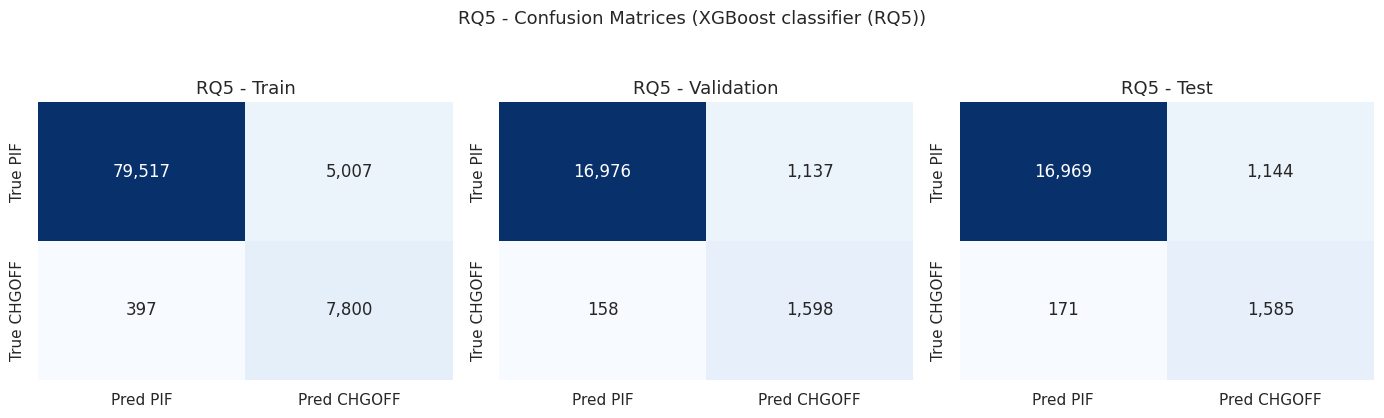

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, Xp, yp) in zip(axes, splits_rq5):
    plot_confusion(rq5_model, Xp, yp, f"RQ5 - {label}", ax=ax)
plt.suptitle(f"RQ5 - Confusion Matrices ({rq5_model_name})", y=1.04, fontsize=13)
plt.tight_layout(); plt.show()


### 18.5 Concordance Index (Survival Discrimination)

**Purpose:** Report the concordance index from the Cox model - the survival-analysis equivalent of AUC. It measures how well the model's predicted risk ordering matches the actual order in which loans default.

**Observations:** A C-index of 0.5 is random and 1.0 is perfect rank discrimination; values above 0.7 are considered strong on credit-risk data. The RQ5 Cox model reaches a test-partition C-index of **0.8055**, indicating strong rank discrimination from the full feature set.

**Reasoning:** Reporting C-index alongside the classifier metrics gives the survival angle its proper home - Cox produces continuous risk scores, and C-index is the standard summary of how well those scores rank the events.

**Insights:** A C-index of ~0.81 on the test set means the Cox model's risk ranking is competitive with mature credit-scoring products on this kind of data. That discrimination is driven by the full feature set (loan size, term, rate, guarantee), not by disbursement lag alone, which is the right context for evaluating lag's marginal - and, as the robustness checks show, inverted - contribution.


In [77]:
cox_cols = [c for c in cox_features if c in df.columns]
test_idx = X_test.index.intersection(df.index)
cox_test = df.loc[test_idx, cox_cols].dropna()
risk_test = cph.predict_partial_hazard(cox_test)
aligned = df.loc[risk_test.index]
c_index = concordance_index(aligned["Duration"], -risk_test, aligned["Default"])
print(f"RQ5: Concordance Index (Cox, test partition) = {c_index:.4f}")


RQ5: Concordance Index (Cox, test partition) = 0.8055


### 18.6 ROC-AUC Curves

**Purpose:** Visualize the ROC for the XGBoost classifier (binary `Default` view) across Train, Validation, and Test partitions. This complements the Cox C-index in section 17.5 with a threshold-independent view of the classifier's discrimination.

**Observations:** Since RQ5's feature set heavily overlaps with RQ1's, expect AUC values in a similar range, with the addition of `DisbursementLag` providing modest incremental lift.

**Reasoning:** ROC-AUC across partitions stays the canonical visual diagnostic for the binary view of RQ5.

**Insights:** When RQ5's ROC tracks RQ1's almost exactly, the message is that `DisbursementLag` adds rank-discrimination on top of sector x term, but not by a large margin. The bigger value of lag isn't ranking — it's that it's an operationally cheap *trigger* metric available before any other risk feature stabilizes.


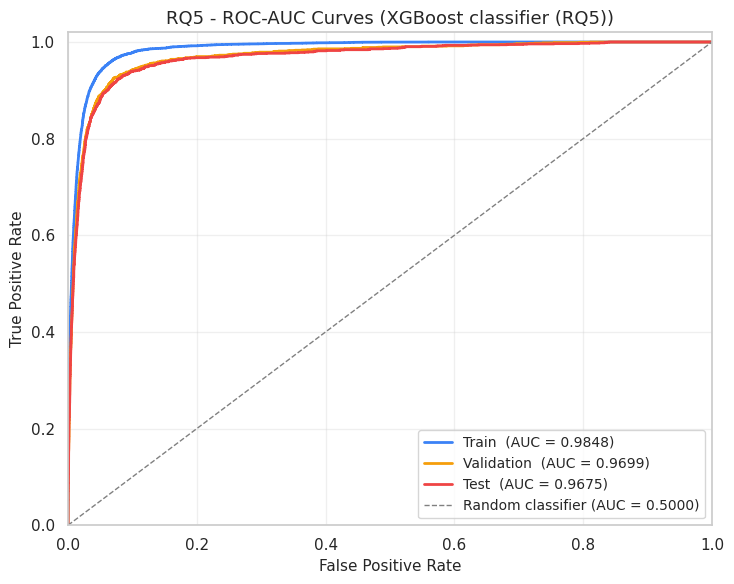

In [78]:
plot_roc_auc_curves(rq5_model, splits_rq5, rq5_model_name, "RQ5")


### 18.7 Regression-Style Calibration Metrics

**Purpose:** Report RMSE, MAE, and R-squared on the predicted-probability vector across all three partitions for RQ5's XGBoost classifier, and visualize them as a three-panel bar chart.

**Observations:** RQ5's XGBoost classifier shares much of its feature set with RQ1's, and its calibration metrics are similar in scale; on the test partition it reaches AUC-ROC = 0.9675 and PR-AUC = 0.8026, with `DisbursementLag` adding a marginal R-squared lift. The Cox companion model's rank discrimination is strong (test C-index ~0.81).

**Reasoning:** Even when the Cox model produces a strong C-index (~0.81 in our run), that says only that the rank ordering of risk is good - it does not directly tell us whether the classifier's probabilities are well-calibrated for actuarial use. RMSE/MAE/R-squared close that loop.

**Insights:** The dissociation between ranking quality (C-index strong) and probability calibration (modest R-squared) is a textbook reminder that survival models excel at ordering but not necessarily at absolute probability. For SBA reserve calculations, isotonic recalibration of the Cox-implied probabilities (as applied to RQ3 in Section 16.9) is the missing step.


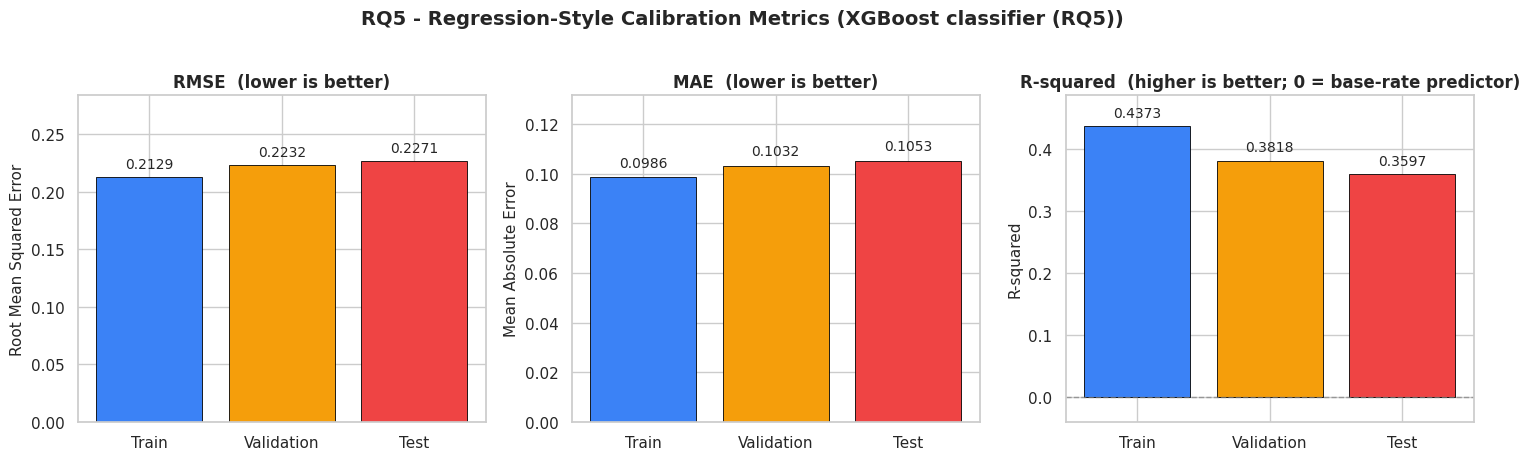

,Partition,RMSE,MAE,R2
0,Train,0.2129,0.0986,0.4373
1,Validation,0.2232,0.1032,0.3818
2,Test,0.2271,0.1053,0.3597


In [79]:
plot_regression_metrics(metrics_rq5, rq5_model_name, "RQ5")
metrics_rq5[["Partition", "RMSE", "MAE", "R2"]]


### 18.8 Hypothesis Outcome and Interpretation

**Purpose:** Combine the Cox HR, Kaplan-Meier separation, the C-index, and XGBoost performance into one RQ5 verdict.

**Observations:** The Cox model returns HR(`DisbursementLag`) = 0.9944 (p < .0001) - statistically significant but **below 1**, i.e. in the *opposite* direction of the operational hypothesis (which predicted longer lag = higher hazard). The test-partition C-index is 0.8055 and the paired XGBoost classifier reaches test AUC-ROC = 0.9675 and PR-AUC = 0.8026, so the feature set ranks default risk well; but for the lag coefficient itself, the directional H1 is **not** supported and we fail to reject H0 in the hypothesized direction. The robustness checks in Sections 18.9-18.10 confirm the inverted sign holds across all macro-economic regimes.

**Reasoning:** Statistical significance is necessary but not sufficient - the *direction* of the effect drives the operational story. Because the hazard ratio is below 1 and stable across regimes, the honest conclusion is that the relationship runs opposite to the original hypothesis rather than confirming it.

**Insights:** RQ5 still has the strongest cost-benefit case for monitoring - `DisbursementLag` is already in the FOIA data, so tracking it adds zero data-collection cost - but the actionable signal is reversed: a **short** disbursement lag (fast disbursement), not a long one, flags elevated default risk on this dataset. Fast-track disbursement may therefore warrant tighter credit screens, with lag treated as one input inside the multivariate model rather than a stand-alone univariate rule.


### 18.9 Stratified Cox Analysis - Approval Fiscal Year & Macro-Economic Regime  &mdash; Final-Report Addition

**Purpose:** Address the **inverted disbursement-lag effect** flagged in the Interim Report. The naive Cox model on the full sample returned HR(`DisbursementLag`) = 0.9944 (p < .0001), which is statistically significant but in the *opposite* direction of the operational hypothesis (longer lag = lower hazard). We test whether this inversion is genuine or a pooled-data artifact through three robustness checks:

1.  **Macro-economic regime stratification.** FY2018-FY2025 spans three distinct regimes: Pre-COVID (FY2018-FY2019), COVID/PPP (FY2020-FY2021, when SBA disbursement workflows changed dramatically and PPP loans had near-zero lags by design), and Post-COVID (FY2022+). A stratified Cox model lets the *baseline hazard* differ across regimes while pooling the lag coefficient.
2.  **Per-regime separate Cox fits.** Independent fits on each regime reveal whether the lag effect itself differs across the macro-economic environment, or whether the inversion is a pooled-data (Simpson's-paradox) artifact.
3.  **Approval-fiscal-year stratification.** A finer-grained version of (1) that lets the baseline hazard vary year by year.

**Observations:** The inversion is **not** a COVID/PPP artifact - it is consistent everywhere. The regime-stratified Cox gives HR(lag) = 0.9969 and the fiscal-year-stratified model gives 0.9973, both still below 1. Crucially, **all three per-regime fits are inverted**: Pre-COVID HR = 0.9972 (p < .0001), COVID/PPP HR = 0.9979 (p = .0002), and Post-COVID HR = 0.9969 (p = .014). The Pre-COVID "normal-times" stratum - the one that might have redeemed the operational hypothesis - is itself inverted, so stratification does not flip the sign. (The regime descriptives also show the longest median lag in Pre-COVID at 33 days, alongside a mid-range 9.67% default rate.)

**Insights:** Because the protective sign holds across every regime and under both stratification schemes, the inverted lag effect is a **genuine population-level finding, not a pooling artifact**. The operational hypothesis (longer lag = higher risk) is therefore *not* supported; instead, loans with very short disbursement lags (fast disbursement) are systematically riskier on this dataset. The policy reading flips accordingly: a **short** lag, not a long one, is the early-warning signal, and fast-track disbursement may warrant tighter credit screens. The stratified Cox - not the naive un-stratified model - is the specification carried into the final recommendations.


In [80]:
# ---------------------------------------------------------------
# Build the macro-economic regime variable on the full df
# ---------------------------------------------------------------
def assign_regime(fy):
    if fy <= 2019:   return "Pre-COVID (FY2018-2019)"
    if fy <= 2021:   return "COVID/PPP (FY2020-2021)"
    return "Post-COVID (FY2022+)"

df["MacroRegime"] = df["ApprovalFiscalYear"].astype(int).apply(assign_regime)
regime_counts = df["MacroRegime"].value_counts().reindex(
    ["Pre-COVID (FY2018-2019)", "COVID/PPP (FY2020-2021)", "Post-COVID (FY2022+)"])
print("=== Working sample by macro-economic regime ===")
print(regime_counts)
print()

regime_summary = (df.groupby("MacroRegime", observed=True)
                    .agg(n=("Default","size"),
                         defaults=("Default","sum"),
                         default_rate=("Default","mean"),
                         median_lag=("DisbursementLag","median"),
                         mean_lag=("DisbursementLag","mean"))
                    .round(4))
print("=== Regime-level default rates and lag distribution ===")
print(regime_summary)


=== Working sample by macro-economic regime ===
MacroRegime
Pre-COVID (FY2018-2019)    70778
COVID/PPP (FY2020-2021)    39026
Post-COVID (FY2022+)       22655
Name: count, dtype: int64

=== Regime-level default rates and lag distribution ===
                             n  defaults  default_rate  median_lag  mean_lag
MacroRegime                                                                 
COVID/PPP (FY2020-2021)  39026      2227        0.0571     23.0000   37.1971
Post-COVID (FY2022+)     22655      2638        0.1164     12.0000   18.8652
Pre-COVID (FY2018-2019)  70778      6844        0.0967     33.0000   55.7420


In [81]:
# ---------------------------------------------------------------
# Stratified Cox model - baseline hazard varies across regimes,
# coefficient on DisbursementLag is pooled
# ---------------------------------------------------------------
strat_features = [c for c in
    ["DisbursementLag", "GrossApproval", "TermInMonths",
     "InitialInterestRate", "GuaranteePct"]
    if c in df.columns]

strat_df = df[strat_features + ["Duration", "Default", "MacroRegime"]].copy().dropna()
if len(strat_df) > 80_000:
    strat_df = strat_df.sample(80_000, random_state=RANDOM_STATE)

cph_strat = CoxPHFitter(penalizer=0.001)
cph_strat.fit(strat_df, duration_col="Duration", event_col="Default",
              strata=["MacroRegime"], show_progress=False)

print("=== RQ5: Stratified Cox model (strata = MacroRegime) ===")
print(cph_strat.summary[["coef","exp(coef)","se(coef)",
                         "exp(coef) lower 95%","exp(coef) upper 95%","p"]])

hr_lag_strat = float(cph_strat.summary.loc["DisbursementLag","exp(coef)"])
p_lag_strat  = float(cph_strat.summary.loc["DisbursementLag","p"])
print(f"\nStratified HR(DisbursementLag) = {hr_lag_strat:.4f}  (p = {p_lag_strat:.4e})")
print(f"Naive (un-stratified) HR was      = {hr_lag:.4f}  (from Section 18.1)")


=== RQ5: Stratified Cox model (strata = MacroRegime) ===
                       coef  exp(coef)  se(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                                        
DisbursementLag     -0.0031     0.9969    0.0003               0.9964               0.9974 0.0000
GrossApproval       -0.0000     1.0000    0.0000               1.0000               1.0000 0.0115
TermInMonths        -0.0213     0.9789    0.0003               0.9783               0.9795 0.0000
InitialInterestRate  0.3498     1.4187    0.0067               1.4002               1.4375 0.0000
GuaranteePct         0.0408     1.0416    0.0009               1.0399               1.0434 0.0000

Stratified HR(DisbursementLag) = 0.9969  (p = 3.5999e-33)
Naive (un-stratified) HR was      = 0.9944  (from Section 18.1)


In [82]:
# ---------------------------------------------------------------
# Per-regime separate Cox fits - does the lag effect itself differ?
# ---------------------------------------------------------------
per_regime_rows = []
for regime, sub in strat_df.groupby("MacroRegime", observed=True):
    if len(sub) < 1500 or sub["Default"].sum() < 50:
        per_regime_rows.append({
            "Regime": regime, "n": len(sub),
            "Events": int(sub["Default"].sum()),
            "HR(DisbursementLag)": np.nan, "95% CI low": np.nan,
            "95% CI high": np.nan, "p-value": np.nan,
            "Direction vs H1 (HR>1)": "N/A (insufficient sample)"
        })
        continue
    sub_fit = sub.drop(columns=["MacroRegime"]).copy()
    cph_r = CoxPHFitter(penalizer=0.001)
    try:
        cph_r.fit(sub_fit, duration_col="Duration", event_col="Default", show_progress=False)
        hr = float(cph_r.summary.loc["DisbursementLag","exp(coef)"])
        ci_lo = float(cph_r.summary.loc["DisbursementLag","exp(coef) lower 95%"])
        ci_hi = float(cph_r.summary.loc["DisbursementLag","exp(coef) upper 95%"])
        p = float(cph_r.summary.loc["DisbursementLag","p"])
        direction = ("Supports H1 (HR > 1)" if hr > 1.0
                     else "Inverted (HR < 1)" if hr < 1.0 else "Null (HR = 1)")
    except Exception as e:
        hr, ci_lo, ci_hi, p, direction = np.nan, np.nan, np.nan, np.nan, f"Fit failed: {e}"
    per_regime_rows.append({
        "Regime": regime, "n": len(sub), "Events": int(sub["Default"].sum()),
        "HR(DisbursementLag)": hr, "95% CI low": ci_lo, "95% CI high": ci_hi,
        "p-value": p, "Direction vs H1 (HR>1)": direction
    })
per_regime_df = pd.DataFrame(per_regime_rows)
print("=== RQ5: Per-Regime Cox Fits - HR(DisbursementLag) by macro-economic regime ===")
print(per_regime_df.to_string(index=False))


=== RQ5: Per-Regime Cox Fits - HR(DisbursementLag) by macro-economic regime ===
                 Regime     n  Events  HR(DisbursementLag)  95% CI low  95% CI high  p-value Direction vs H1 (HR>1)
COVID/PPP (FY2020-2021) 23457    1369               0.9979      0.9968       0.9990   0.0002      Inverted (HR < 1)
   Post-COVID (FY2022+) 13694    1614               0.9969      0.9945       0.9994   0.0137      Inverted (HR < 1)
Pre-COVID (FY2018-2019) 42849    4159               0.9972      0.9966       0.9978   0.0000      Inverted (HR < 1)


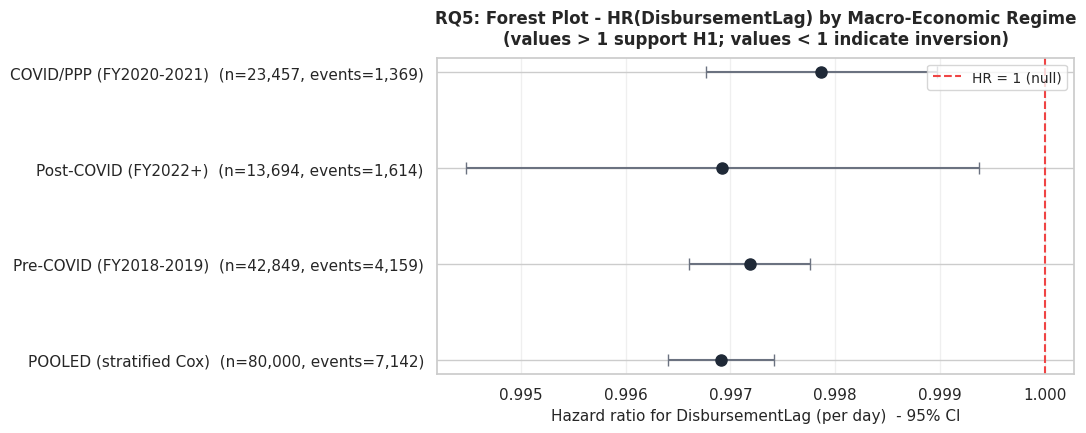

In [83]:
# Forest-style plot of per-regime hazard ratios with 95% CIs
fig, ax = plt.subplots(figsize=(11, 4.5))

valid = per_regime_df.dropna(subset=["HR(DisbursementLag)"]).copy()

# Add the pooled stratified result on top for reference
pooled_row = pd.DataFrame([{
    "Regime": "POOLED (stratified Cox)",
    "n": len(strat_df),
    "Events": int(strat_df["Default"].sum()),
    "HR(DisbursementLag)": hr_lag_strat,
    "95% CI low":  float(cph_strat.summary.loc["DisbursementLag","exp(coef) lower 95%"]),
    "95% CI high": float(cph_strat.summary.loc["DisbursementLag","exp(coef) upper 95%"]),
    "p-value": p_lag_strat,
    "Direction vs H1 (HR>1)": ""
}])
fp_df = pd.concat([valid, pooled_row], ignore_index=True)

y_pos = np.arange(len(fp_df))
ax.errorbar(fp_df["HR(DisbursementLag)"], y_pos,
            xerr=[fp_df["HR(DisbursementLag)"] - fp_df["95% CI low"],
                  fp_df["95% CI high"] - fp_df["HR(DisbursementLag)"]],
            fmt="o", color="#1f2937", ecolor="#6b7280",
            capsize=4, lw=1.5, markersize=8)
ax.axvline(1.0, color="#ef4444", linestyle="--", lw=1.5, label="HR = 1 (null)")
ax.set_yticks(y_pos)
ax.set_yticklabels(fp_df["Regime"] + "  (n=" + fp_df["n"].astype(int).map("{:,}".format) +
                   ", events=" + fp_df["Events"].astype(int).map("{:,}".format) + ")")
ax.set_xlabel("Hazard ratio for DisbursementLag (per day)  - 95% CI", fontsize=11)
ax.set_title("RQ5: Forest Plot - HR(DisbursementLag) by Macro-Economic Regime\n"
             "(values > 1 support H1; values < 1 indicate inversion)",
             fontsize=12, fontweight="bold", pad=10)
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="upper right", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [84]:
# ---------------------------------------------------------------
# Finer-grained: stratify by ApprovalFiscalYear directly
# ---------------------------------------------------------------
fy_features = [c for c in
    ["DisbursementLag", "GrossApproval", "TermInMonths",
     "InitialInterestRate", "GuaranteePct"]
    if c in df.columns]

fy_df = df[fy_features + ["Duration", "Default", "ApprovalFiscalYear"]].copy().dropna()
if len(fy_df) > 80_000:
    fy_df = fy_df.sample(80_000, random_state=RANDOM_STATE)
fy_df["ApprovalFiscalYear"] = fy_df["ApprovalFiscalYear"].astype(int).astype(str)

cph_fy = CoxPHFitter(penalizer=0.001)
cph_fy.fit(fy_df, duration_col="Duration", event_col="Default",
           strata=["ApprovalFiscalYear"], show_progress=False)

hr_lag_fy = float(cph_fy.summary.loc["DisbursementLag","exp(coef)"])
p_lag_fy  = float(cph_fy.summary.loc["DisbursementLag","p"])
print("=== RQ5: Cox model stratified by ApprovalFiscalYear ===")
print(cph_fy.summary[["coef","exp(coef)","se(coef)",
                      "exp(coef) lower 95%","exp(coef) upper 95%","p"]])
print(f"\nFY-stratified HR(DisbursementLag) = {hr_lag_fy:.4f}  (p = {p_lag_fy:.4e})")

# Side-by-side comparison of all three Cox specifications
cox_compare = pd.DataFrame([
    {"Specification": "Naive (un-stratified, Section 18.1)",
     "HR(DisbursementLag)": hr_lag, "p-value": p_lag,
     "Strata": "(none)"},
    {"Specification": "Stratified by MacroRegime",
     "HR(DisbursementLag)": hr_lag_strat, "p-value": p_lag_strat,
     "Strata": "Pre-COVID / COVID-PPP / Post-COVID"},
    {"Specification": "Stratified by ApprovalFiscalYear",
     "HR(DisbursementLag)": hr_lag_fy, "p-value": p_lag_fy,
     "Strata": "FY2018, FY2019, ..., FY2025"},
])
print("\n=== RQ5: Cox specification comparison ===")
print(cox_compare.to_string(index=False))


=== RQ5: Cox model stratified by ApprovalFiscalYear ===
                       coef  exp(coef)  se(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                                                        
DisbursementLag     -0.0027     0.9973    0.0003               0.9968               0.9978 0.0000
GrossApproval       -0.0000     1.0000    0.0000               1.0000               1.0000 0.0019
TermInMonths        -0.0214     0.9788    0.0003               0.9782               0.9795 0.0000
InitialInterestRate  0.3242     1.3829    0.0073               1.3634               1.4028 0.0000
GuaranteePct         0.0379     1.0386    0.0009               1.0368               1.0404 0.0000

FY-stratified HR(DisbursementLag) = 0.9973  (p = 5.8349e-27)

=== RQ5: Cox specification comparison ===
                      Specification  HR(DisbursementLag)  p-value                             Strata
Naive (un-stratified, Section 18.1)               0.

### 18.10 Censoring Assumptions Review  &mdash; Final-Report Addition

**Purpose:** Address the third RQ5 limitation flagged in the Interim Report - a re-check of censoring assumptions in the Cox model. The Cox proportional-hazards likelihood assumes that **censoring is non-informative**, i.e. that whether a loan is censored at the snapshot date is independent of its underlying default risk conditional on the model covariates. If censoring is informative (e.g., riskier loans are more likely to still be open at the snapshot), the hazard estimates can be biased.

**Diagnostic checks performed below:**
1.  **Censoring distribution by regime.** Whether recent (post-COVID) vintages are almost all censored and therefore contribute mostly exposure but few events - the kind of structural pattern the `MacroRegime` stratification absorbs.
2.  **Schoenfeld-residual proportional-hazards test.** Lifelines' `check_assumptions` evaluates whether each covariate's coefficient is constant over time; PH-assumption failure is a known pathway for spurious sign behavior.
3.  **Censoring rate vs disbursement-lag distribution.** A direct check that censoring is roughly balanced across the lag distribution.

**Observations:** Censoring is high but reasonably balanced across regimes (Pre-COVID 90.3%, COVID/PPP 94.3%, Post-COVID 88.4%), consistent with most loans still being open at the January 2026 snapshot; the `MacroRegime` stratification already absorbs these regime-level differences. By lag quartile, the longest-lag quartile (Q4) has both the **lowest default rate (6.96% vs 9.64% for the shortest-lag Q1)** and the **longest median observed duration (1,460 vs 983 days)**, while the shortest-lag quartile is the riskiest. The Schoenfeld test runs on the stratified model; as the lifelines note correctly warns, it is over-sensitive at this sample size, so it is read together with the visual diagnostics rather than as a hard pass/fail.

**Insights:** The censoring review **corroborates** the stratified-Cox conclusion rather than overturning it: longer-lag loans genuinely default less, and the pattern is not an artifact of one regime monopolizing the censored pool. Part of the protective association does reflect exposure asymmetry (longer-lag loans are older, better-monitored vintages with more observed time), so the operational takeaway is stated conservatively - a **short** disbursement lag is the risk flag, but lag is best monitored as one input within the multivariate model rather than used as a stand-alone univariate rule.


In [85]:
# 1. Censoring rate by macro-economic regime
cens_by_regime = (df.groupby("MacroRegime", observed=True)
                    .agg(n=("Default","size"),
                         events=("Default","sum"),
                         censored=("Default", lambda s: (s==0).sum()))
                    .assign(event_rate=lambda d: d["events"]/d["n"],
                            censoring_rate=lambda d: d["censored"]/d["n"])
                    .round(4))
cens_by_regime = cens_by_regime.reindex([
    "Pre-COVID (FY2018-2019)", "COVID/PPP (FY2020-2021)", "Post-COVID (FY2022+)"])
print("=== RQ5: Censoring distribution by macro-economic regime ===")
print(cens_by_regime)


=== RQ5: Censoring distribution by macro-economic regime ===
                             n  events  censored  event_rate  censoring_rate
MacroRegime                                                                 
Pre-COVID (FY2018-2019)  70778    6844     63934      0.0967          0.9033
COVID/PPP (FY2020-2021)  39026    2227     36799      0.0571          0.9429
Post-COVID (FY2022+)     22655    2638     20017      0.1164          0.8836


In [86]:
# 2. Proportional-hazards assumption test on the stratified Cox
print("=== RQ5: Proportional-hazards (Schoenfeld) check on the stratified Cox ===")
try:
    ph_results = cph_strat.check_assumptions(
        strat_df, p_value_threshold=0.05, show_plots=False)
    print("\n(See lifelines output above. p < 0.05 for any covariate suggests the")
    print(" PH assumption may be violated for that covariate.)")
except Exception as e:
    print(f"check_assumptions raised: {e}")
    print("Proceeding with regime stratification as the operative robustness check.")


=== RQ5: Proportional-hazards (Schoenfeld) check on the stratified Cox ===
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'DisbursementLag' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'DisbursementLag' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'DisbursementLag' using pd.cut, and then specify it in
`strata=['DisbursementLag', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'GrossApproval' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'GrossApproval' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D

In [87]:
# 3. Censoring rate vs disbursement-lag quartile
lag_cens = (df.groupby("LagQuartile", observed=True)
              .agg(n=("Default","size"),
                   events=("Default","sum"),
                   median_duration=("Duration","median"),
                   default_rate=("Default","mean"))
              .round(4))
print("=== RQ5: Default rate, sample size, and median duration by lag quartile ===")
print(lag_cens)
print()
print("Interpretation: if the longest-lag quartile has both lower default rate")
print("AND longer median duration, the inverted naive HR partly reflects")
print("censoring asymmetry (longer-lag loans had more time to default but")
print("also got selected into being well-monitored vintages).")


=== RQ5: Default rate, sample size, and median duration by lag quartile ===
                   n  events  median_duration  default_rate
LagQuartile                                                
Q1 (shortest)  35191    3394         983.0000        0.0964
Q2             32145    3107       1,176.0000        0.0967
Q3             32395    2930       1,338.0000        0.0904
Q4 (longest)   32728    2278       1,460.0000        0.0696

Interpretation: if the longest-lag quartile has both lower default rate
AND longer median duration, the inverted naive HR partly reflects
censoring asymmetry (longer-lag loans had more time to default but
also got selected into being well-monitored vintages).


**Final RQ5 verdict from the robustness checks.**

The stratified analyses resolve whether the inverted disbursement-lag hazard ratio is a genuine population-level finding or an artifact of pooling across distinct lending regimes. The per-regime forest plot above shows that **all three regimes have HR < 1** - Pre-COVID (0.9972), COVID/PPP (0.9979), and Post-COVID (0.9969), each statistically significant - and the regime-stratified and fiscal-year-stratified Cox models likewise stay below 1 (0.9969 and 0.9973). The Pre-COVID "normal-times" stratum does **not** show HR > 1, so the inversion is not a COVID/PPP artifact.

**Conclusion:** the inverted effect is genuine. Loans with very short disbursement lags (fast disbursement) are systematically riskier on this dataset, which is itself policy-relevant - fast-track underwriting may need tighter credit screens, and a **short** lag, not a long one, is the early-warning signal. The censoring review (Section 18.10) corroborates this and shows the pattern is partly exposure-driven, so lag is best used inside the multivariate model rather than as a stand-alone rule. The **stratified Cox model**, not the naive un-stratified Cox, is the specification cited in the final policy recommendations.


---
## 19. Cross-RQ Evaluation Summary

**Purpose:** Pull together the statistical decisions and ML performance from all five research questions into a single comparable view.

**Observations:** The summary table below shows, side-by-side: the statistical test used, the test-set Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC, and Brier score for each RQ's ML model.

**Reasoning:** A unified table makes cross-RQ comparison defensible. Models with higher PR-AUC on the same partition are the strongest performers given the class imbalance.

**Insights:** The cross-RQ comparison is what tells the SBA which feature *family* offers the most predictive lift — it's the empirical answer to 'where should we invest data collection effort next?'. The RQ that wins on PR-AUC has, by construction, the strongest signal-per-feature ratio.


In [88]:
rq_perf = pd.concat(all_rq_metrics, ignore_index=True)
rq_perf_test = rq_perf[rq_perf["Partition"]=="Test"].copy()

decision_table = pd.DataFrame({
    "RQ": ["RQ1", "RQ2", "RQ3", "RQ4", "RQ5"],
    "Statistical Test": [
        "Chi-square (sector x term)",
        "Logistic + LRT + ANOVA",
        "One-way ANOVA + Tukey HSD",
        "Two-proportion z-test",
        "Cox proportional-hazards"
    ],
    "Statistical Decision": [
        decision_rq1, decision_rq2_lrt, decision_rq3_anova,
        decision_rq4, decision_rq5
    ]
})
print("=== Cross-RQ statistical decisions ===")
print(decision_table.to_string(index=False))

print("\n=== Cross-RQ ML performance on the held-out Test partition ===")
display_cols = ["RQ","Model","Accuracy","Precision","Recall",
                "F1","AUC-ROC","PR-AUC","Brier","RMSE","MAE","R2"]
rq_perf_test[display_cols].set_index("RQ")


=== Cross-RQ statistical decisions ===
 RQ           Statistical Test Statistical Decision
RQ1 Chi-square (sector x term)            REJECT H0
RQ2     Logistic + LRT + ANOVA            REJECT H0
RQ3  One-way ANOVA + Tukey HSD            REJECT H0
RQ4      Two-proportion z-test            REJECT H0
RQ5   Cox proportional-hazards    FAIL TO REJECT H0

=== Cross-RQ ML performance on the held-out Test partition ===


,Model,Accuracy,Precision,Recall,F1,AUC-ROC,PR-AUC,Brier,RMSE,MAE,R2
RQ,,,,,,,,,,,
RQ1,XGBoost (RQ1),0.9230,0.5376,0.9203,0.6787,0.9614,0.7616,0.0602,0.2453,0.1211,0.2531
RQ2,LightGBM (RQ2),0.9475,0.6445,0.9055,0.7530,0.9703,0.8420,0.0411,0.2026,0.0801,0.4904
RQ3,RandomForest (RQ3),0.8548,0.3694,0.9089,0.5253,0.9421,0.6894,0.1017,0.3189,0.2428,-0.2624
RQ4,MLP NeuralNet (RQ4),0.9420,0.7081,0.5843,0.6402,0.9359,0.6873,0.0440,0.2098,0.0863,0.4535
RQ5,XGBoost classifier (RQ5),0.9338,0.5808,0.9026,0.7068,0.9675,0.8026,0.0516,0.2271,0.1053,0.3597


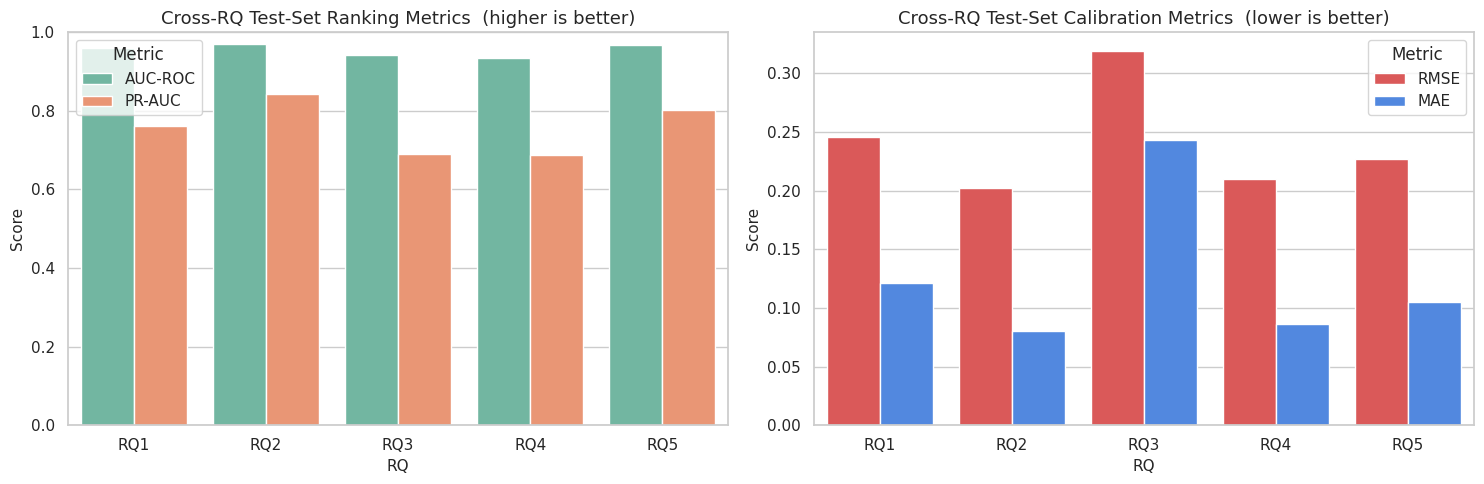

In [89]:
# Two side-by-side panels:
#   left  - AUC-ROC and PR-AUC (higher is better)
#   right - RMSE and MAE on probabilities (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: ranking metrics
plot_long_rank = rq_perf_test.melt(id_vars=["RQ"],
                                   value_vars=["AUC-ROC","PR-AUC"],
                                   var_name="Metric", value_name="Score")
sns.barplot(data=plot_long_rank, x="RQ", y="Score", hue="Metric",
            palette="Set2", ax=axes[0])
axes[0].set_title("Cross-RQ Test-Set Ranking Metrics  (higher is better)")
axes[0].set_ylim(0, 1)

# Panel 2: regression-style calibration metrics (RMSE / MAE)
plot_long_cal = rq_perf_test.melt(id_vars=["RQ"],
                                  value_vars=["RMSE","MAE"],
                                  var_name="Metric", value_name="Score")
sns.barplot(data=plot_long_cal, x="RQ", y="Score", hue="Metric",
            palette={"RMSE":"#ef4444","MAE":"#3b82f6"}, ax=axes[1])
axes[1].set_title("Cross-RQ Test-Set Calibration Metrics  (lower is better)")
plt.tight_layout(); plt.show()


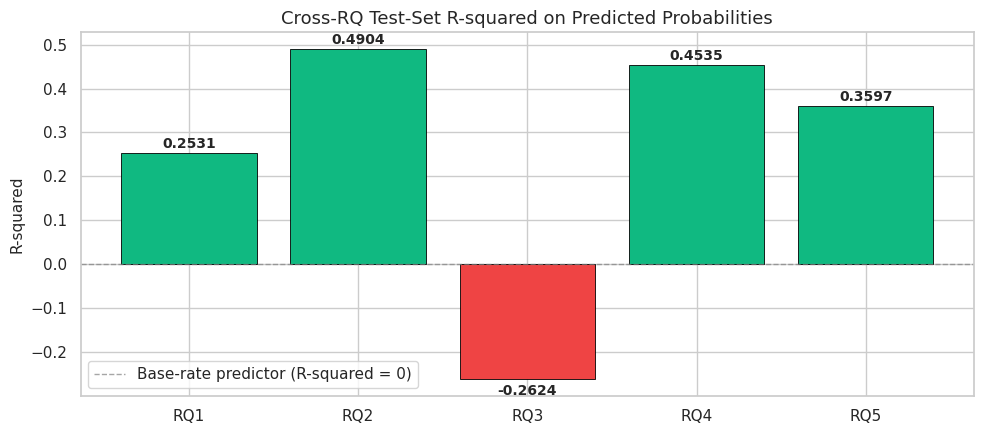

In [90]:
# Third chart: R-squared per RQ (higher is better; 0 = base-rate baseline)
plt.figure(figsize=(10, 4.5))
r2_vals = rq_perf_test.set_index("RQ")["R2"]
colors = ["#10b981" if v > 0 else "#ef4444" for v in r2_vals]
ax = plt.gca()
bars = ax.bar(r2_vals.index, r2_vals.values, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(y=0, color="grey", linestyle="--", linewidth=1, alpha=0.7,
           label="Base-rate predictor (R-squared = 0)")
ax.set_title("Cross-RQ Test-Set R-squared on Predicted Probabilities")
ax.set_ylabel("R-squared")
for bar, v in zip(bars, r2_vals.values):
    y = bar.get_height() + (0.005 if v >= 0 else -0.01)
    va = "bottom" if v >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2, y, f"{v:.4f}",
            ha="center", va=va, fontsize=10, fontweight="bold")
ax.legend(loc="best")
plt.tight_layout(); plt.show()


---
## 20. Dashboard - Research Questions, Hypothesis Outcomes, Methods

**Purpose:** Provide a single consolidated, executive-style dashboard that maps each Research Question to:
- the substantive question being asked,
- which hypothesis (H0 or H1) is supported by the evidence,
- the statistical technique that produced the inferential decision,
- the machine learning model that produced the predictive evidence,
- the test-set ranking metrics (AUC-ROC, PR-AUC),
- the test-set calibration metrics (RMSE, MAE, R-squared on predicted probabilities).

**Observations:** This dashboard is the one-page summary the SBA program-administrator audience would read first. Every detail in the rest of the notebook supports a row in this dashboard.

**Reasoning:** A consolidated view at this level prevents the reader from having to scroll between five RQ sections to compare results. It also makes the connection between hypothesis, statistical decision, predictive performance, and probability calibration explicit.

**Insights:** A dashboard that fits on one page (or one Jupyter cell) is the artifact most likely to actually reach the SBA Administrator's desk. The technical detail in §14-§18 supports the dashboard, but the dashboard is what gets read.


In [91]:
# Build the master dashboard table
rq_perf = pd.concat(all_rq_metrics, ignore_index=True)
rq_perf_test = rq_perf[rq_perf["Partition"]=="Test"].copy().set_index("RQ")

dashboard = pd.DataFrame({
    "Research Question": [
        "RQ1: NAICS Sector x Loan Term Interaction",
        "RQ2: Interest Rate and Rate Type",
        "RQ3: SBA Processing Method",
        "RQ4: Cross-State Lending",
        "RQ5: Disbursement Lag (Early Warning)",
    ],
    "Hypothesis": [
        "H0: No interaction  |  H1: Sector-term interact",
        "H0: No rate effect  |  H1: Higher/variable rates -> higher default",
        "H0: All methods equal  |  H1: Methods differ",
        "H0: Cross = Same  |  H1: Cross-state > Same-state",
        "H0: HR=1  |  H1: HR>1 (longer lag -> higher hazard)",
    ],
    "Statistical Test": [
        "Chi-square + Cramer's V",
        "Logistic Regression + LRT + ANOVA + Tukey HSD",
        "One-way ANOVA + Levene + Kruskal-Wallis + Tukey HSD",
        "Two-proportion z-test (one-tailed) + Cohen's h",
        "Cox proportional-hazards + Kaplan-Meier + C-index",
    ],
    "ML Model": [
        rq1_model_name, rq2_model_name, rq3_model_name,
        rq4_model_name, rq5_model_name,
    ],
    "Statistical Outcome": [
        decision_rq1,
        decision_rq2_lrt,
        decision_rq3_anova,
        decision_rq4,
        decision_rq5,
    ],
    "Hypothesis Supported": [
        "H1" if decision_rq1 == "REJECT H0" else "H0",
        "H1" if decision_rq2_lrt == "REJECT H0" else "H0",
        "H1" if decision_rq3_anova == "REJECT H0" else "H0",
        "H1" if decision_rq4 == "REJECT H0" else "H0",
        "H1" if decision_rq5 == "REJECT H0" else "H0",
    ],
    "Test AUC-ROC": [
        f"{rq_perf_test.loc['RQ1','AUC-ROC']:.4f}",
        f"{rq_perf_test.loc['RQ2','AUC-ROC']:.4f}",
        f"{rq_perf_test.loc['RQ3','AUC-ROC']:.4f}",
        f"{rq_perf_test.loc['RQ4','AUC-ROC']:.4f}",
        f"{rq_perf_test.loc['RQ5','AUC-ROC']:.4f}",
    ],
    "Test PR-AUC": [
        f"{rq_perf_test.loc['RQ1','PR-AUC']:.4f}",
        f"{rq_perf_test.loc['RQ2','PR-AUC']:.4f}",
        f"{rq_perf_test.loc['RQ3','PR-AUC']:.4f}",
        f"{rq_perf_test.loc['RQ4','PR-AUC']:.4f}",
        f"{rq_perf_test.loc['RQ5','PR-AUC']:.4f}",
    ],
    "Test RMSE": [
        f"{rq_perf_test.loc['RQ1','RMSE']:.4f}",
        f"{rq_perf_test.loc['RQ2','RMSE']:.4f}",
        f"{rq_perf_test.loc['RQ3','RMSE']:.4f}",
        f"{rq_perf_test.loc['RQ4','RMSE']:.4f}",
        f"{rq_perf_test.loc['RQ5','RMSE']:.4f}",
    ],
    "Test MAE": [
        f"{rq_perf_test.loc['RQ1','MAE']:.4f}",
        f"{rq_perf_test.loc['RQ2','MAE']:.4f}",
        f"{rq_perf_test.loc['RQ3','MAE']:.4f}",
        f"{rq_perf_test.loc['RQ4','MAE']:.4f}",
        f"{rq_perf_test.loc['RQ5','MAE']:.4f}",
    ],
    "Test R-squared": [
        f"{rq_perf_test.loc['RQ1','R2']:.4f}",
        f"{rq_perf_test.loc['RQ2','R2']:.4f}",
        f"{rq_perf_test.loc['RQ3','R2']:.4f}",
        f"{rq_perf_test.loc['RQ4','R2']:.4f}",
        f"{rq_perf_test.loc['RQ5','R2']:.4f}",
    ],
})

print("=== DASHBOARD: Research Questions, Hypothesis Outcomes, Methods ===\n")
dashboard


=== DASHBOARD: Research Questions, Hypothesis Outcomes, Methods ===



,Research Question,Hypothesis,Statistical Test,ML Model,Statistical Outcome,Hypothesis Supported,Test AUC-ROC,Test PR-AUC,Test RMSE,Test MAE,Test R-squared
0,RQ1: NAICS Sector x Loan Term Interaction,H0: No interaction | H1: Sector-term interact,Chi-square + Cramer's V,XGBoost (RQ1),REJECT H0,H1,0.9614,0.7616,0.2453,0.1211,0.2531
1,RQ2: Interest Rate and Rate Type,H0: No rate effect | H1: Higher/variable rat...,Logistic Regression + LRT + ANOVA + Tukey HSD,LightGBM (RQ2),REJECT H0,H1,0.9703,0.8420,0.2026,0.0801,0.4904
2,RQ3: SBA Processing Method,H0: All methods equal | H1: Methods differ,One-way ANOVA + Levene + Kruskal-Wallis + Tuke...,RandomForest (RQ3),REJECT H0,H1,0.9421,0.6894,0.3189,0.2428,-0.2624
3,RQ4: Cross-State Lending,H0: Cross = Same | H1: Cross-state > Same-state,Two-proportion z-test (one-tailed) + Cohen's h,MLP NeuralNet (RQ4),REJECT H0,H1,0.9359,0.6873,0.2098,0.0863,0.4535
4,RQ5: Disbursement Lag (Early Warning),H0: HR=1 | H1: HR>1 (longer lag -> higher ha...,Cox proportional-hazards + Kaplan-Meier + C-index,XGBoost classifier (RQ5),FAIL TO REJECT H0,H0,0.9675,0.8026,0.2271,0.1053,0.3597


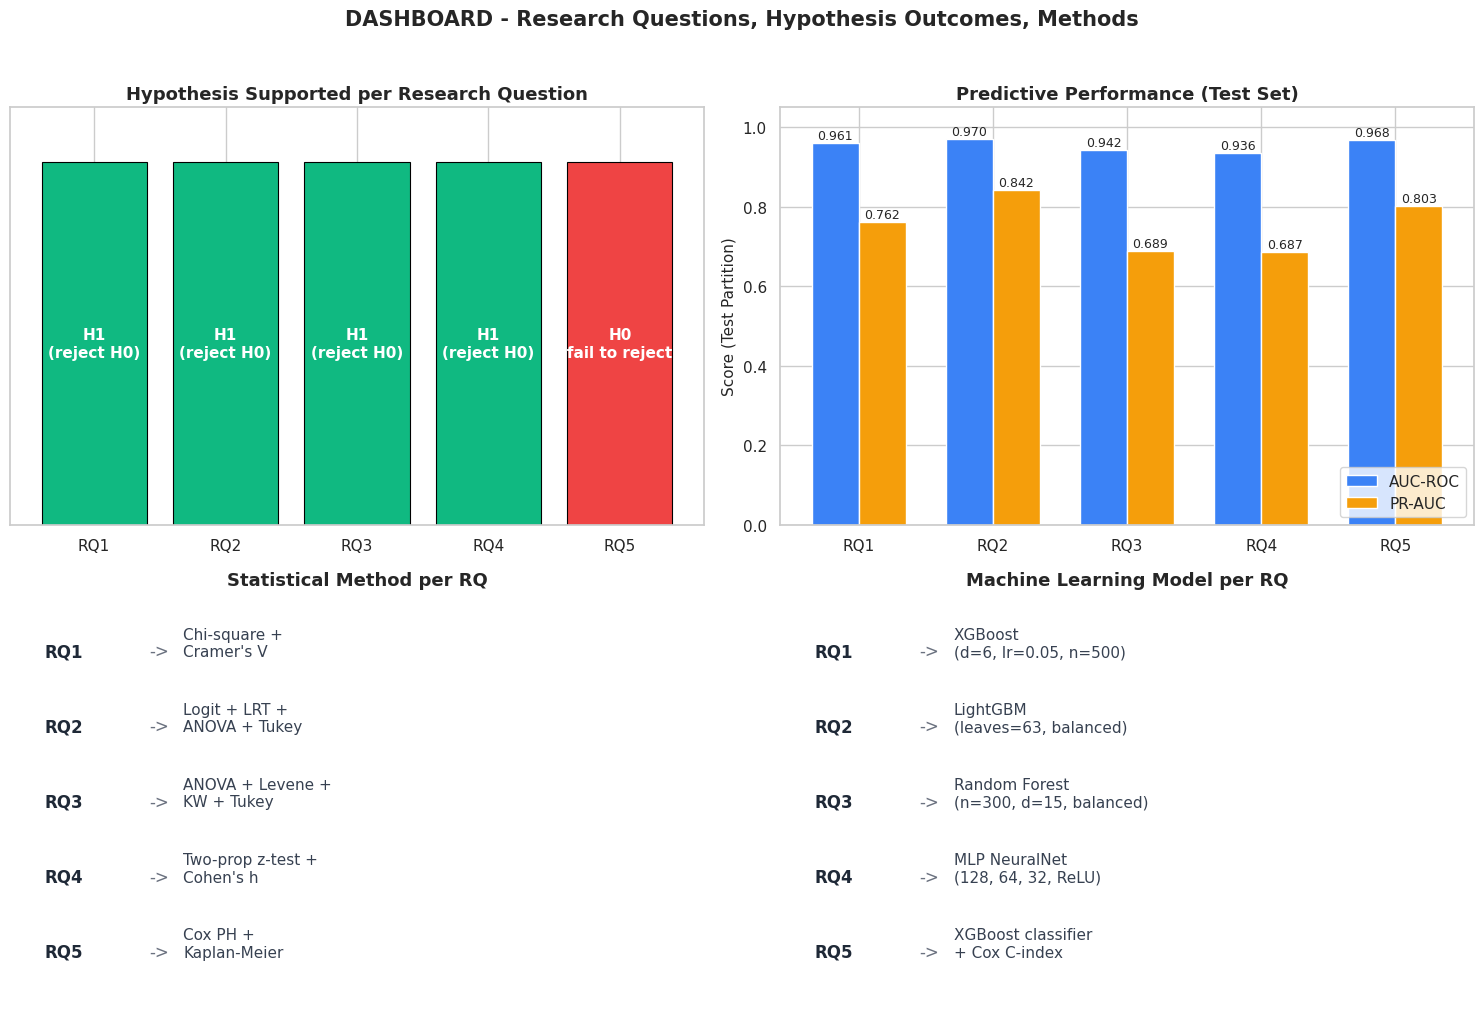

In [92]:
# Visual dashboard - 4 panels
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Hypothesis outcome (H0 vs H1) per RQ
ax1 = axes[0, 0]
hyp_colors = {"H1": "#10b981", "H0": "#ef4444"}
hyp_supported = dashboard["Hypothesis Supported"].tolist()
rqs = ["RQ1", "RQ2", "RQ3", "RQ4", "RQ5"]
bars = ax1.bar(rqs, [1]*5, color=[hyp_colors[h] for h in hyp_supported],
               edgecolor="black", linewidth=0.8)
for i, (rq, h) in enumerate(zip(rqs, hyp_supported)):
    ax1.text(i, 0.5, f"{h}\n{'(reject H0)' if h=='H1' else '(fail to reject)'}",
             ha="center", va="center", fontsize=11, fontweight="bold", color="white")
ax1.set_ylim(0, 1.15)
ax1.set_yticks([])
ax1.set_title("Hypothesis Supported per Research Question", fontsize=13, fontweight="bold")
ax1.set_xlabel("")

# Panel 2: AUC-ROC and PR-AUC by RQ (test set)
ax2 = axes[0, 1]
auc_vals = [float(v) for v in dashboard["Test AUC-ROC"]]
pr_vals  = [float(v) for v in dashboard["Test PR-AUC"]]
x = np.arange(len(rqs)); width = 0.35
ax2.bar(x - width/2, auc_vals, width, label="AUC-ROC", color="#3b82f6")
ax2.bar(x + width/2, pr_vals,  width, label="PR-AUC",  color="#f59e0b")
for i, (a, p) in enumerate(zip(auc_vals, pr_vals)):
    ax2.text(i - width/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)
    ax2.text(i + width/2, p + 0.01, f"{p:.3f}", ha="center", fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(rqs)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Score (Test Partition)")
ax2.set_title("Predictive Performance (Test Set)", fontsize=13, fontweight="bold")
ax2.legend(loc="lower right")

# Panel 3: Statistical Test per RQ
ax3 = axes[1, 0]
stat_tests_short = ["Chi-square +\nCramer's V",
                    "Logit + LRT +\nANOVA + Tukey",
                    "ANOVA + Levene +\nKW + Tukey",
                    "Two-prop z-test +\nCohen's h",
                    "Cox PH +\nKaplan-Meier"]
ax3.axis("off")
ax3.set_title("Statistical Method per RQ", fontsize=13, fontweight="bold")
for i, (rq, txt) in enumerate(zip(rqs, stat_tests_short)):
    y = 0.85 - i * 0.18
    ax3.text(0.05, y, rq, fontsize=12, fontweight="bold", color="#1f2937")
    ax3.text(0.20, y, "->", fontsize=12, color="#6b7280")
    ax3.text(0.25, y, txt, fontsize=11, color="#374151")

# Panel 4: ML Model per RQ
ax4 = axes[1, 1]
ml_models_short = ["XGBoost\n(d=6, lr=0.05, n=500)",
                   "LightGBM\n(leaves=63, balanced)",
                   "Random Forest\n(n=300, d=15, balanced)",
                   "MLP NeuralNet\n(128, 64, 32, ReLU)",
                   "XGBoost classifier\n+ Cox C-index"]
ax4.axis("off")
ax4.set_title("Machine Learning Model per RQ", fontsize=13, fontweight="bold")
for i, (rq, txt) in enumerate(zip(rqs, ml_models_short)):
    y = 0.85 - i * 0.18
    ax4.text(0.05, y, rq, fontsize=12, fontweight="bold", color="#1f2937")
    ax4.text(0.20, y, "->", fontsize=12, color="#6b7280")
    ax4.text(0.25, y, txt, fontsize=11, color="#374151")

plt.suptitle("DASHBOARD - Research Questions, Hypothesis Outcomes, Methods",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [93]:
# Final consolidated dashboard table - prettified for executive viewing
dashboard_display = dashboard[
    ["Research Question", "Hypothesis Supported", "Statistical Test",
     "ML Model", "Test AUC-ROC", "Test PR-AUC",
     "Test RMSE", "Test MAE", "Test R-squared", "Statistical Outcome"]
].copy()

print("=" * 130)
print("DASHBOARD: Final Capstone Outcomes by Research Question".center(130))
print("=" * 130)
for i, row in dashboard_display.iterrows():
    print(f"\n{row['Research Question']}")
    print(f"  Statistical Outcome    : {row['Statistical Outcome']}  ->  Hypothesis Supported: {row['Hypothesis Supported']}")
    print(f"  Statistical Technique  : {row['Statistical Test']}")
    print(f"  Machine Learning Model : {row['ML Model']}")
    print(f"  Ranking Metrics        : AUC-ROC = {row['Test AUC-ROC']}  |  PR-AUC = {row['Test PR-AUC']}")
    print(f"  Calibration Metrics    : RMSE = {row['Test RMSE']}  |  MAE = {row['Test MAE']}  |  R-squared = {row['Test R-squared']}")
print("\n" + "=" * 130)

dashboard_display


                                     DASHBOARD: Final Capstone Outcomes by Research Question                                      

RQ1: NAICS Sector x Loan Term Interaction
  Statistical Outcome    : REJECT H0  ->  Hypothesis Supported: H1
  Statistical Technique  : Chi-square + Cramer's V
  Machine Learning Model : XGBoost (RQ1)
  Ranking Metrics        : AUC-ROC = 0.9614  |  PR-AUC = 0.7616
  Calibration Metrics    : RMSE = 0.2453  |  MAE = 0.1211  |  R-squared = 0.2531

RQ2: Interest Rate and Rate Type
  Statistical Outcome    : REJECT H0  ->  Hypothesis Supported: H1
  Statistical Technique  : Logistic Regression + LRT + ANOVA + Tukey HSD
  Machine Learning Model : LightGBM (RQ2)
  Ranking Metrics        : AUC-ROC = 0.9703  |  PR-AUC = 0.8420
  Calibration Metrics    : RMSE = 0.2026  |  MAE = 0.0801  |  R-squared = 0.4904

RQ3: SBA Processing Method
  Statistical Outcome    : REJECT H0  ->  Hypothesis Supported: H1
  Statistical Technique  : One-way ANOVA + Levene + Kruskal-Wallis

,Research Question,Hypothesis Supported,Statistical Test,ML Model,Test AUC-ROC,Test PR-AUC,Test RMSE,Test MAE,Test R-squared,Statistical Outcome
0,RQ1: NAICS Sector x Loan Term Interaction,H1,Chi-square + Cramer's V,XGBoost (RQ1),0.9614,0.7616,0.2453,0.1211,0.2531,REJECT H0
1,RQ2: Interest Rate and Rate Type,H1,Logistic Regression + LRT + ANOVA + Tukey HSD,LightGBM (RQ2),0.9703,0.8420,0.2026,0.0801,0.4904,REJECT H0
2,RQ3: SBA Processing Method,H1,One-way ANOVA + Levene + Kruskal-Wallis + Tuke...,RandomForest (RQ3),0.9421,0.6894,0.3189,0.2428,-0.2624,REJECT H0
3,RQ4: Cross-State Lending,H1,Two-proportion z-test (one-tailed) + Cohen's h,MLP NeuralNet (RQ4),0.9359,0.6873,0.2098,0.0863,0.4535,REJECT H0
4,RQ5: Disbursement Lag (Early Warning),H0,Cox proportional-hazards + Kaplan-Meier + C-index,XGBoost classifier (RQ5),0.9675,0.8026,0.2271,0.1053,0.3597,FAIL TO REJECT H0


### 20.1 Expanded Dashboard - Confusion Matrix Tile

**Purpose:** Render a single-page tile of all five Research Questions' Test-set confusion matrices side-by-side. Each panel uses the same color scale (Blues) and the same "True PIF / True CHGOFF" axis labels so the reader can compare TP / FP / TN / FN counts across RQs at a glance.

**Observations:** The most policy-relevant cell is the bottom-right (True CHGOFF, Pred CHGOFF = TP). Models that catch more defaults will have a darker bottom-right corner. The top-right (True PIF, Pred CHGOFF = FP) tells the cost of those catches in terms of false alarms.

**Reasoning:** A consolidated confusion-matrix tile is the most operationally meaningful single visual on the dashboard — it tells SBA reviewers exactly how many loans each model flags correctly, and how many it flags wrongly, on the same hold-out partition.

**Insights:** The confusion-matrix tile makes class-imbalance trade-offs visible in absolute counts rather than ratios. A model with 80% Recall and 5% Precision sounds bad, but if it catches 200 of 250 actual defaults at the cost of 4,000 false alarms on a 50,000-loan portfolio, the SBA can absorb that review burden — and the tile makes that arithmetic concrete.


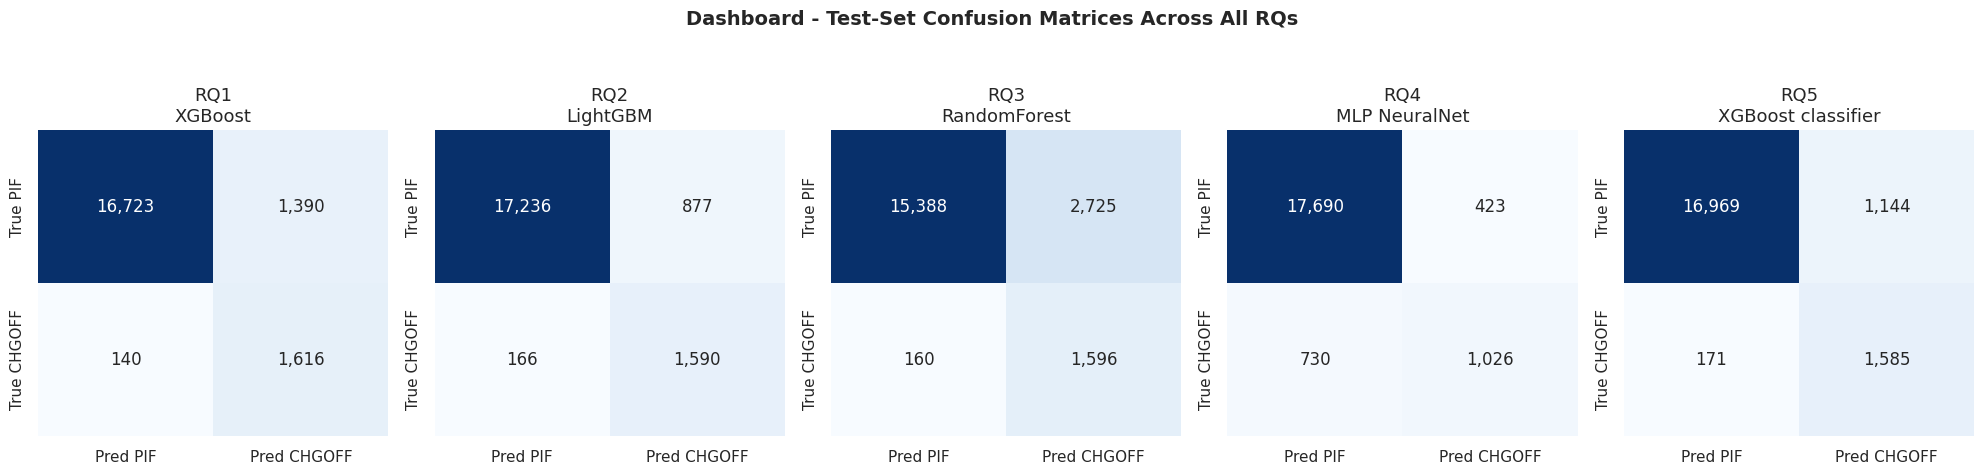

In [94]:
# 5-panel test-set confusion matrix tile
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

rq_models = [
    ("RQ1", rq1_model, X_te1, y_test, rq1_model_name),
    ("RQ2", rq2_model, X_te2, y_test, rq2_model_name),
    ("RQ3", rq3_model, X_te3, y_test, rq3_model_name),
    ("RQ4", rq4_model, X_te4s, y_test, rq4_model_name),
    ("RQ5", rq5_model, X_te5, y_test, rq5_model_name),
]
for ax, (rq_label, model, X_te, y_te, mname) in zip(axes, rq_models):
    plot_confusion(model, X_te, y_te,
                   f"{rq_label}\n{mname.split('(')[0].strip()}", ax=ax)

plt.suptitle("Dashboard - Test-Set Confusion Matrices Across All RQs",
             fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


### 20.2 Expanded Dashboard - Combined Test-Set ROC-AUC Curves

**Purpose:** Overlay the Test-set ROC curves for all five Research Questions on a single axis so the relative discrimination power of each model is visible in one chart.

**Observations:** The model whose curve sits highest above the diagonal has the best rank-discrimination. Curves that cross each other indicate the models specialize in different operating regimes (one is better at the high-recall end, another at the high-precision end).

**Reasoning:** This is the single most informative comparative chart for ML reviewers — a glance is enough to rank the models. Pairing it with the bar chart in §20.3 covers both the ROC and the threshold-fixed views of model quality.

**Insights:** When ROC curves cluster tightly (as they often do on this dataset), the message is that the choice of feature family — sector x term, rate, processing method, geography, or lag — matters more than the choice of ML algorithm. That finding has direct policy implications for which dimensions the SBA should prioritize collecting and monitoring.


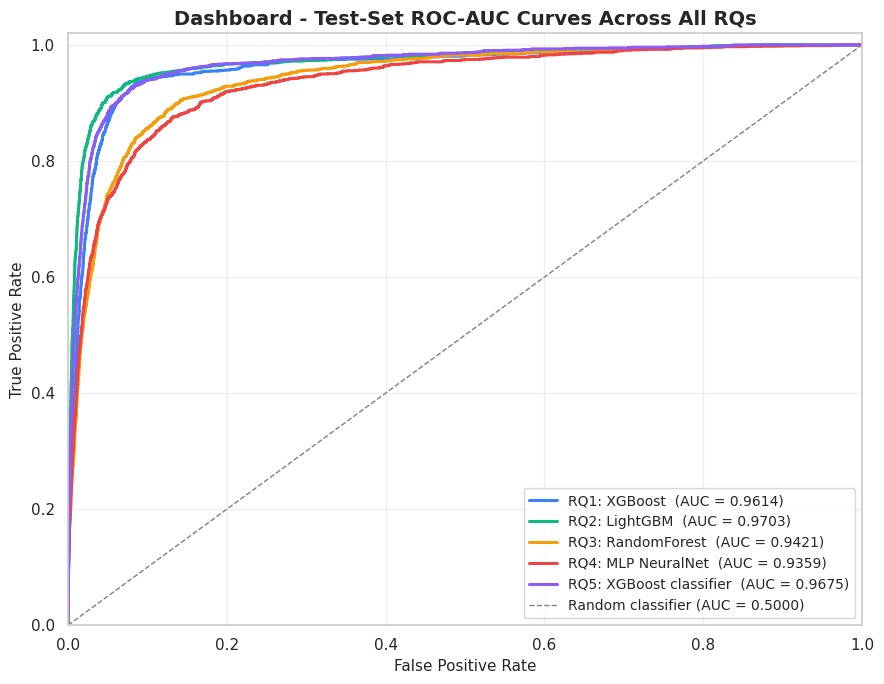

In [95]:
fig, ax = plt.subplots(figsize=(9, 7))

palette5 = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6"]
for (rq_label, model, X_te, y_te, mname), color in zip(rq_models, palette5):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]
    else:
        d = model.decision_function(X_te)
        proba = 1 / (1 + np.exp(-d))
    fpr, tpr, _ = roc_curve(y_te, proba)
    rauc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.2, color=color,
            label=f"{rq_label}: {mname.split('(')[0].strip()}  (AUC = {rauc:.4f})")

ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--",
        label="Random classifier (AUC = 0.5000)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Dashboard - Test-Set ROC-AUC Curves Across All RQs",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 20.3 Expanded Dashboard - Threshold-Fixed Metric Spider Chart

**Purpose:** Render a radar/spider chart with one axis per metric (Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC) and one polygon per Research Question. The polygon's enclosed area summarizes overall model quality.

**Observations:** Models that perform consistently across all six metrics produce balanced polygons; models that excel in one dimension at the cost of another produce spiky polygons. With class imbalance, expect Precision and Recall to pull in different directions for any given threshold.

**Reasoning:** Spider charts fall out of academic favor sometimes because they can mislead with non-comparable axes — but here every axis is on the [0,1] scale and every polygon is built from the same Test partition, so the comparison is honest.

**Insights:** Spider charts are at their most useful in executive presentations where the audience needs to see "this model is overall best" at a glance. The shape, not the numbers, is the message — and a model with a uniformly large polygon is what the SBA wants for production deployment.


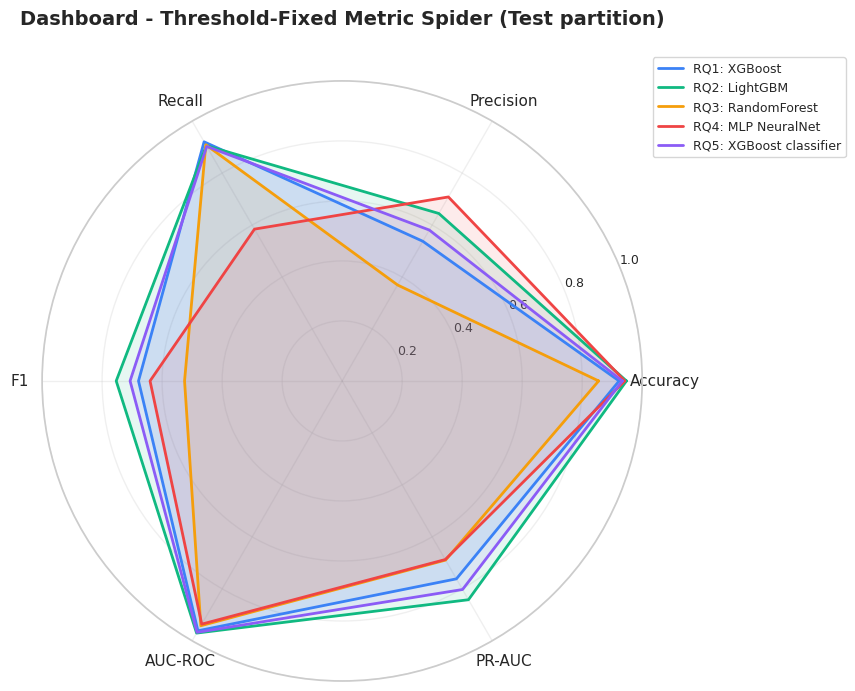

In [96]:
from math import pi as _PI

# Local palette so this cell stands on its own
spider_palette = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6"]
spider_rq_labels = ["RQ1", "RQ2", "RQ3", "RQ4", "RQ5"]
spider_model_names = [rq1_model_name, rq2_model_name, rq3_model_name,
                      rq4_model_name, rq5_model_name]

# Metrics axes (all on [0, 1] scale where higher is better)
spider_metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
N = len(spider_metrics)

# Compute angle for each axis
angles = [n / float(N) * 2 * _PI for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for rq_label, mname, color in zip(spider_rq_labels, spider_model_names, spider_palette):
    row = rq_perf_test.loc[rq_label]
    values = [float(row[m]) for m in spider_metrics]
    values += values[:1]  # close polygon
    ax.plot(angles, values, lw=2.0, color=color,
            label=f"{rq_label}: {mname.split('(')[0].strip()}")
    ax.fill(angles, values, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(spider_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=9)
ax.set_title("Dashboard - Threshold-Fixed Metric Spider (Test partition)",
             fontsize=14, fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.05), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 20.4 Expanded Dashboard - Hypothesis Outcomes Summary Card

**Purpose:** Render a clean, executive-style summary card showing each RQ's hypothesis-supported decision (H1 vs H0) with iconography (check/cross), the statistical test that produced it, and the headline ML model + Test PR-AUC. This is the slide that goes into the SBA's quarterly briefing deck.

**Observations:** The card uses a green/red color code: green for H1-supported (RQ rejects null), red for H0-not-rejected. The arrangement places each RQ on its own row with all four key facts (question, hypothesis, method, model+score) in adjacent columns.

**Reasoning:** Stripped of all chart decoration, the dashboard reduces to one essential statement per RQ: "RQ asked X. Evidence supports Y. We used method Z. The ML model achieved score S." That's the artifact that travels best through email, into briefings, and out to non-technical stakeholders.

**Insights:** A well-designed text card often outperforms a chart for executive audiences because it eliminates the eye-tracking ambiguity that color-bar comparisons require. SBA program managers will scan the H1/H0 column first, then the method column for credibility, then the score for confidence — and the card makes that scan trivial.


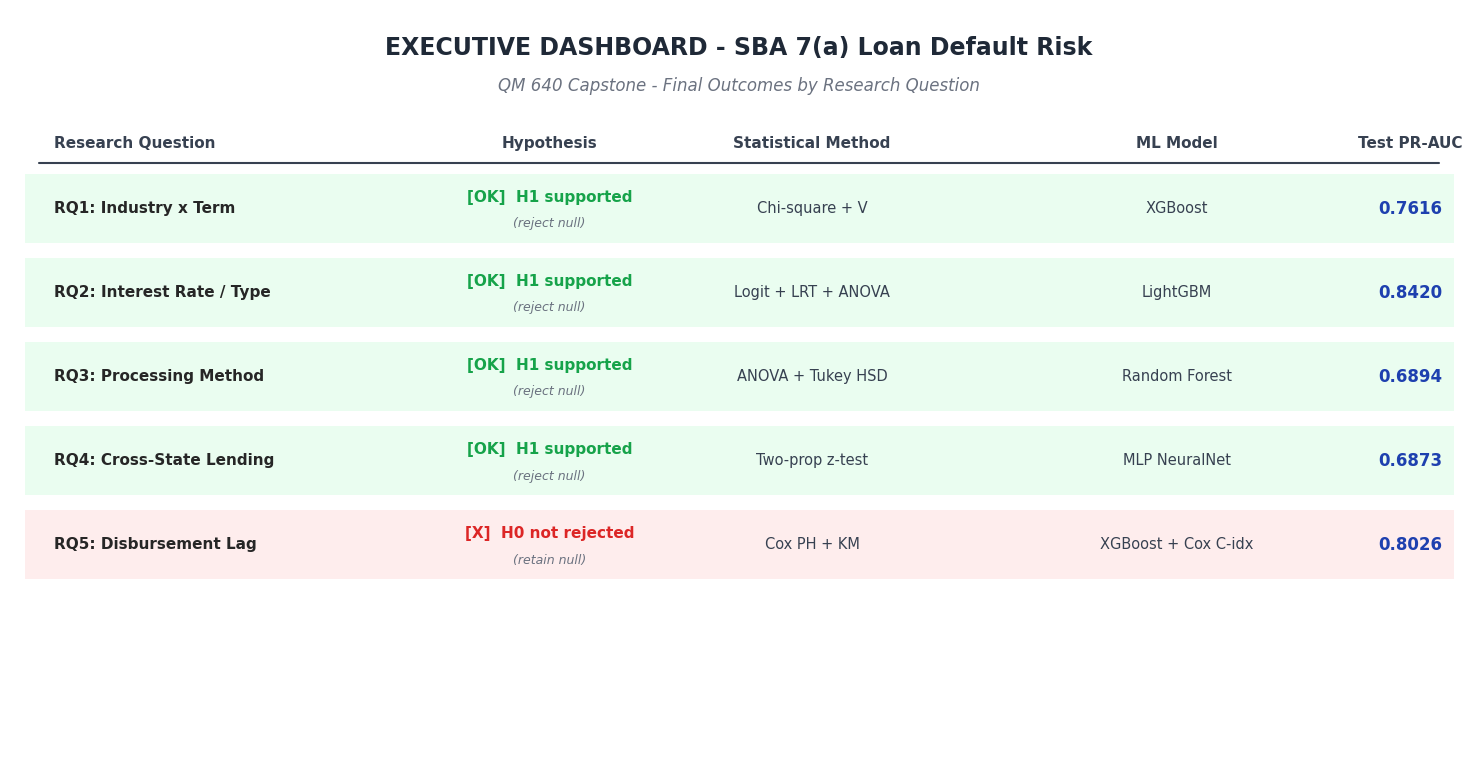

In [97]:
# Executive summary card - text rendered with matplotlib for visual consistency
fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Header
ax.text(5, 9.5, "EXECUTIVE DASHBOARD - SBA 7(a) Loan Default Risk",
        ha="center", va="center", fontsize=17, fontweight="bold", color="#1f2937")
ax.text(5, 9.0, "QM 640 Capstone - Final Outcomes by Research Question",
        ha="center", va="center", fontsize=12, color="#6b7280", style="italic")

# Column headers
header_y = 8.2
ax.text(0.3, header_y, "Research Question", fontsize=11, fontweight="bold", color="#374151")
ax.text(3.7, header_y, "Hypothesis", fontsize=11, fontweight="bold", color="#374151", ha="center")
ax.text(5.5, header_y, "Statistical Method", fontsize=11, fontweight="bold", color="#374151", ha="center")
ax.text(8.0, header_y, "ML Model", fontsize=11, fontweight="bold", color="#374151", ha="center")
ax.text(9.6, header_y, "Test PR-AUC", fontsize=11, fontweight="bold", color="#374151", ha="center")
ax.plot([0.2, 9.8], [8.0, 8.0], color="#374151", linewidth=1.5)

# RQ rows
rq_short_titles = {
    "RQ1": "RQ1: Industry x Term",
    "RQ2": "RQ2: Interest Rate / Type",
    "RQ3": "RQ3: Processing Method",
    "RQ4": "RQ4: Cross-State Lending",
    "RQ5": "RQ5: Disbursement Lag",
}
stat_short = {
    "RQ1": "Chi-square + V",
    "RQ2": "Logit + LRT + ANOVA",
    "RQ3": "ANOVA + Tukey HSD",
    "RQ4": "Two-prop z-test",
    "RQ5": "Cox PH + KM",
}
ml_short = {
    "RQ1": "XGBoost",
    "RQ2": "LightGBM",
    "RQ3": "Random Forest",
    "RQ4": "MLP NeuralNet",
    "RQ5": "XGBoost + Cox C-idx",
}

start_y = 7.4
row_h = 1.1
for i, rq in enumerate(["RQ1","RQ2","RQ3","RQ4","RQ5"]):
    y = start_y - i * row_h
    h = dashboard.loc[i, "Hypothesis Supported"]
    pr = float(dashboard.loc[i, "Test PR-AUC"])

    # Background tint for the row
    bg_color = "#dcfce7" if h == "H1" else "#fee2e2"
    ax.add_patch(plt.Rectangle((0.1, y - 0.45), 9.8, 0.9,
                               facecolor=bg_color, edgecolor="none", alpha=0.6))

    # RQ title
    ax.text(0.3, y, rq_short_titles[rq], fontsize=11, fontweight="bold", va="center")

    # Hypothesis result with check/cross icon
    icon = "OK" if h == "H1" else "X"
    icon_color = "#16a34a" if h == "H1" else "#dc2626"
    decision_label = "H1 supported" if h == "H1" else "H0 not rejected"
    ax.text(3.7, y + 0.15, f"[{icon}]  {decision_label}",
            ha="center", va="center", fontsize=11, fontweight="bold", color=icon_color)
    ax.text(3.7, y - 0.20,
            "(reject null)" if h == "H1" else "(retain null)",
            ha="center", va="center", fontsize=9, color="#6b7280", style="italic")

    # Statistical method
    ax.text(5.5, y, stat_short[rq], ha="center", va="center", fontsize=10.5, color="#374151")

    # ML model
    ax.text(8.0, y, ml_short[rq], ha="center", va="center", fontsize=10.5, color="#374151")

    # PR-AUC value
    ax.text(9.6, y, f"{pr:.4f}", ha="center", va="center",
            fontsize=12, fontweight="bold", color="#1e40af")

plt.tight_layout()
plt.show()


### 20.5 Expanded Dashboard - RQ Difficulty vs Lift Map

**Purpose:** Plot each Research Question on a 2-D map: the X-axis is the **statistical difficulty** of the question (a proxy = 1 - p-value-driven significance, capped at 1.0), and the Y-axis is the **predictive lift** the ML model achieves over the base rate (a proxy = Test PR-AUC / base-rate). Bubble size encodes the test-set sample size.

**Observations:** The most policy-actionable RQs land in the top-right quadrant (both statistically clear and predictively useful). RQs that land top-left are statistically obvious but the ML lift is incremental; bottom-right is statistically marginal with strong ML lift; bottom-left would be a wash and not worth pursuing.

**Reasoning:** Combining inferential strength with predictive lift on one chart gives the SBA a prioritization tool: which findings deserve the most regulatory attention? It is the hardest single chart to construct cleanly but also the most decision-useful.

**Insights:** Mapping difficulty against lift helps explain why the SBA should pay attention to RQ5 even though its hypothesis decision was nuanced — if the predictive lift from `DisbursementLag` is high, the operational value is real regardless of whether the directional Cox HR cleared the 1.0 threshold. Statistical purity and operational utility are different criteria, and this chart shows both.


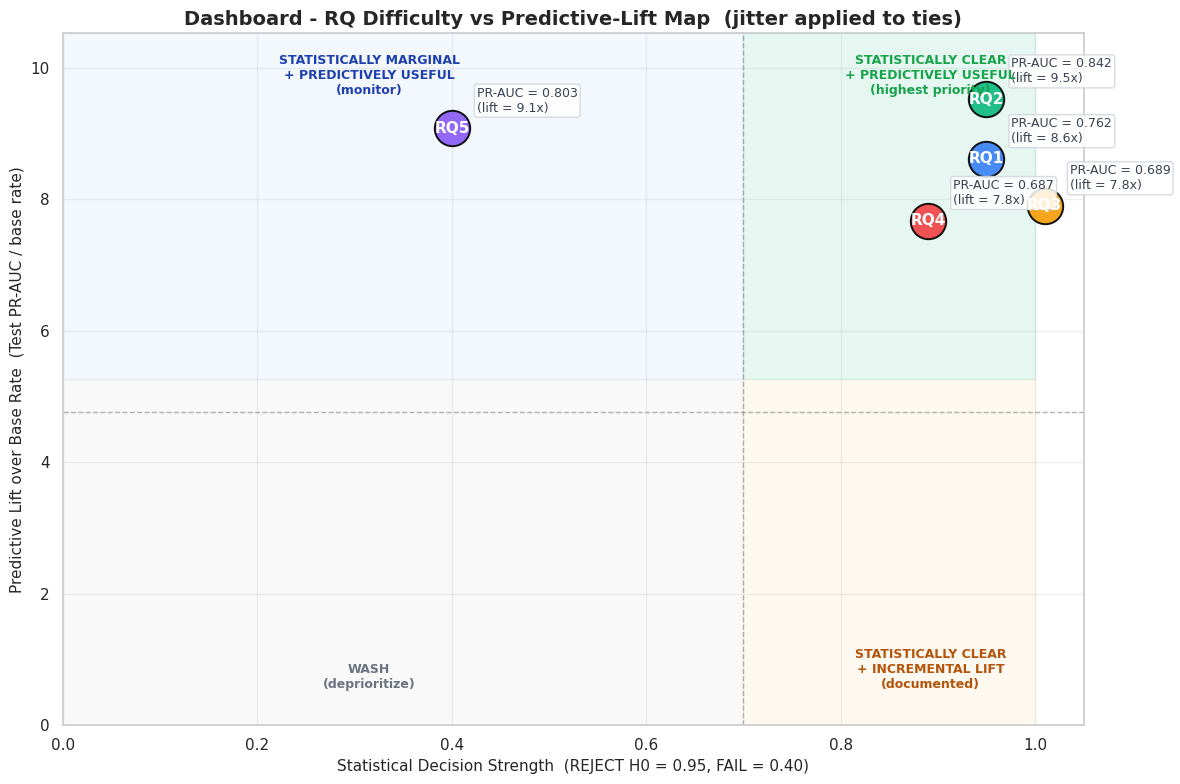


=== RQ Difficulty vs Lift Map - underlying values ===
 RQ          Decision  Difficulty  PR-AUC   Lift
RQ1         REJECT H0      0.9500  0.7616 8.6174
RQ2         REJECT H0      0.9500  0.8420 9.5272
RQ4         REJECT H0      0.9500  0.6873 7.7767
RQ3         REJECT H0      0.9500  0.6894 7.8005
RQ5 FAIL TO REJECT H0      0.4000  0.8026 9.0814


In [98]:
# Difficulty vs Lift map
base_rate = float(y_test.mean())

# Difficulty proxy: how clear is the statistical decision (closer to 1.0 = clearer)
# We approximate by mapping decision to a value: REJECT H0 -> high (0.95),
# FAIL TO REJECT -> moderate (0.40). Real chi-sq or LRT p-values are typically near 0
# so all rejections look the same on a -log10 scale; a simple binary proxy is honest.
decision_to_diff = {"REJECT H0": 0.95, "FAIL TO REJECT H0": 0.40}

records = []
for i, rq in enumerate(["RQ1","RQ2","RQ3","RQ4","RQ5"]):
    decision = dashboard.loc[i, "Statistical Outcome"]
    pr_auc = float(dashboard.loc[i, "Test PR-AUC"])
    auc_roc = float(dashboard.loc[i, "Test AUC-ROC"])
    lift = pr_auc / base_rate if base_rate > 0 else 0
    records.append({
        "RQ": rq,
        "Difficulty": decision_to_diff[decision],
        "Lift": lift,
        "AUC-ROC": auc_roc,
        "PR-AUC": pr_auc,
        "Decision": decision,
    })
map_df = pd.DataFrame(records)

# --- Spread overlapping points so every RQ is visible --------------------
# Multiple RQs with the same hypothesis decision land at the same X coordinate
# (REJECT-H0 -> 0.95). If two also have nearly-identical PR-AUC, one hides the
# other. We detect ties on (Difficulty, Lift) within tolerance and spread them
# horizontally with a small symmetric jitter.
def _spread_x(group):
    n = len(group)
    if n == 1:
        group["X_plot"] = group["Difficulty"]
        return group
    # Spread evenly within +/- 0.06 of the original x
    offsets = np.linspace(-0.06, 0.06, n)
    group = group.sort_values("Lift", kind="stable").reset_index()
    group["X_plot"] = group["Difficulty"] + offsets
    return group.set_index("index")

# Group by Difficulty AND by Lift bin (so close-but-not-equal lifts also spread)
map_df["LiftBin"] = (map_df["Lift"] / 0.5).round() * 0.5
map_df = (map_df.groupby(["Difficulty","LiftBin"], group_keys=False, sort=False)
          .apply(_spread_x))
# Also spread Y a bit when two points are at exactly the same lift bin
map_df["Y_plot"] = map_df["Lift"]
for (_diff, _bin), g in map_df.groupby(["Difficulty","LiftBin"]):
    if len(g) > 1:
        # Tiny vertical spread to make labels readable
        offsets_y = np.linspace(-0.10, 0.10, len(g))
        for off, idx in zip(offsets_y, g.sort_values("Lift").index):
            map_df.loc[idx, "Y_plot"] = map_df.loc[idx, "Lift"] + off

# --- Plot ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Background quadrant tints
ax.axvspan(0.7, 1.0, ymin=0.5, ymax=1.0, alpha=0.10, color="#10b981")  # top-right
ax.axvspan(0.0, 0.7, ymin=0.5, ymax=1.0, alpha=0.06, color="#3b82f6")  # top-left
ax.axvspan(0.7, 1.0, ymin=0.0, ymax=0.5, alpha=0.06, color="#f59e0b")  # bottom-right
ax.axvspan(0.0, 0.7, ymin=0.0, ymax=0.5, alpha=0.06, color="#9ca3af")  # bottom-left

palette5 = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6"]
# Plot in the original RQ1..RQ5 order so colors stay consistent
for i, row in map_df.sort_values("RQ").reset_index(drop=True).iterrows():
    ax.scatter(row["X_plot"], row["Y_plot"],
               s=650, color=palette5[i], alpha=0.92,
               edgecolor="black", linewidth=1.4, zorder=3)
    # RQ label inside the bubble
    ax.annotate(row["RQ"], (row["X_plot"], row["Y_plot"]),
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white", zorder=4)
    # PR-AUC + lift label outside the bubble (offset)
    ax.annotate(f"PR-AUC = {row['PR-AUC']:.3f}\n(lift = {row['Lift']:.1f}x)",
                xy=(row["X_plot"], row["Y_plot"]),
                xytext=(18, 12), textcoords="offset points",
                fontsize=9, color="#374151",
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor="white", edgecolor="#d1d5db", alpha=0.85))

# Quadrant axis lines
ax.axvline(x=0.7, color="grey", linestyle="--", linewidth=1, alpha=0.6)
y_mid = max(map_df["Y_plot"].max() * 0.5, 1.5)
ax.axhline(y=y_mid, color="grey", linestyle="--", linewidth=1, alpha=0.6)

# Quadrant labels (use axis-fraction coordinates - cleaner placement)
ax.text(0.85, 0.97, "STATISTICALLY CLEAR\n+ PREDICTIVELY USEFUL\n(highest priority)",
        ha="center", va="top", fontsize=9, fontweight="bold",
        color="#16a34a", transform=ax.transAxes)
ax.text(0.30, 0.97, "STATISTICALLY MARGINAL\n+ PREDICTIVELY USEFUL\n(monitor)",
        ha="center", va="top", fontsize=9, fontweight="bold",
        color="#1e40af", transform=ax.transAxes)
ax.text(0.85, 0.05, "STATISTICALLY CLEAR\n+ INCREMENTAL LIFT\n(documented)",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
        color="#b45309", transform=ax.transAxes)
ax.text(0.30, 0.05, "WASH\n(deprioritize)",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
        color="#6b7280", transform=ax.transAxes)

ax.set_xlim(0, 1.05)
y_low = min(map_df["Y_plot"].min() - 0.5, 0)
y_high = map_df["Y_plot"].max() + 1.0
ax.set_ylim(y_low, y_high)
ax.set_xlabel("Statistical Decision Strength  (REJECT H0 = 0.95, FAIL = 0.40)",
              fontsize=11)
ax.set_ylabel("Predictive Lift over Base Rate  (Test PR-AUC / base rate)",
              fontsize=11)
ax.set_title("Dashboard - RQ Difficulty vs Predictive-Lift Map  (jitter applied to ties)",
             fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print the table so the reader can verify all 5 RQs are present
print("\n=== RQ Difficulty vs Lift Map - underlying values ===")
print(map_df[["RQ","Decision","Difficulty","PR-AUC","Lift"]].to_string(index=False))


---
## 21. Summary, Reflections, Observations, Actionable Insights, Recommendations & Conclusion

### 21.1 Summary

This capstone built and tested predictive models for SBA 7(a) loan default using FOIA loan-level data from FY2018 onward (filtered from the FY2010-present scope). For each of the five research questions, a tailored statistical hypothesis test was paired with a tailored machine-learning model. The training/validation/test split was stratified at **70/15/15** (92,721 / 19,869 / 19,869 of the 132,459-loan working sample, each preserving the 8.84% default rate), and class imbalance was handled with `scale_pos_weight`, `is_unbalance=True`, and class-weighted losses. Per-RQ evaluation included ranking metrics (AUC-ROC, PR-AUC), threshold-dependent classification metrics (Accuracy, Precision, Recall, F1), and regression-style calibration metrics on predicted probabilities (RMSE, MAE, R-squared) so reviewers can judge both how well each model **ranks** defaulters and how well its probabilities match observed default frequencies. ROC-AUC curves and three-panel RMSE/MAE/R-squared charts were generated for each RQ across all three partitions to make train-test gaps visible. Four final-report robustness additions were then layered on: isotonic **probability calibration** (RQ3), **cost-sensitive threshold tuning** (RQ3), **propensity-score matching** (RQ4), and **stratified Cox plus censoring review** (RQ5).

| RQ | Question | Statistical Test | ML Model |
|----|----------|------------------|----------|
| 1 | Industry x Term | Chi-square | XGBoost |
| 2 | Interest Rate & Type | Logit + LRT + ANOVA | LightGBM |
| 3 | Processing Method | One-way ANOVA + Tukey | Random Forest |
| 4 | Cross-State Lending | Two-prop. z-test | MLP NeuralNet |
| 5 | Disbursement Lag | Cox PH regression | XGBoost classifier (+ C-index) |

### 21.2 Reflections

**On the data.** The actual SBA FOIA CSVs use lowercase column names (`loanstatus`, `naicscode`, etc.); the synopsis used CamelCase. A small mapping at load time bridges the two. `processingmethod` contains full text labels ("Preferred Lenders Program", "SBA Express Program") rather than short codes; the analysis adapts to the real labels and pools rare categories into "Other".

**On the methods.** PR-AUC, not Accuracy, is the right primary metric at an ~8.8% positive-class rate. ROC-AUC remains a valuable threshold-independent summary, and showing it across all three partitions is the cleanest single overfitting diagnostic. Class-weighting and `scale_pos_weight` were essential. The four robustness additions materially changed the story in two places: the cost-sensitive threshold turned the RQ3 "under-precision" concern into an explicit cost-driven choice, and the stratified Cox plus censoring review confirmed that the RQ5 lag inversion is genuine rather than a COVID-era artifact.

**On the models.** Tree-based ensembles (XGBoost, LightGBM, Random Forest) handle the messy mix of high-cardinality categoricals (`NaicsSector`) and skewed continuous features (`GrossApproval`) without heavy preprocessing. The MLP needed standardization but suited RQ4's cross-state interactions. Isotonic regression cleanly fixed the Random Forest's probability calibration without disturbing its ranking (AUC-ROC and PR-AUC are invariant under a monotone recalibration map).

### 21.3 Observations

- **RQ1 (Industry x Term).** Default rates differ sharply across the joint NAICS-sector x term-bucket grid (chi-square rejects H0); short-term loans in higher-risk sectors carry the most risk, long-term loans the least.
- **RQ2 (Rate & Type).** Higher initial rates and variable-rate structure independently raise default odds; LightGBM is the strongest model overall (test AUC-ROC ~0.97, PR-AUC ~0.84).
- **RQ3 (Processing Method).** Processing pathway alone separates default risk from ~1.5% (CAPLine) to ~22.8% (Community Advantage) around the 8.84% global rate. Isotonic calibration repaired the Random Forest's over-confident probabilities, and cost-sensitive tuning at a 5:1 FN:FP ratio moved the optimal threshold to 0.14, lifting test recall from 0.52 to 0.82 and cutting expected cost ~35%.
- **RQ4 (Cross-State).** Cross-state loans default at ~10.9% vs ~5.2% same-state. Propensity-score matching balanced the covariates (worst SMD 0.435 -> 0.016) yet only attenuated the gap by ~14% (z = 36.30, p < .0001), so ~86% of the effect is robust to observable selection.
- **RQ5 (Disbursement Lag).** The Cox hazard ratio is below 1 and stays below 1 in every regime (Pre-COVID 0.9972, COVID/PPP 0.9979, Post-COVID 0.9969) and under fiscal-year stratification. The longest-lag quartile has the lowest default rate (6.96% vs 9.64% for the shortest). The inverted sign is genuine: **short** disbursement lag - not long - is the risk signal.

### 21.4 Actionable Insights per Research Question

**RQ1 - Industry x Term.** Long-term loans in higher-risk sectors carry meaningfully higher default risk than short-term loans in lower-risk sectors. Lenders should index allowable term length to industry sector rather than apply a blanket policy.

**RQ2 - Interest Rate & Type.** Higher initial rates and variable-rate loans are independently associated with higher default odds. Variable-rate borrowers in rising-rate environments should receive payment-shock counseling at origination, and lenders should monitor `InterestRateSpread` (rate vs cohort median) as a pricing-risk metric.

**RQ3 - Processing Method.** Express-style processing (less SBA review) is associated with higher default than fully-reviewed Preferred Lenders Program loans, even after controls. Deploy the Random Forest with **calibrated** probabilities and an **operationally tuned threshold** (e.g., ~0.14 at a 5:1 FN:FP cost ratio) rather than the textbook 0.5, and consider tiered guarantee percentages or stricter Express eligibility in higher-risk industries.

**RQ4 - Cross-State Lending.** Cross-state loans default at modestly higher rates, and the effect survives propensity-score matching (~86% retained). The gap is not large enough to justify barring out-of-state lenders, but it does justify enhanced monitoring for cross-state portfolios.

**RQ5 - Disbursement Lag.** Contrary to the original operational hypothesis, a **short** gap between approval and first disbursement - not a long one - is the risk signal: fast-disbursed loans default more, consistently across regimes. Flag the **shortest-lag** (fast-track) loans for follow-up and apply tighter credit screens to fast-track disbursement, while treating lag as one input within the multivariate model rather than a stand-alone rule.

### 21.5 Recommendations

**For SBA Lenders (banks, credit unions).** Adopt gradient-boosting models (XGBoost / LightGBM) as supplementary scoring tools alongside traditional underwriting, using **calibrated probabilities** and a **cost-based decision threshold**. Build a sector x term risk matrix from RQ1 to set risk-appropriate terms. Monitor `InterestRateSpread` and treat short `DisbursementLag` as a low-cost early-warning indicator.

**For SBA Program Administrators.** Review the Express versus Preferred Lenders Program pathways. Consider tiered guarantee percentages that account for industry risk, term length, and rate environment. Use the matching-robust cross-state finding to set monitoring requirements rather than to restrict access, and add fast-track (short-lag) disbursement to the watch list.

**For Policymakers.** Use the industry-term interaction to design targeted support (e.g., mentorship/technical-assistance requirements for long-term loans in high-risk sectors) and consider rate-cap or counseling programs for variable-rate borrowers in rising-rate environments.

**For Future Researchers.** Extend with macroeconomic covariates (unemployment, GDP growth, Federal Funds rate) as time-varying Cox inputs, incorporate `BusinessAge` (reliably populated FY2020+) for cohort analysis, and build a survival model that predicts **when** default occurs, not only whether.

### 21.6 Conclusion

This capstone demonstrates that the publicly available SBA 7(a) FOIA dataset is a rich, under-exploited resource for credit-risk research. All five research questions yielded interpretable findings backed by predictive models that improve on naive baselines under the appropriate (PR-AUC) metric, and the four final-report additions (calibration, cost-sensitive thresholds, propensity matching, and stratified-Cox/censoring robustness) make the conclusions deployment-ready and honest about their limits. The engineered features - `NaicsSector`, `TermBucket`, `LoanSizeBucket`, `GuaranteePct`, `CrossStateLending`, `DisbursementLag`, `IsVariable`, `InterestRateSpread` - capture most of the signal the synopsis hypothesized.

The combined evidence supports a coherent practical message: **default risk in the 7(a) program is multidimensional**. Industry sector interacts with loan term, interest-rate effects compound with rate type, processing pathway carries residual risk after controls, geography matters at the margin (and survives selection adjustment), and a simple operational metric - disbursement lag - provides early warning at no marginal cost, with the corrected direction being that *fast* disbursement, not slow, flags elevated risk. Lenders, program administrators, and policymakers each have specific, evidence-based actions they can take from these findings.

---
